In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

In [2]:
match_3_databases_res_count = pd.read_csv("Apexigen_exact_match_with_Epitope_type_counts_081_acc_042226.csv")
match_3_databases_res_count

,peptide_cat,count
0,KLGGALQAK_Viral,761
1,YVLDHLIVV_Viral,601
2,KTAYSHLSTSK_Viral,561
3,RLRAEAQVK_Viral,73
4,TPRVTGGGAM_Viral,68
...,...,...
72,LMFWASSSI_Tumor,1
73,YAKWKLCSA_Unknown,1
74,TPSVSSSISSL_Viral,1
75,SFHSLHLLF_Viral,1


In [3]:
match_3_databases_res_count['count'].sum()

2498

In [4]:
apexigen_pred  =  pd.read_csv("./Apexigen_tumor_paired_train_all_pred_res_IEDB_McPAS_VDJdb_081_acc_042226.csv")
apexigen_pred

,Unnamed: 0,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,...,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair
0,0,4,1756.0,627,PD,05,pathCR,05_post,post_CD40,7.470794,...,3,CD4T_naive,CD4T_naive3,CD4T_naive2,CD4T_naive,CASSVATAGGIGYTF,CAMREGWNTGTASKLTF,VMAPRTLIL,0.011278,CASSVATAGGIGYTF_VMAPRTLIL
1,1,4,1787.0,707,PD,05,pathCR,05_post,post_CD40,7.488294,...,2,CD4T_naive,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSLGGVNTGELFF,CAASTGNDMRF,LLFGYPVYV,0.009690,CASSLGGVNTGELFF_LLFGYPVYV
2,2,6,1825.0,864,HD,HD_01,HD,HD_03,NaN,7.509335,...,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CASSQGGLGLGGAVQPQHF,CAAGSGATNKLIF,SLLMWITQC,0.351640,CASSQGGLGLGGAVQPQHF_SLLMWITQC
3,3,8,974.0,470,PD,01,nopathCR,01_LTF2,follow_up,6.881412,...,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CASSRLAEVNEQFF,CAESRSGGSYIPTF,GLCTLVAML,0.006627,CASSRLAEVNEQFF_GLCTLVAML
4,4,3,2800.0,865,PD,04,pathCR,04_surgery,surgery,7.937375,...,7,CD4T_naive,CD4T_naive3,CD4T_naive3,CD4T_naive,CASSAGGARVSYEQYF,CAVFSGSRLTF,LSRFSWGAEGQRPGFGYGG,0.012351,CASSAGGARVSYEQYF_LSRFSWGAEGQRPGFGYGG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21774377,21774377,0,4706.0,1357,PD,05,pathCR,05_post,post_CD40,8.456594,...,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSLDSYGYTF,CAVNMDRGSTLGRLYF,YLYDRLLRV,0.049340,CASSLDSYGYTF_YLYDRLLRV
21774378,21774378,0,2891.0,1380,PD,05,pathCR,05_post,post_CD40,7.969358,...,3,CD8_Tcell,CD8T_GrK,CD8T_GrH,CD8_T,CASSLSYSEETQYF,CLVGERGSTLGRLYF,LYPEFIASI,0.023992,CASSLSYSEETQYF_LYPEFIASI
21774379,21774379,0,3474.0,1338,PD,05,pathCR,05_post,post_CD40,8.153062,...,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASTQNGGDTQYF,CAVTLGGSYIPTF,MLIGIPVYV,0.021651,CASTQNGGDTQYF_MLIGIPVYV
21774380,21774380,0,4632.0,1231,PD,05,pathCR,05_post,post_CD40,8.440744,...,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSNVRRSRDSPLHF,CAIRDGGAQKLVF,KLYGLDWAEL,0.107440,CASSNVRRSRDSPLHF_KLYGLDWAEL


In [5]:
Apexigen_emb =  sc.read_h5ad("Apexigen_emb_with_leiden.h5ad")
Apexigen_emb

AnnData object with n_obs × n_vars = 16286 × 64
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'tissue', 'final_cell_type', 'leiden'
    uns: 'final_cell_type_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [6]:
adata = sc.read_h5ad('./Apexigen_data/Apexigen_gene_TCR_annotated_for_integration_real_case.h5ad')

In [7]:
apexigen_pred.shape[0]/adata.obs.shape[0]

1337.0

In [8]:
list(adata.obs.index.values)*1337

['AAACCTGAGGCGCTCT-1-4',
 'AAACCTGCATGCCACG-1-4',
 'AAACCTGTCTCCTATA-1-6',
 'AAACGGGAGGGATACC-1-8',
 'AAACGGGCATCGGAAG-1-3',
 'AAACGGGGTACCGAGA-1-2',
 'AAACGGGTCACTATTC-1-6',
 'AAAGCAAGTCTCGTTC-1-6',
 'AAAGTAGGTAACGCGA-1-2',
 'AAATGCCAGACAGAGA-1-6',
 'AAATGCCGTCAGATAA-1-7',
 'AAATGCCGTGTCAATC-1-3',
 'AACCATGGTACCATCA-1-6',
 'AACCGCGCATCCCACT-1-1',
 'AACCGCGGTCTAGAGG-1-2',
 'AACCGCGGTCTTGTCC-1-6',
 'AACCGCGGTTCTGAAC-1-3',
 'AACGTTGAGACATAAC-1-2',
 'AACGTTGAGCGCTTAT-1-1',
 'AACGTTGCACACCGAC-1-1',
 'AACGTTGCATATACCG-1-7',
 'AACTCAGCAAGTCTAC-1-3',
 'AACTCAGCAGAGTGTG-1-8',
 'AACTCAGGTTGTCGCG-1-5',
 'AACTCTTAGACACTAA-1-8',
 'AACTCTTAGCGTTCCG-1-6',
 'AACTCTTCAATAGAGT-1-6',
 'AACTCTTCATGCTAGT-1-3',
 'AACTCTTTCGCCAGCA-1-4',
 'AACTGGTCATCGACGC-1-1',
 'AACTTTCAGTGACATA-1-8',
 'AACTTTCGTAAATGAC-1-2',
 'AAGACCTAGAGTGACC-1-2',
 'AAGACCTGTCAGAGGT-1-6',
 'AAGCCGCGTGAGGGTT-1-1',
 'AAGGAGCGTGCTCTTC-1-2',
 'AAGGCAGGTAACGCGA-1-2',
 'AAGGCAGGTCACCCAG-1-1',
 'AAGGCAGTCGCCCTTA-1-4',
 'AAGGTTCAGCGATGAC-1-3',


In [9]:
apexigen_pred['barcode'] = list(adata.obs.index.values)*1337

In [10]:
apexigen_pred.head(10)

,Unnamed: 0,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,...,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair,barcode
0,0,4,1756.0,627,PD,05,pathCR,05_post,post_CD40,7.470794,...,CD4T_naive,CD4T_naive3,CD4T_naive2,CD4T_naive,CASSVATAGGIGYTF,CAMREGWNTGTASKLTF,VMAPRTLIL,0.011278,CASSVATAGGIGYTF_VMAPRTLIL,AAACCTGAGGCGCTCT-1-4
1,1,4,1787.0,707,PD,05,pathCR,05_post,post_CD40,7.488294,...,CD4T_naive,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSLGGVNTGELFF,CAASTGNDMRF,LLFGYPVYV,0.009690,CASSLGGVNTGELFF_LLFGYPVYV,AAACCTGCATGCCACG-1-4
2,2,6,1825.0,864,HD,HD_01,HD,HD_03,NaN,7.509335,...,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CASSQGGLGLGGAVQPQHF,CAAGSGATNKLIF,SLLMWITQC,0.351640,CASSQGGLGLGGAVQPQHF_SLLMWITQC,AAACCTGTCTCCTATA-1-6
3,3,8,974.0,470,PD,01,nopathCR,01_LTF2,follow_up,6.881412,...,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CASSRLAEVNEQFF,CAESRSGGSYIPTF,GLCTLVAML,0.006627,CASSRLAEVNEQFF_GLCTLVAML,AAACGGGAGGGATACC-1-8
4,4,3,2800.0,865,PD,04,pathCR,04_surgery,surgery,7.937375,...,CD4T_naive,CD4T_naive3,CD4T_naive3,CD4T_naive,CASSAGGARVSYEQYF,CAVFSGSRLTF,LSRFSWGAEGQRPGFGYGG,0.012351,CASSAGGARVSYEQYF_LSRFSWGAEGQRPGFGYGG,AAACGGGCATCGGAAG-1-3
5,5,2,2106.0,905,CR,03,pathCR,03_pre,pre_CD40,7.652546,...,CD4T_naive,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSPPGSFGYGYTF,CAVTWGSSNTGKLIF,squalene,0.069537,CASSPPGSFGYGYTF_squalene,AAACGGGGTACCGAGA-1-2
6,6,6,1417.0,655,HD,HD_01,HD,HD_03,NaN,7.256297,...,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CSQRGDGYTF,CVVSSGYALNF,"1,2-dioleoyl-3-palmitoylglycerol",0.000274,"CSQRGDGYTF_1,2-dioleoyl-3-palmitoylglycerol",AAACGGGTCACTATTC-1-6
7,7,6,1700.0,624,HD,HD_01,HD,HD_03,NaN,7.438384,...,CD4T_naive,CD4T_naive3,CD4T_naive1,CD4T_naive,CATSRVAGAGEQFF,CAVSEYTGTASKLTF,lauryl palmitoleate,0.001373,CATSRVAGAGEQFF_lauryl palmitoleate,AAAGCAAGTCTCGTTC-1-6
8,8,2,1342.0,663,CR,03,pathCR,03_pre,pre_CD40,7.201916,...,Treg,Treg,Treg,Treg,CASQIDRSGANVLTF,CLVGGSARQLTF,palmitoleyl alcohol,0.000181,CASQIDRSGANVLTF_palmitoleyl alcohol,AAAGTAGGTAACGCGA-1-2
9,9,6,1775.0,693,HD,HD_01,HD,HD_03,NaN,7.481556,...,CD4T_naive,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSPGDRPNQPQHF,CAARTSGSARQLTF,AAGIGILTV,0.008341,CASSPGDRPNQPQHF_AAGIGILTV,AAATGCCAGACAGAGA-1-6


In [11]:
apexigen_pred['leiden'] = list(Apexigen_emb.obs['leiden'].values)*1337

In [12]:
result = apexigen_pred.loc[apexigen_pred.groupby('barcode')['predicted_binding_probability'].idxmax()]
result

,Unnamed: 0,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,...,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair,barcode,leiden
11056015,11056015,0,5455.0,1945,PD,05,pathCR,05_pre,pre_CD40,8.604288,...,CD8T_prolif,CD8T_prolif,CD8_T,CSASGITASVNEKLFF,CATGRFTGGGNKLTF,KLGGALQAK,0.988152,CSASGITASVNEKLFF_KLGGALQAK,AAACCTGAGAGGTTAT-1_05_pre,5
19080,19080,35,1737.0,685,HD,HD_02,HD,HD_02,NaN,7.459915,...,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSPRISGFPEAFF,CAYRGKNFGNEKLTF,KLGGALQAK,0.837059,CASSPRISGFPEAFF_KLGGALQAK,AAACCTGAGATAGGAG-1-35,0
16791792,16791792,11,9108.0,2610,CR,03,pathCR,03_pre,pre_CD40,9.116908,...,CD8T_prolif,CD8T_prolif,CD8_T,CASSRQTGVLGNEQFF,CAVGMAGGGADGLTF,TSTLAEQVAW,0.870680,CASSRQTGVLGNEQFF_TSTLAEQVAW,AAACCTGAGCACACAG-1-11,2
16646012,16646012,22,2056.0,789,PD,05,pathCR,05_pre,pre_CD40,7.628518,...,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSPRGLGEEKLFF,CAVNPTGFQKLVF,KLGGALQAK,0.845159,CASSPRGLGEEKLFF_KLGGALQAK,AAACCTGAGCCAGTTT-1-22,0
4389733,4389733,0,5267.0,2038,CR,03,pathCR,03_pre,pre_CD40,8.569216,...,Treg,Treg1,Treg,CASSLAINQETQYF,CVVSEGYGNKLVF,KLGGALQAK,0.684036,CASSLAINQETQYF_KLGGALQAK,AAACCTGAGCCTATGT-1_03_pre,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7256068,7256068,0,12700.0,3547,PD,01,nopathCR,01_pre,pre_CD40,9.449357,...,CD8T_prolif,CD8T_GrK,CD8_T,CASSVDSREEDTQYF,CALSEFSHGGSQGNLIF,KLMNIQQQL,0.974962,CASSVDSREEDTQYF_KLMNIQQQL,TTTGTCATCGAGAGCA-1_01_pre,11
9747092,9747092,0,4114.0,1822,NaN,02,pathCR,02_post,post_CD40,8.322151,...,CD8T_GrH,CD8T_GrB,CD8_T,CASSRDRNYGYTF,CAVTGNQFYF,KLGGALQAK,0.913994,CASSRDRNYGYTF_KLGGALQAK,TTTGTCATCGCACTCT-1_02_post,10
1070247,1070247,0,2813.0,1228,CR,03,pathCR,03_pre,pre_CD40,7.942007,...,Treg,Treg1,Treg,CASSLLAGRLTDTQYF,CAMSETGANNLFF,RVLGLVLLRGENLVS,0.757363,CASSLLAGRLTDTQYF_RVLGLVLLRGENLVS,TTTGTCATCGCTTAGA-1_03_pre,1
2983131,2983131,24,2643.0,968,HD,HD_01,HD,HD_03,NaN,7.879670,...,CD4T_naive2,CD8T_GrK,CD8_T,CSVRTISYEQYF,CAVLNYGQNFVF,RRSGPPGLQGRLQRLLQASGNHA,0.952975,CSVRTISYEQYF_RRSGPPGLQGRLQRLLQASGNHA,TTTGTCATCGTCTGAA-1-24,7


In [13]:
all_3_datasets_peptide_type = pd.read_csv("all_3_datasets_peptide_type.csv")
all_3_datasets_peptide_type

,Unnamed: 0,Epitope,Epitope_type,peptide_cat
0,0,VMAPRTLIL,"HLA class I histocompatibility antigen, Cw-3 a...",NaN
1,1,LLFGYPVYV,transcriptional activator Tax_Human T-cell leu...,Viral
2,3,SLLMWITQC,Cancer/testis antigen 1_Homo sapiens (human),Tumor
3,4,GLCTLVAML,BMLF1 protein_Human herpesvirus 4 (Epstein Bar...,Viral
4,5,LSRFSWGAEGQRPGFGYGG,MBP protein_Homo sapiens (human),NaN
...,...,...,...,...
1332,102675,YLYDRLLRV,GINS1,NaN
1333,102676,LYPEFIASI,DPY19L4,NaN
1334,102677,MLIGIPVYV,RNF19B,NaN
1335,102678,KLYGLDWAEL,ASTN1,NaN


In [14]:
apexigen_pred_peptide_type = apexigen_pred.merge(all_3_datasets_peptide_type[['Epitope','Epitope_type','peptide_cat']], how='left', left_on = "Epitope", right_on = "Epitope")

In [15]:
apexigen_pred_peptide_type.head(10)

,Unnamed: 0,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,...,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair,barcode,leiden,Epitope_type,peptide_cat
0,0,4,1756.0,627,PD,05,pathCR,05_post,post_CD40,7.470794,...,CD4T_naive,CASSVATAGGIGYTF,CAMREGWNTGTASKLTF,VMAPRTLIL,0.011278,CASSVATAGGIGYTF_VMAPRTLIL,AAACCTGAGGCGCTCT-1-4,0,"HLA class I histocompatibility antigen, Cw-3 a...",NaN
1,1,4,1787.0,707,PD,05,pathCR,05_post,post_CD40,7.488294,...,CD4T_naive,CASSLGGVNTGELFF,CAASTGNDMRF,LLFGYPVYV,0.009690,CASSLGGVNTGELFF_LLFGYPVYV,AAACCTGCATGCCACG-1-4,4,transcriptional activator Tax_Human T-cell leu...,Viral
2,2,6,1825.0,864,HD,HD_01,HD,HD_03,NaN,7.509335,...,CD4T_naive,CASSQGGLGLGGAVQPQHF,CAAGSGATNKLIF,SLLMWITQC,0.351640,CASSQGGLGLGGAVQPQHF_SLLMWITQC,AAACCTGTCTCCTATA-1-6,0,Cancer/testis antigen 1_Homo sapiens (human),Tumor
3,3,8,974.0,470,PD,01,nopathCR,01_LTF2,follow_up,6.881412,...,CD8_T,CASSRLAEVNEQFF,CAESRSGGSYIPTF,GLCTLVAML,0.006627,CASSRLAEVNEQFF_GLCTLVAML,AAACGGGAGGGATACC-1-8,20,BMLF1 protein_Human herpesvirus 4 (Epstein Bar...,Viral
4,4,3,2800.0,865,PD,04,pathCR,04_surgery,surgery,7.937375,...,CD4T_naive,CASSAGGARVSYEQYF,CAVFSGSRLTF,LSRFSWGAEGQRPGFGYGG,0.012351,CASSAGGARVSYEQYF_LSRFSWGAEGQRPGFGYGG,AAACGGGCATCGGAAG-1-3,0,MBP protein_Homo sapiens (human),NaN
5,5,2,2106.0,905,CR,03,pathCR,03_pre,pre_CD40,7.652546,...,CD4T_naive,CASSPPGSFGYGYTF,CAVTWGSSNTGKLIF,squalene,0.069537,CASSPPGSFGYGYTF_squalene,AAACGGGGTACCGAGA-1-2,4,NaN,NaN
6,6,6,1417.0,655,HD,HD_01,HD,HD_03,NaN,7.256297,...,CD8_T,CSQRGDGYTF,CVVSSGYALNF,"1,2-dioleoyl-3-palmitoylglycerol",0.000274,"CSQRGDGYTF_1,2-dioleoyl-3-palmitoylglycerol",AAACGGGTCACTATTC-1-6,12,NaN,NaN
7,7,6,1700.0,624,HD,HD_01,HD,HD_03,NaN,7.438384,...,CD4T_naive,CATSRVAGAGEQFF,CAVSEYTGTASKLTF,lauryl palmitoleate,0.001373,CATSRVAGAGEQFF_lauryl palmitoleate,AAAGCAAGTCTCGTTC-1-6,13,NaN,NaN
8,8,2,1342.0,663,CR,03,pathCR,03_pre,pre_CD40,7.201916,...,Treg,CASQIDRSGANVLTF,CLVGGSARQLTF,palmitoleyl alcohol,0.000181,CASQIDRSGANVLTF_palmitoleyl alcohol,AAAGTAGGTAACGCGA-1-2,1,NaN,NaN
9,9,6,1775.0,693,HD,HD_01,HD,HD_03,NaN,7.481556,...,CD4T_naive,CASSPGDRPNQPQHF,CAARTSGSARQLTF,AAGIGILTV,0.008341,CASSPGDRPNQPQHF_AAGIGILTV,AAATGCCAGACAGAGA-1-6,0,Melanoma antigen recognized by T-cells 1_Homo ...,Tumor


In [16]:
apexigen_pred_peptide_type['peptide_cat'].value_counts()

peptide_cat
Tumor    5748958
Viral    2654618
Name: count, dtype: int64

In [17]:
apexigen_pred_peptide_type_tumor_viral = apexigen_pred_peptide_type[apexigen_pred_peptide_type['peptide_cat'].str.contains("Tumor|Viral", na=False)]
apexigen_pred_peptide_type_tumor_viral

,Unnamed: 0,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,...,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair,barcode,leiden,Epitope_type,peptide_cat
1,1,4,1787.0,707,PD,05,pathCR,05_post,post_CD40,7.488294,...,CD4T_naive,CASSLGGVNTGELFF,CAASTGNDMRF,LLFGYPVYV,0.009690,CASSLGGVNTGELFF_LLFGYPVYV,AAACCTGCATGCCACG-1-4,4,transcriptional activator Tax_Human T-cell leu...,Viral
2,2,6,1825.0,864,HD,HD_01,HD,HD_03,NaN,7.509335,...,CD4T_naive,CASSQGGLGLGGAVQPQHF,CAAGSGATNKLIF,SLLMWITQC,0.351640,CASSQGGLGLGGAVQPQHF_SLLMWITQC,AAACCTGTCTCCTATA-1-6,0,Cancer/testis antigen 1_Homo sapiens (human),Tumor
3,3,8,974.0,470,PD,01,nopathCR,01_LTF2,follow_up,6.881412,...,CD8_T,CASSRLAEVNEQFF,CAESRSGGSYIPTF,GLCTLVAML,0.006627,CASSRLAEVNEQFF_GLCTLVAML,AAACGGGAGGGATACC-1-8,20,BMLF1 protein_Human herpesvirus 4 (Epstein Bar...,Viral
9,9,6,1775.0,693,HD,HD_01,HD,HD_03,NaN,7.481556,...,CD4T_naive,CASSPGDRPNQPQHF,CAARTSGSARQLTF,AAGIGILTV,0.008341,CASSPGDRPNQPQHF_AAGIGILTV,AAATGCCAGACAGAGA-1-6,0,Melanoma antigen recognized by T-cells 1_Homo ...,Tumor
10,10,7,1361.0,628,CR,03,pathCR,03_LTF2,follow_up,7.215975,...,CD4T_naive,CASIISGVGTDTQYF,CAVSATNKLIF,NLVPMVATV,0.375103,CASIISGVGTDTQYF_NLVPMVATV,AAATGCCGTCAGATAA-1-7,0,pp65_Human herpesvirus 5 (Human cytomegalovirus),Viral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21774346,21774346,0,1722.0,831,PD,05,pathCR,05_post,post_CD40,7.451242,...,CD8_T,CISVPAA*AGLAASSSS,CALASI,MTEYKLVVVGAVGVGKSALTIQLI,0.000237,CISVPAA*AGLAASSSS_MTEYKLVVVGAVGVGKSALTIQLI,TCTTCGGAGTGTCCCG-1_05_post,3,KRAS,Tumor
21774347,21774347,0,4439.0,1634,PD,05,pathCR,05_post,post_CD40,8.398185,...,Treg,CASSSGSTLEQFF,CVVNRGSYIPTF,VVVGADGVGK,0.283105,CASSSGSTLEQFF_VVVGADGVGK,TCTTTCCAGTACATGA-1_05_post,0,KRAS,Tumor
21774348,21774348,0,5712.0,1993,PD,05,pathCR,05_post,post_CD40,8.650325,...,Treg,CASSYSSGGNTDTQYF,CAVRPSGYSSASKIIF,AVGVGKSAL,0.220320,CASSYSSGGNTDTQYF_AVGVGKSAL,TGAAAGAAGCCAGTTT-1_05_post,0,KRAS,Tumor
21774349,21774349,0,3670.0,1152,PD,05,pathCR,05_post,post_CD40,8.207947,...,CD4_T,CASSEAGTDLYEQYF,CVGRPGNQFYF,MTEYKLVVVGAGDVGKSALTIQLI,0.008234,CASSEAGTDLYEQYF_MTEYKLVVVGAGDVGKSALTIQLI,TGAAAGATCTTACCTA-1_05_post,4,KRAS,Tumor


In [18]:
result = apexigen_pred_peptide_type_tumor_viral.loc[apexigen_pred_peptide_type_tumor_viral.groupby('barcode')['predicted_binding_probability'].idxmax()]
result

,Unnamed: 0,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,...,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair,barcode,leiden,Epitope_type,peptide_cat
11056015,11056015,0,5455.0,1945,PD,05,pathCR,05_pre,pre_CD40,8.604288,...,CD8_T,CSASGITASVNEKLFF,CATGRFTGGGNKLTF,KLGGALQAK,0.988152,CSASGITASVNEKLFF_KLGGALQAK,AAACCTGAGAGGTTAT-1_05_pre,5,regulatory protein IE1 [Human betaherpesvirus ...,Viral
19080,19080,35,1737.0,685,HD,HD_02,HD,HD_02,NaN,7.459915,...,CD4T_naive,CASSPRISGFPEAFF,CAYRGKNFGNEKLTF,KLGGALQAK,0.837059,CASSPRISGFPEAFF_KLGGALQAK,AAACCTGAGATAGGAG-1-35,0,regulatory protein IE1 [Human betaherpesvirus ...,Viral
16791792,16791792,11,9108.0,2610,CR,03,pathCR,03_pre,pre_CD40,9.116908,...,CD8_T,CASSRQTGVLGNEQFF,CAVGMAGGGADGLTF,TSTLAEQVAW,0.870680,CASSRQTGVLGNEQFF_TSTLAEQVAW,AAACCTGAGCACACAG-1-11,2,gag protein [Human immunodeficiency virus 1]_H...,Viral
16646012,16646012,22,2056.0,789,PD,05,pathCR,05_pre,pre_CD40,7.628518,...,CD4T_naive,CASSPRGLGEEKLFF,CAVNPTGFQKLVF,KLGGALQAK,0.845159,CASSPRGLGEEKLFF_KLGGALQAK,AAACCTGAGCCAGTTT-1-22,0,regulatory protein IE1 [Human betaherpesvirus ...,Viral
4389733,4389733,0,5267.0,2038,CR,03,pathCR,03_pre,pre_CD40,8.569216,...,Treg,CASSLAINQETQYF,CVVSEGYGNKLVF,KLGGALQAK,0.684036,CASSLAINQETQYF_KLGGALQAK,AAACCTGAGCCTATGT-1_03_pre,0,regulatory protein IE1 [Human betaherpesvirus ...,Viral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139086,139086,0,12700.0,3547,PD,01,nopathCR,01_pre,pre_CD40,9.449357,...,CD8_T,CASSVDSREEDTQYF,CALSEFSHGGSQGNLIF,TPRVTGGGAM,0.955753,CASSVDSREEDTQYF_TPRVTGGGAM,TTTGTCATCGAGAGCA-1_01_pre,11,pp65_Human herpesvirus 5 (Human cytomegalovirus),Viral
9747092,9747092,0,4114.0,1822,NaN,02,pathCR,02_post,post_CD40,8.322151,...,CD8_T,CASSRDRNYGYTF,CAVTGNQFYF,KLGGALQAK,0.913994,CASSRDRNYGYTF_KLGGALQAK,TTTGTCATCGCACTCT-1_02_post,10,regulatory protein IE1 [Human betaherpesvirus ...,Viral
21655751,21655751,0,2813.0,1228,CR,03,pathCR,03_pre,pre_CD40,7.942007,...,Treg,CASSLLAGRLTDTQYF,CAMSETGANNLFF,KLGGALQAK,0.718848,CASSLLAGRLTDTQYF_KLGGALQAK,TTTGTCATCGCTTAGA-1_03_pre,1,regulatory protein IE1 [Human betaherpesvirus ...,Viral
21076877,21076877,24,2643.0,968,HD,HD_01,HD,HD_03,NaN,7.879670,...,CD8_T,CSVRTISYEQYF,CAVLNYGQNFVF,TSTLAEQVAW,0.884801,CSVRTISYEQYF_TSTLAEQVAW,TTTGTCATCGTCTGAA-1-24,7,gag protein [Human immunodeficiency virus 1]_H...,Viral


In [19]:
result['peptide_cat'].value_counts()

peptide_cat
Viral    13158
Tumor     3128
Name: count, dtype: int64

In [20]:
result_no_HD = result[~result['patient'].str.contains("HD")]

In [21]:
result_no_HD[result_no_HD['predicted_binding_probability'] > 0.8]['peptide_cat'].value_counts()

peptide_cat
Viral    9885
Tumor    2205
Name: count, dtype: int64

In [22]:
result_no_HD_pred_res = result_no_HD[result_no_HD['predicted_binding_probability'] > 0.9]
result_no_HD_pred_res['peptide_cat'].value_counts()

peptide_cat
Viral    6690
Tumor    1133
Name: count, dtype: int64

In [23]:
np.sum(result_no_HD['predicted_binding_probability'] > 0.9)

7823

In [24]:
result_high_conf = result_no_HD[result_no_HD['predicted_binding_probability'] > 0.9]

In [25]:
result_high_conf['peptide_and_type'] = result_high_conf['Epitope'] + "_" + result_high_conf['peptide_cat']
result_high_conf

/var/folders/xy/jbfzznj17w73w_rdfj3xs11h0000gn/T/ipykernel_63521/3213629229.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_high_conf['peptide_and_type'] = result_high_conf['Epitope'] + "_" + result_high_conf['peptide_cat']


,Unnamed: 0,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,...,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair,barcode,leiden,Epitope_type,peptide_cat,peptide_and_type
11056015,11056015,0,5455.0,1945,PD,05,pathCR,05_pre,pre_CD40,8.604288,...,CSASGITASVNEKLFF,CATGRFTGGGNKLTF,KLGGALQAK,0.988152,CSASGITASVNEKLFF_KLGGALQAK,AAACCTGAGAGGTTAT-1_05_pre,5,regulatory protein IE1 [Human betaherpesvirus ...,Viral,KLGGALQAK_Viral
20255912,20255912,0,3233.0,1558,PD,04,pathCR,04_post,post_CD40,8.081165,...,CSAHPGQGPYYEQYF,CAVDIYTRLMF,KLGGALQAK,0.960459,CSAHPGQGPYYEQYF_KLGGALQAK,AAACCTGAGCTAGTGG-1_04_post,12,regulatory protein IE1 [Human betaherpesvirus ...,Viral,KLGGALQAK_Viral
4557902,4557902,0,3184.0,1264,PD,05,pathCR,05_pre,pre_CD40,8.065893,...,CASSFRGSYTYEQYF,CAFSYGGATNKLIF,SGPSNTPPEI,0.965970,CASSFRGSYTYEQYF_SGPSNTPPEI,AAACCTGAGGAATTAC-1_05_pre,4,Early E1A 32 kDa protein_Human adenovirus 5 (A...,Viral,SGPSNTPPEI_Viral
12165642,12165642,4,1756.0,627,PD,05,pathCR,05_post,post_CD40,7.470794,...,CASSVATAGGIGYTF,CAMREGWNTGTASKLTF,RTQSPRRR,0.983772,CASSVATAGGIGYTF_RTQSPRRR,AAACCTGAGGCGCTCT-1-4,0,"precore/core protein, partial [Hepatitis B vir...",Viral,RTQSPRRR_Viral
3790767,3790767,0,4173.0,1613,PD,04,pathCR,04_post,post_CD40,8.336391,...,CASSPSAEQYF,CVVNTGAGSYQLTF,YLLEMLWRL,0.971430,CASSPSAEQYF_YLLEMLWRL,AAACCTGCAAACCCAT-1_04_post,0,"LMP1 protein (Epstein-Barr virus, putative LYD...",Viral,YLLEMLWRL_Viral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7988937,7988937,0,7320.0,2396,PD,01,nopathCR,01_pre,pre_CD40,8.898366,...,CSARGPSQSNEQFF,CALSSINQAGTALIF,KLGGALQAK,0.981525,CSARGPSQSNEQFF_KLGGALQAK,TTTGTCATCAAGATCC-1_01_pre,12,regulatory protein IE1 [Human betaherpesvirus ...,Viral,KLGGALQAK_Viral
19534976,19534976,0,10939.0,3594,NaN,02,pathCR,02_post,post_CD40,9.300090,...,CASSAAFWYTGELFF,CAMSAMNRDDKIIF,SGPSNTPPEI,0.981450,CASSAAFWYTGELFF_SGPSNTPPEI,TTTGTCATCATGTCTT-1_02_post,1,Early E1A 32 kDa protein_Human adenovirus 5 (A...,Viral,SGPSNTPPEI_Viral
139086,139086,0,12700.0,3547,PD,01,nopathCR,01_pre,pre_CD40,9.449357,...,CASSVDSREEDTQYF,CALSEFSHGGSQGNLIF,TPRVTGGGAM,0.955753,CASSVDSREEDTQYF_TPRVTGGGAM,TTTGTCATCGAGAGCA-1_01_pre,11,pp65_Human herpesvirus 5 (Human cytomegalovirus),Viral,TPRVTGGGAM_Viral
9747092,9747092,0,4114.0,1822,NaN,02,pathCR,02_post,post_CD40,8.322151,...,CASSRDRNYGYTF,CAVTGNQFYF,KLGGALQAK,0.913994,CASSRDRNYGYTF_KLGGALQAK,TTTGTCATCGCACTCT-1_02_post,10,regulatory protein IE1 [Human betaherpesvirus ...,Viral,KLGGALQAK_Viral


In [26]:
result_high_conf[result_high_conf['Epitope'] == "KLGGALQAK"]

,Unnamed: 0,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,...,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair,barcode,leiden,Epitope_type,peptide_cat,peptide_and_type
11056015,11056015,0,5455.0,1945,PD,05,pathCR,05_pre,pre_CD40,8.604288,...,CSASGITASVNEKLFF,CATGRFTGGGNKLTF,KLGGALQAK,0.988152,CSASGITASVNEKLFF_KLGGALQAK,AAACCTGAGAGGTTAT-1_05_pre,5,regulatory protein IE1 [Human betaherpesvirus ...,Viral,KLGGALQAK_Viral
20255912,20255912,0,3233.0,1558,PD,04,pathCR,04_post,post_CD40,8.081165,...,CSAHPGQGPYYEQYF,CAVDIYTRLMF,KLGGALQAK,0.960459,CSAHPGQGPYYEQYF_KLGGALQAK,AAACCTGAGCTAGTGG-1_04_post,12,regulatory protein IE1 [Human betaherpesvirus ...,Viral,KLGGALQAK_Viral
8146703,8146703,41,2417.0,874,PD,06,nopathCR,06_pre,pre_CD40,7.790282,...,CASSEMDLNTEAFF,CVVGAGANNLFF,KLGGALQAK,0.938759,CASSEMDLNTEAFF_KLGGALQAK,AAACCTGCAATTCCTT-1-41,0,regulatory protein IE1 [Human betaherpesvirus ...,Viral,KLGGALQAK_Viral
9106669,9106669,28,1121.0,538,NaN,02,pathCR,02_pre,pre_CD40,7.021977,...,CASSAGTGYQAGNQPQHF,CALLHASGGSYIPTF,KLGGALQAK,0.907440,CASSAGTGYQAGNQPQHF_KLGGALQAK,AAACCTGCAGATGGCA-1-28,4,regulatory protein IE1 [Human betaherpesvirus ...,Viral,KLGGALQAK_Viral
18194258,18194258,31,2319.0,744,PD,05,pathCR,05_pre,pre_CD40,7.748891,...,CASAQSNTGELFF,CAMMNSGGYQKVTF,KLGGALQAK,0.917798,CASAQSNTGELFF_KLGGALQAK,AAACCTGGTCGGATCC-1-31,0,regulatory protein IE1 [Human betaherpesvirus ...,Viral,KLGGALQAK_Viral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16167366,16167366,0,2952.0,1406,CR,03,pathCR,03_pre,pre_CD40,7.990238,...,CASSLGPSTDTQYF,CALSEGIGSGNTGKLIF,KLGGALQAK,0.924772,CASSLGPSTDTQYF_KLGGALQAK,TTTGTCACACTGTCGG-1_03_pre,16,regulatory protein IE1 [Human betaherpesvirus ...,Viral,KLGGALQAK_Viral
4258707,4258707,0,14355.0,3945,NaN,02,pathCR,02_post,post_CD40,9.571854,...,CASGEAGTYNEQFF,CAVNSGGYQKVTF,KLGGALQAK,0.907562,CASGEAGTYNEQFF_KLGGALQAK,TTTGTCACATGAACCT-1_02_post,6,regulatory protein IE1 [Human betaherpesvirus ...,Viral,KLGGALQAK_Viral
7988937,7988937,0,7320.0,2396,PD,01,nopathCR,01_pre,pre_CD40,8.898366,...,CSARGPSQSNEQFF,CALSSINQAGTALIF,KLGGALQAK,0.981525,CSARGPSQSNEQFF_KLGGALQAK,TTTGTCATCAAGATCC-1_01_pre,12,regulatory protein IE1 [Human betaherpesvirus ...,Viral,KLGGALQAK_Viral
9747092,9747092,0,4114.0,1822,NaN,02,pathCR,02_post,post_CD40,8.322151,...,CASSRDRNYGYTF,CAVTGNQFYF,KLGGALQAK,0.913994,CASSRDRNYGYTF_KLGGALQAK,TTTGTCATCGCACTCT-1_02_post,10,regulatory protein IE1 [Human betaherpesvirus ...,Viral,KLGGALQAK_Viral


In [27]:
result_high_conf.columns

Index(['Unnamed: 0', 'batch', 'n_counts', 'n_genes', 'outcome', 'patient',
       'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1',
       'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi',
       'TRB_cdr3', 'TRA_cdr3', 'Epitope', 'predicted_binding_probability',
       'TCR_Epitope_pair', 'barcode', 'leiden', 'Epitope_type', 'peptide_cat',
       'peptide_and_type'],
      dtype='object')

In [28]:
result_high_conf_unique_TCR_count = pd.DataFrame(result_high_conf.groupby('peptide_and_type')['TRB_cdr3'].nunique()).reset_index()
result_high_conf_unique_TCR_count

,peptide_and_type,TRB_cdr3
0,AGILARNLVPM_Viral,1
1,ALIHHNTHL_Tumor,1
2,APQPAPENAY_Viral,2
3,AVFDRKSDAK_Viral,150
4,AVGVGKSAL_Tumor,2
...,...,...
123,YTSEILSPI_Tumor,7
124,YVLDHLIVV_Viral,60
125,YVLTWIVGA_Tumor,4
126,YVTAMDLFV_Tumor,10


In [29]:
result_high_conf_unique_TCR_count[['Epitope','type']] = result_high_conf_unique_TCR_count['peptide_and_type'].str.split("_",expand=True)
result_high_conf_unique_TCR_count

,peptide_and_type,TRB_cdr3,Epitope,type
0,AGILARNLVPM_Viral,1,AGILARNLVPM,Viral
1,ALIHHNTHL_Tumor,1,ALIHHNTHL,Tumor
2,APQPAPENAY_Viral,2,APQPAPENAY,Viral
3,AVFDRKSDAK_Viral,150,AVFDRKSDAK,Viral
4,AVGVGKSAL_Tumor,2,AVGVGKSAL,Tumor
...,...,...,...,...
123,YTSEILSPI_Tumor,7,YTSEILSPI,Tumor
124,YVLDHLIVV_Viral,60,YVLDHLIVV,Viral
125,YVLTWIVGA_Tumor,4,YVLTWIVGA,Tumor
126,YVTAMDLFV_Tumor,10,YVTAMDLFV,Tumor


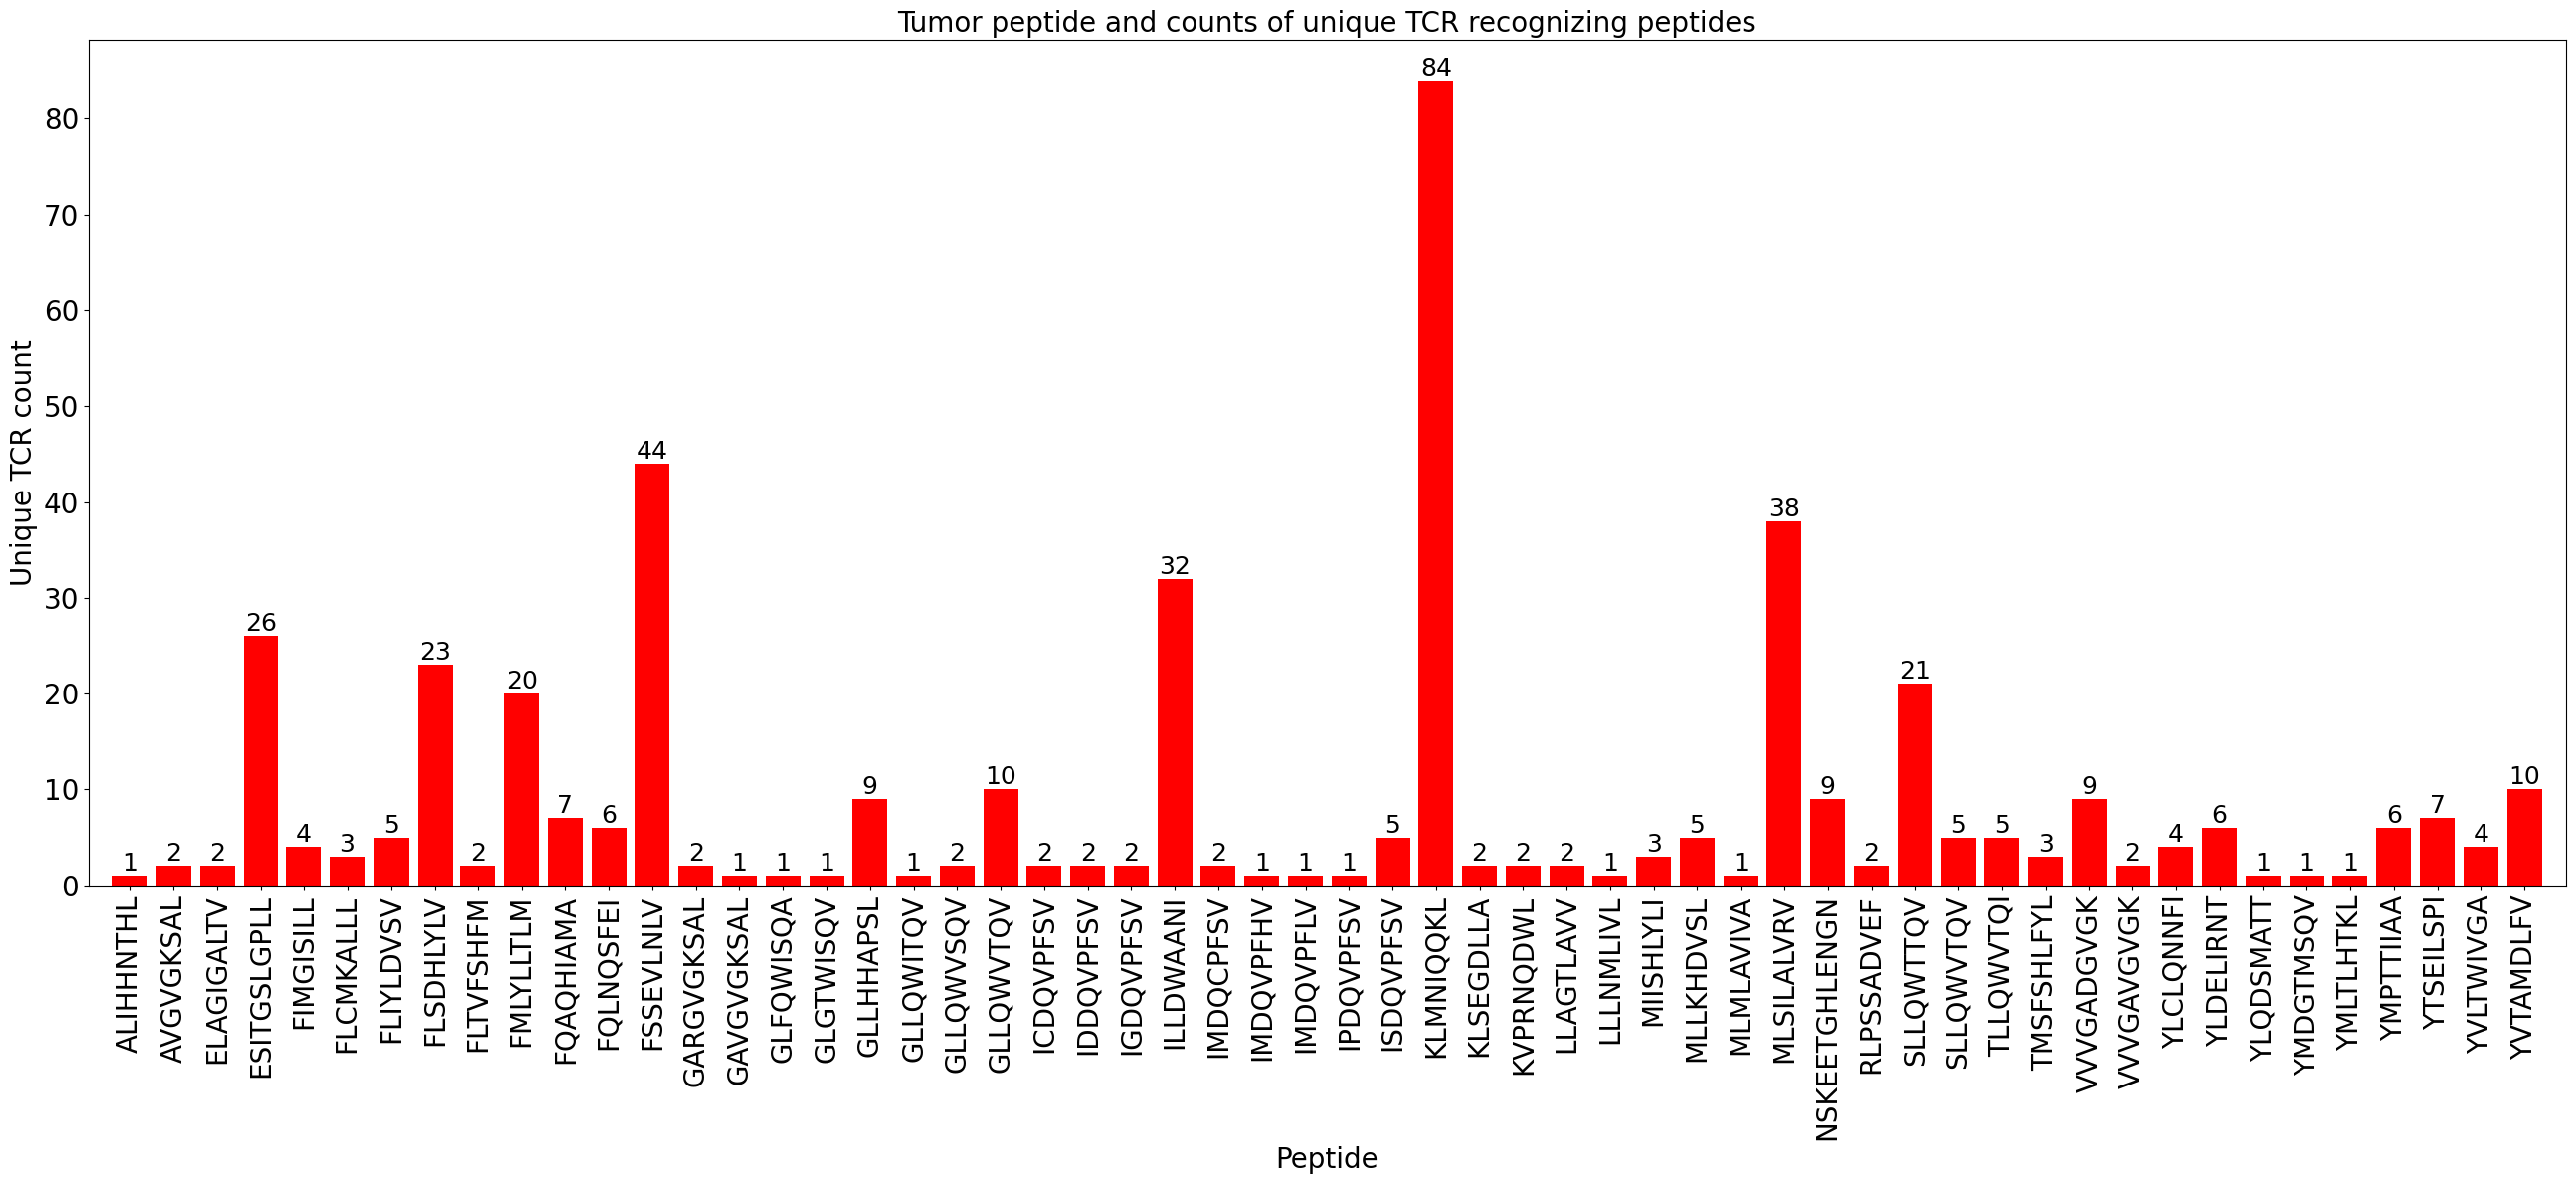

In [196]:
tumor_pred = result_high_conf_unique_TCR_count[result_high_conf_unique_TCR_count['peptide_and_type'].str.contains("Tumor")]
colors = [
    'red' if 'tumor' in str(x).lower() else 'blue' if 'viral' in str(x).lower() else "grey"
    for x in tumor_pred['peptide_and_type']
]

plt.figure(figsize=(26,12))
plt.bar(tumor_pred['Epitope'], tumor_pred['TRB_cdr3'], color = colors)
# Add y-values on top of bars
plt.margins(x=0.01)
for i, v in enumerate(tumor_pred['TRB_cdr3']):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize = 18)

plt.xlabel('Peptide', fontsize = 20)
plt.ylabel('Unique TCR count', fontsize = 20)
plt.title('Tumor peptide and counts of unique TCR recognizing peptides', fontsize=20)
plt.xticks(rotation=90, fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.show()

In [197]:
tumor_pred_match_overlap = tumor_pred.merge(match_3_databases_res_count, left_on="peptide_and_type", right_on="peptide_cat", how="left")
tumor_pred_match_overlap['count'] = tumor_pred_match_overlap['count'].fillna(0)
tumor_pred_match_overlap = tumor_pred_match_overlap[tumor_pred_match_overlap['Epitope'].str.len() < 15]
tumor_pred_match_overlap

,peptide_and_type,TRB_cdr3,Epitope,type,peptide_cat,count
0,ALIHHNTHL_Tumor,1,ALIHHNTHL,Tumor,NaN,0.0
1,AVGVGKSAL_Tumor,2,AVGVGKSAL,Tumor,NaN,0.0
2,ELAGIGALTV_Tumor,2,ELAGIGALTV,Tumor,NaN,0.0
3,ESITGSLGPLL_Tumor,26,ESITGSLGPLL,Tumor,NaN,0.0
4,FIMGISILL_Tumor,4,FIMGISILL,Tumor,NaN,0.0
5,FLCMKALLL_Tumor,3,FLCMKALLL,Tumor,NaN,0.0
6,FLIYLDVSV_Tumor,5,FLIYLDVSV,Tumor,NaN,0.0
7,FLSDHLYLV_Tumor,23,FLSDHLYLV,Tumor,NaN,0.0
8,FLTVFSHFM_Tumor,2,FLTVFSHFM,Tumor,FLTVFSHFM_Tumor,2.0
9,FMLYLLTLM_Tumor,20,FMLYLLTLM,Tumor,NaN,0.0


In [198]:
tumor_pred_match_overlap.sort_values('count')

,peptide_and_type,TRB_cdr3,Epitope,type,peptide_cat,count
0,ALIHHNTHL_Tumor,1,ALIHHNTHL,Tumor,NaN,0.0
29,ISDQVPFSV_Tumor,5,ISDQVPFSV,Tumor,NaN,0.0
31,KLSEGDLLA_Tumor,2,KLSEGDLLA,Tumor,NaN,0.0
32,KVPRNQDWL_Tumor,2,KVPRNQDWL,Tumor,NaN,0.0
33,LLAGTLAVV_Tumor,2,LLAGTLAVV,Tumor,NaN,0.0
34,LLLNMLIVL_Tumor,1,LLLNMLIVL,Tumor,NaN,0.0
35,MIISHLYLI_Tumor,3,MIISHLYLI,Tumor,NaN,0.0
36,MLLKHDVSL_Tumor,5,MLLKHDVSL,Tumor,NaN,0.0
37,MLMLAVIVA_Tumor,1,MLMLAVIVA,Tumor,NaN,0.0
38,MLSILALVRV_Tumor,38,MLSILALVRV,Tumor,NaN,0.0


In [353]:
tumor_pred_match_overlap.to_csv("tumor_pred_match_overlap_tumor_overlap_fig.csv")

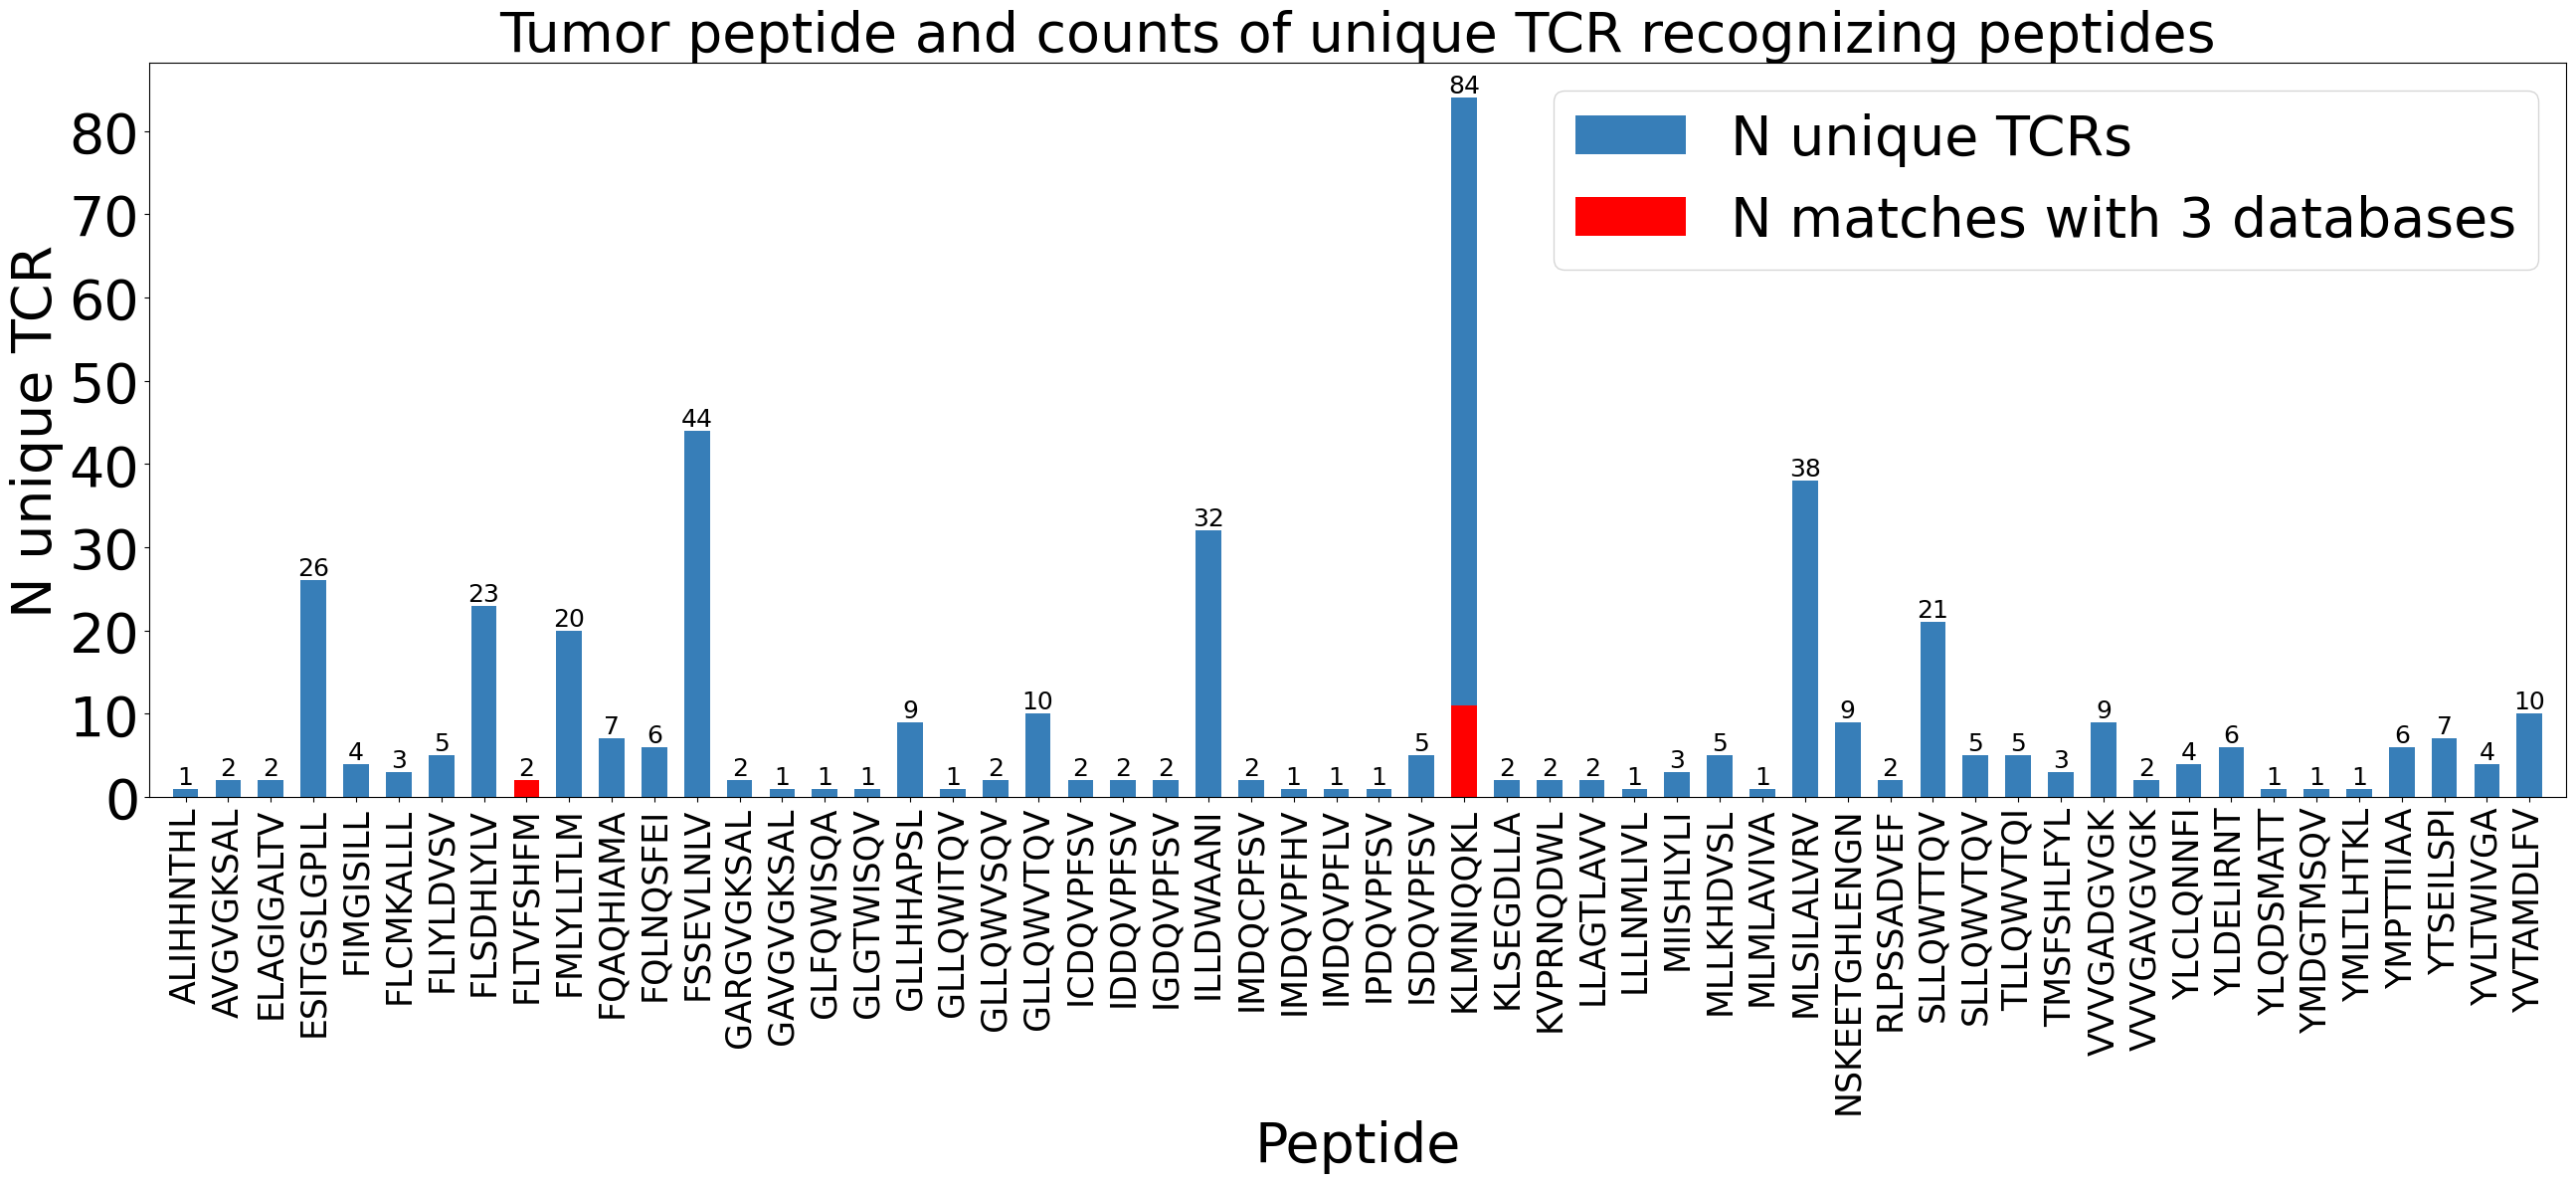

In [394]:
tumor_pred = tumor_pred_match_overlap
colors = [
    'red' if 'tumor' in str(x).lower() else 'blue' if 'viral' in str(x).lower() else "grey"
    for x in tumor_pred['peptide_and_type']
]

plt.figure(figsize=(26,12))
width = 0.6
plt.bar(tumor_pred['Epitope'], tumor_pred['TRB_cdr3'], width=width, color = "#377EB8", label='N unique TCRs')
plt.bar(tumor_pred['Epitope'], tumor_pred['count'], width=width, color = "red", label = "N matches with 3 databases")
# Add y-values on top of bars
plt.margins(x=0.01)
for i, v in enumerate(tumor_pred['TRB_cdr3']):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize = 18)

plt.xlabel('Peptide', fontsize = 40)
plt.ylabel('N unique TCR', fontsize = 40)
plt.title('Tumor peptide and counts of unique TCR recognizing peptides', fontsize=40)
plt.xticks(rotation=90, fontsize=25)
plt.yticks(fontsize=40)
plt.legend(loc='upper right', fontsize=40)
plt.tight_layout()
plt.show()

In [200]:
tumor_pred['TRB_cdr3'].sum()

454

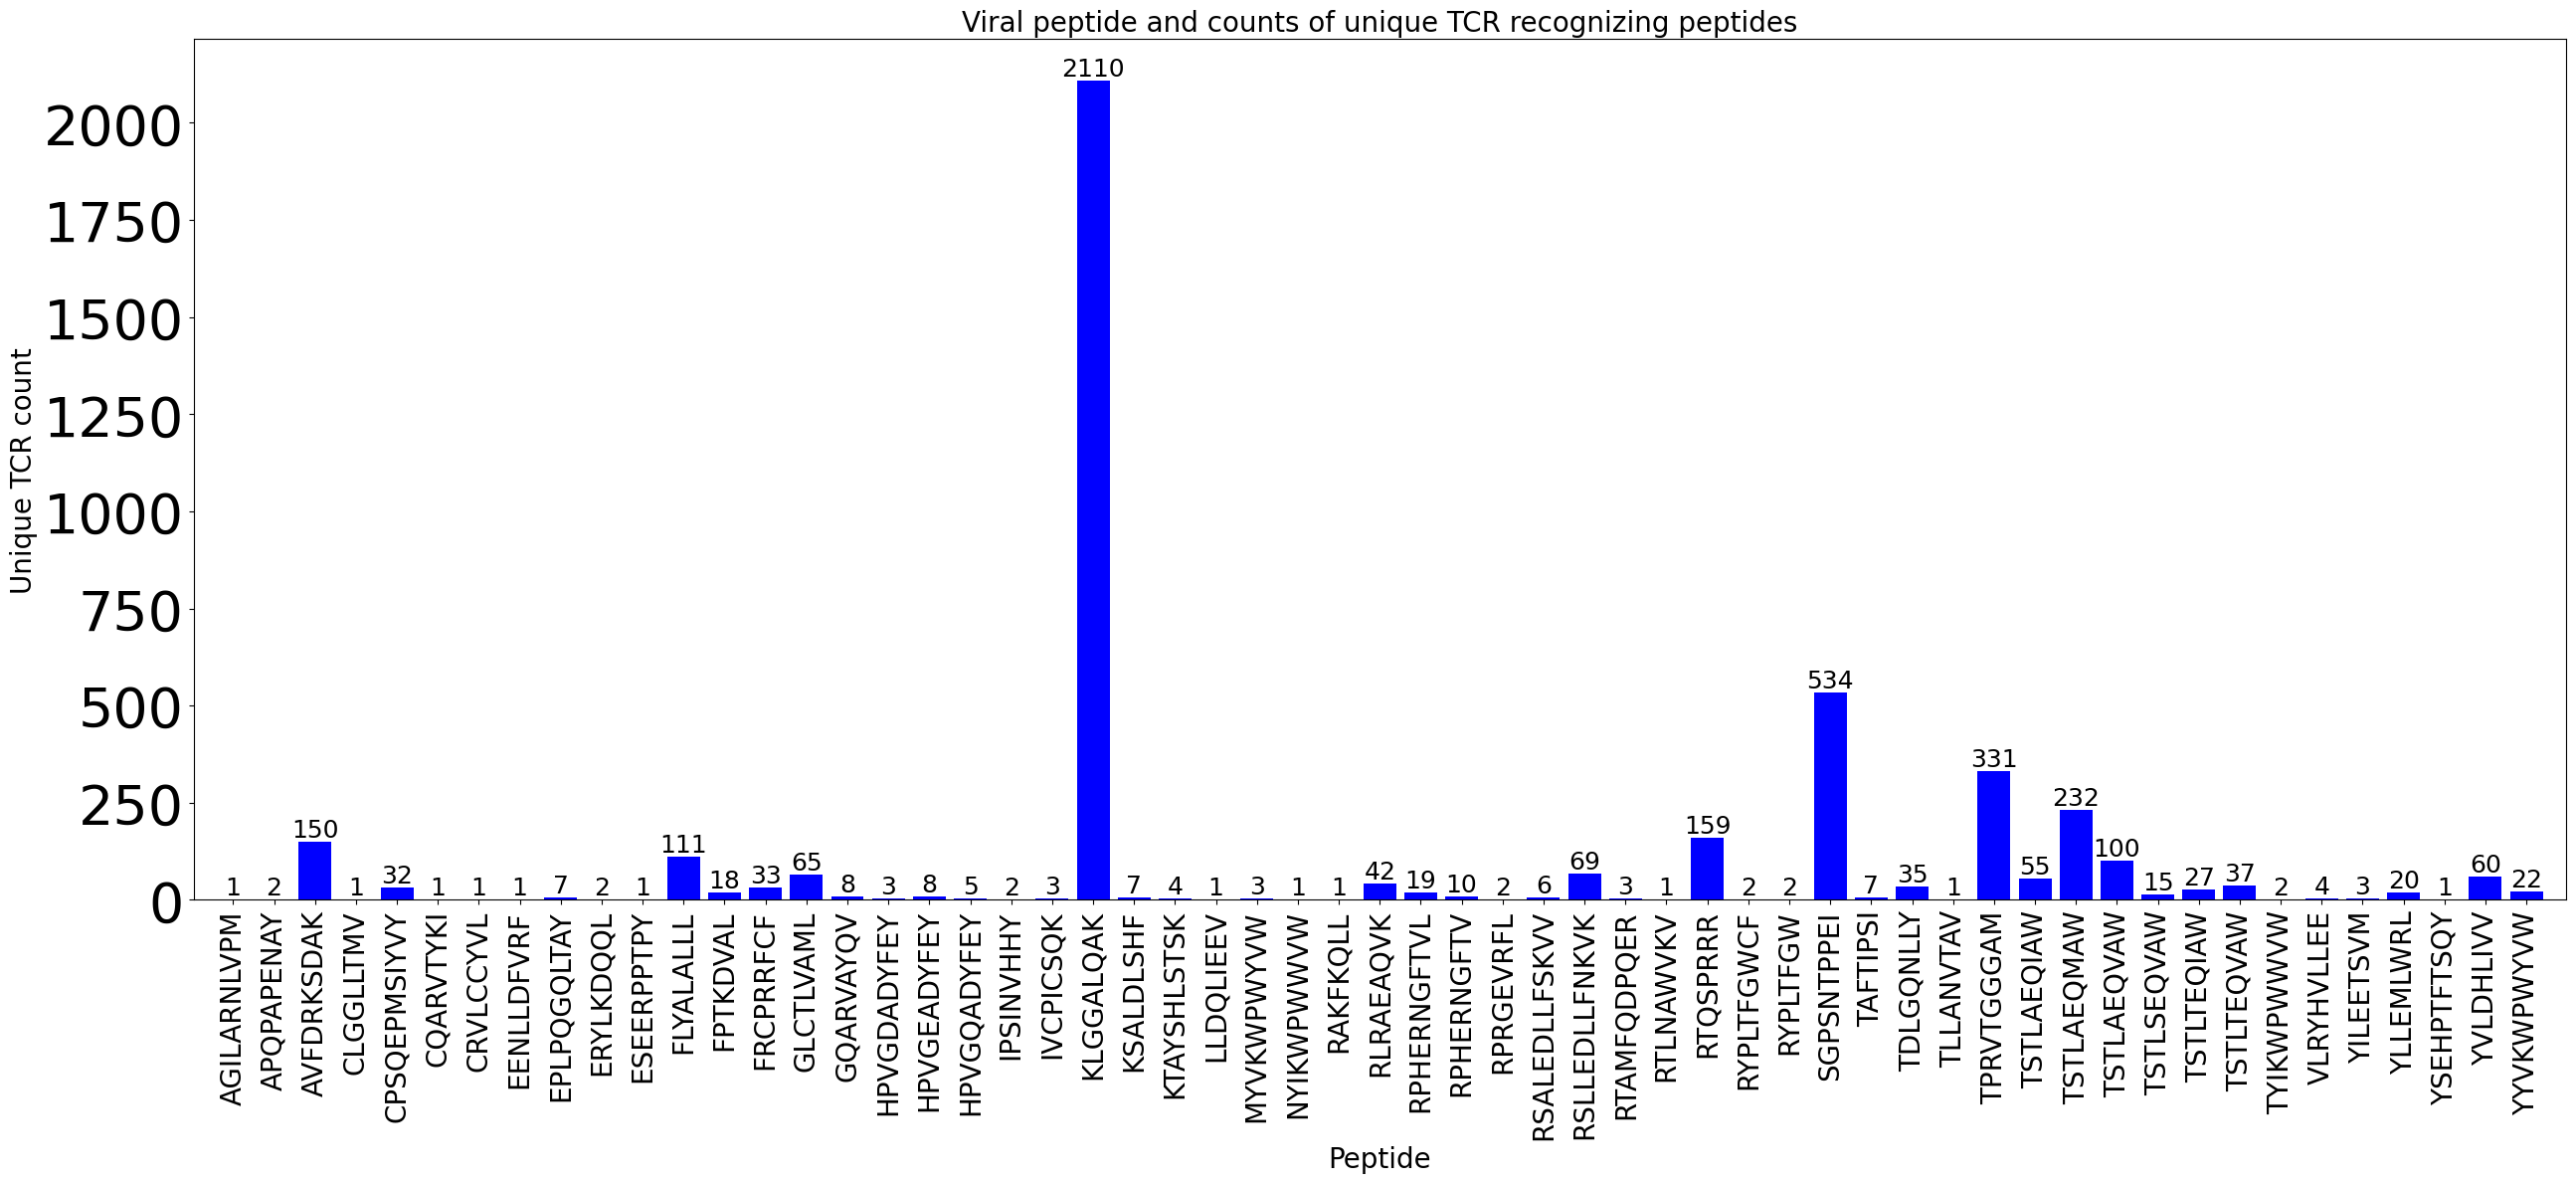

In [345]:
viral_pred = result_high_conf_unique_TCR_count[result_high_conf_unique_TCR_count['peptide_and_type'].str.contains("Viral")]
colors = [
    'red' if 'tumor' in str(x).lower() else 'blue' if 'viral' in str(x).lower() else "grey"
    for x in viral_pred['peptide_and_type']
]

plt.figure(figsize=(26,12))
plt.bar(viral_pred['Epitope'], viral_pred['TRB_cdr3'], color = colors)
# Add y-values on top of bars
plt.margins(x=0.01)
for i, v in enumerate(viral_pred['TRB_cdr3']):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize = 18)

plt.xlabel('Peptide', fontsize = 20)
plt.ylabel('Unique TCR count', fontsize = 20)
plt.title('Viral peptide and counts of unique TCR recognizing peptides', fontsize=20)
plt.xticks(rotation=90, fontsize=20)
plt.yticks(fontsize=40)
plt.tight_layout()
plt.show()

In [30]:
match_3_databases_res_count

,peptide_cat,count
0,KLGGALQAK_Viral,761
1,YVLDHLIVV_Viral,601
2,KTAYSHLSTSK_Viral,561
3,RLRAEAQVK_Viral,73
4,TPRVTGGGAM_Viral,68
...,...,...
72,LMFWASSSI_Tumor,1
73,YAKWKLCSA_Unknown,1
74,TPSVSSSISSL_Viral,1
75,SFHSLHLLF_Viral,1


In [203]:
viral_pred_match_overlap = viral_pred.merge(match_3_databases_res_count, left_on="peptide_and_type", right_on="peptide_cat", how="left")
viral_pred_match_overlap['count'] = viral_pred_match_overlap['count'].fillna(0)
viral_pred_match_overlap

,peptide_and_type,TRB_cdr3,Epitope,type,peptide_cat,count
0,AGILARNLVPM_Viral,1,AGILARNLVPM,Viral,NaN,0.0
1,APQPAPENAY_Viral,2,APQPAPENAY,Viral,NaN,0.0
2,AVFDRKSDAK_Viral,150,AVFDRKSDAK,Viral,AVFDRKSDAK_Viral,28.0
3,CLGGLLTMV_Viral,1,CLGGLLTMV,Viral,CLGGLLTMV_Viral,15.0
4,CPSQEPMSIYVY_Viral,32,CPSQEPMSIYVY,Viral,NaN,0.0
5,CQARVTYKI_Viral,1,CQARVTYKI,Viral,NaN,0.0
6,CRVLCCYVL_Viral,1,CRVLCCYVL,Viral,CRVLCCYVL_Viral,2.0
7,EENLLDFVRF_Viral,1,EENLLDFVRF,Viral,NaN,0.0
8,EPLPQGQLTAY_Viral,7,EPLPQGQLTAY,Viral,NaN,0.0
9,ERYLKDQQL_Viral,2,ERYLKDQQL,Viral,NaN,0.0


In [204]:
viral_pred_match_overlap = viral_pred_match_overlap[viral_pred_match_overlap['Epitope'].str.len() < 15]

In [205]:
viral_pred_match_overlap.sort_values("count")

,peptide_and_type,TRB_cdr3,Epitope,type,peptide_cat,count
0,AGILARNLVPM_Viral,1,AGILARNLVPM,Viral,NaN,0.0
31,RPRGEVRFL_Viral,2,RPRGEVRFL,Viral,NaN,0.0
32,RSALEDLLFSKVV_Viral,6,RSALEDLLFSKVV,Viral,NaN,0.0
33,RSLLEDLLFNKVK_Viral,69,RSLLEDLLFNKVK,Viral,NaN,0.0
34,RTAMFQDPQER_Viral,3,RTAMFQDPQER,Viral,NaN,0.0
35,RTLNAWVKV_Viral,1,RTLNAWVKV,Viral,NaN,0.0
37,RYPLTFGWCF_Viral,2,RYPLTFGWCF,Viral,NaN,0.0
38,RYPLTFGW_Viral,2,RYPLTFGW,Viral,NaN,0.0
39,SGPSNTPPEI_Viral,534,SGPSNTPPEI,Viral,NaN,0.0
40,TAFTIPSI_Viral,7,TAFTIPSI,Viral,NaN,0.0


In [354]:
viral_pred_match_overlap.to_csv("viral_pred_match_overlap_viral_overlap_fig.csv")

In [355]:
viral_pred_match_overlap

,peptide_and_type,TRB_cdr3,Epitope,type,peptide_cat,count
0,AGILARNLVPM_Viral,1,AGILARNLVPM,Viral,NaN,0.0
1,APQPAPENAY_Viral,2,APQPAPENAY,Viral,NaN,0.0
2,AVFDRKSDAK_Viral,150,AVFDRKSDAK,Viral,AVFDRKSDAK_Viral,28.0
3,CLGGLLTMV_Viral,1,CLGGLLTMV,Viral,CLGGLLTMV_Viral,15.0
4,CPSQEPMSIYVY_Viral,32,CPSQEPMSIYVY,Viral,NaN,0.0
5,CQARVTYKI_Viral,1,CQARVTYKI,Viral,NaN,0.0
6,CRVLCCYVL_Viral,1,CRVLCCYVL,Viral,CRVLCCYVL_Viral,2.0
7,EENLLDFVRF_Viral,1,EENLLDFVRF,Viral,NaN,0.0
8,EPLPQGQLTAY_Viral,7,EPLPQGQLTAY,Viral,NaN,0.0
9,ERYLKDQQL_Viral,2,ERYLKDQQL,Viral,NaN,0.0


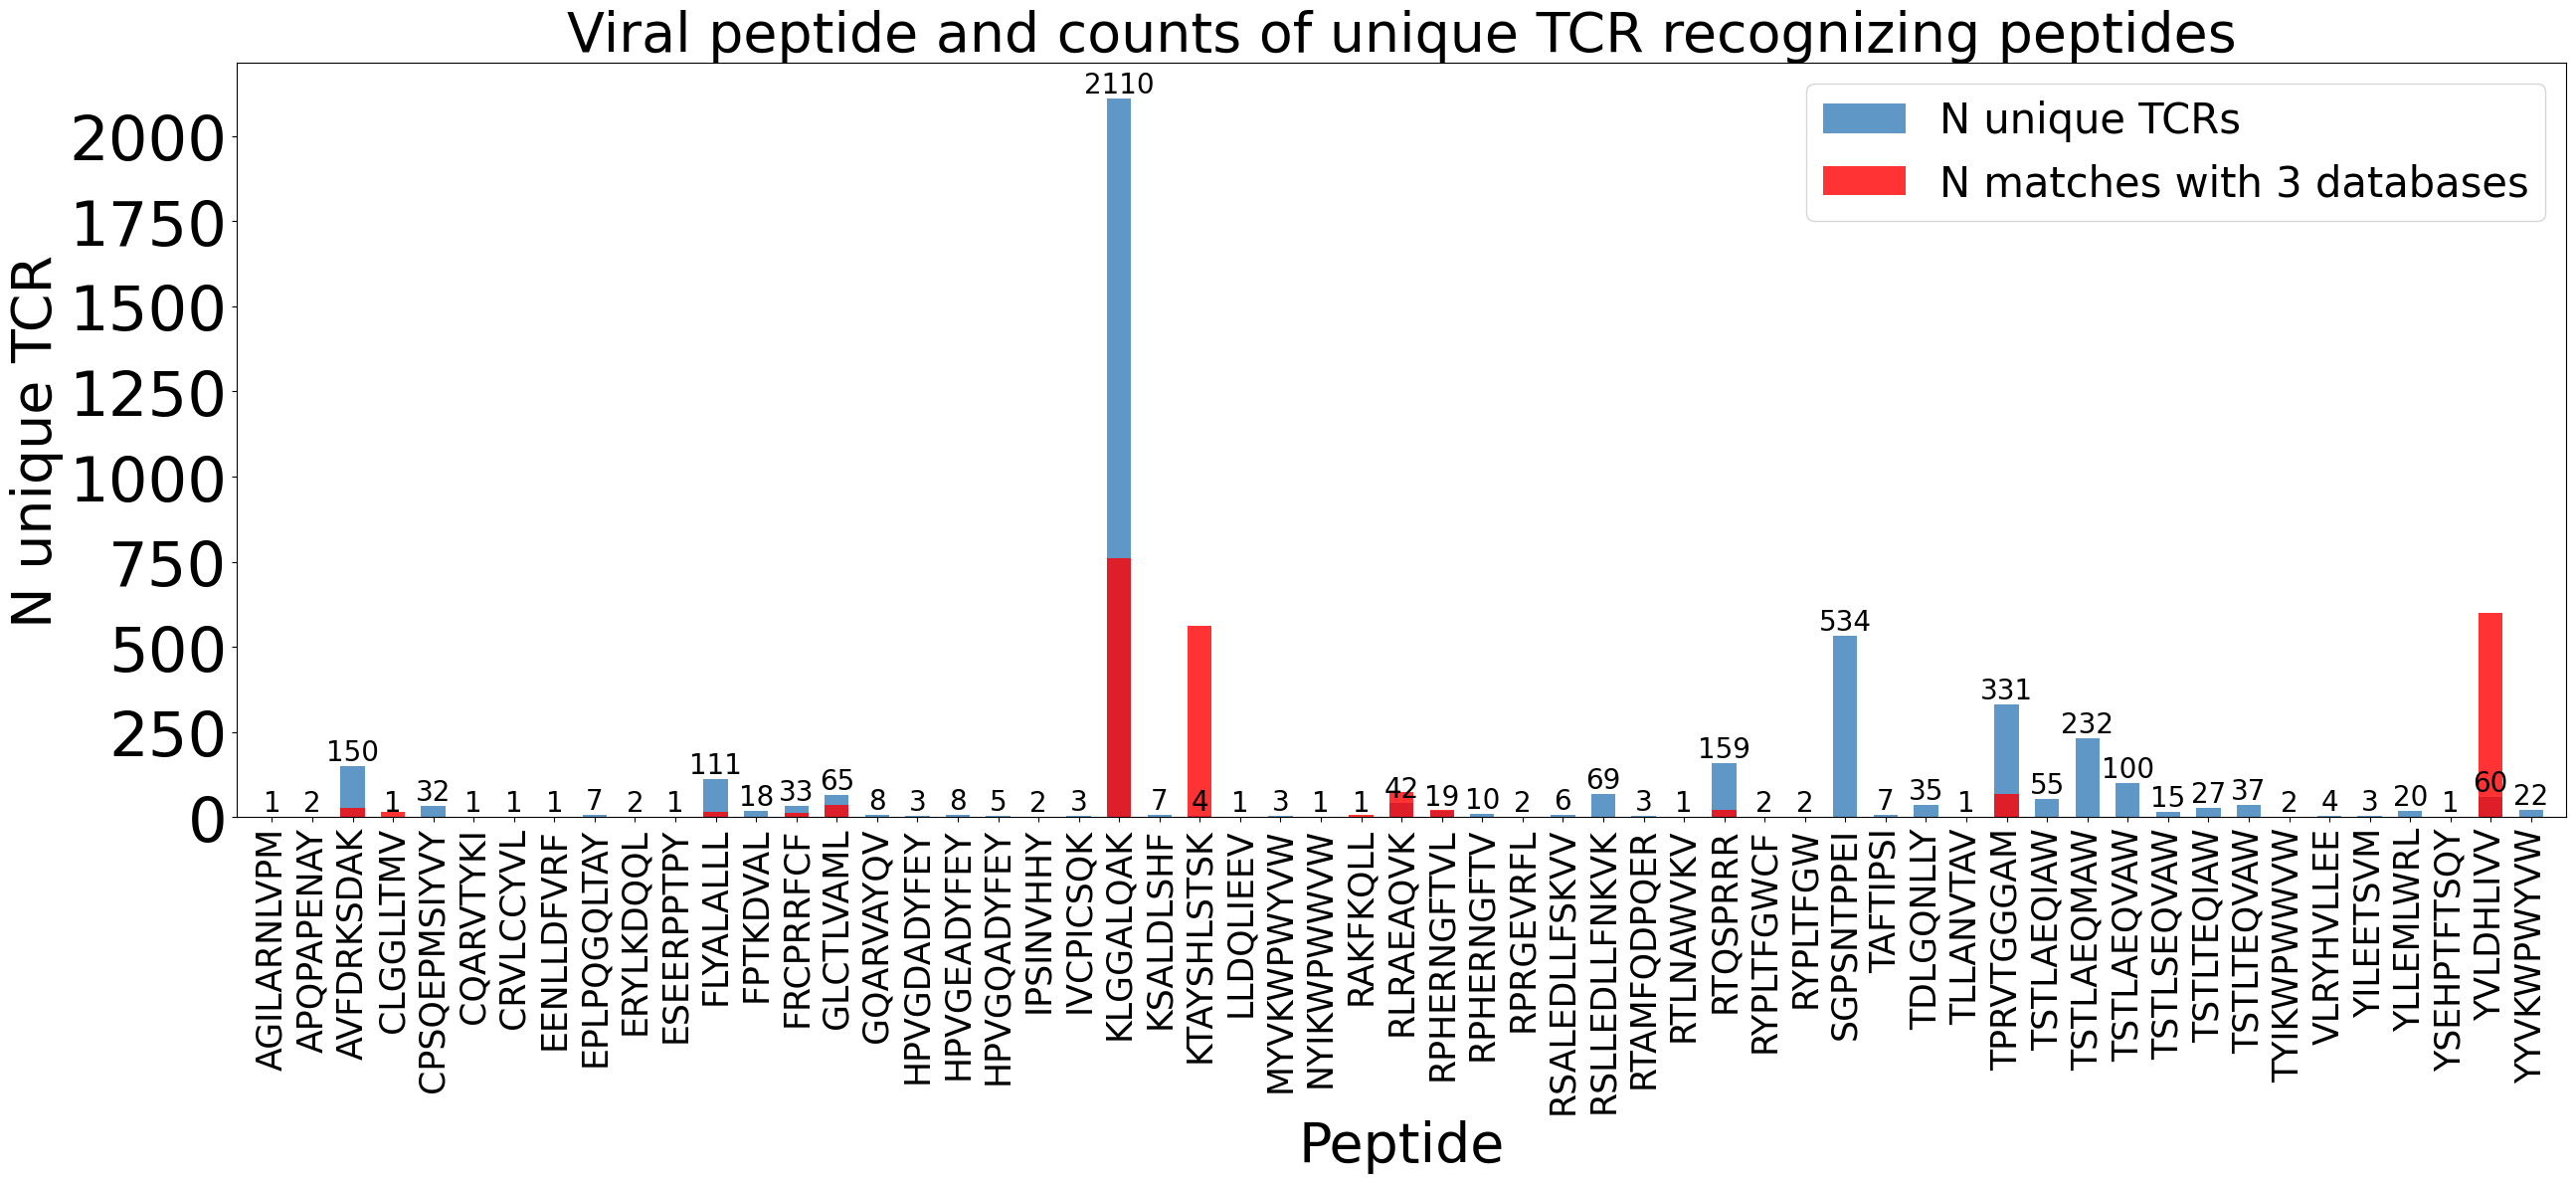

In [390]:
viral_pred = viral_pred_match_overlap
colors = [
    'red' if 'tumor' in str(x).lower() else 'blue' if 'viral' in str(x).lower() else "grey"
    for x in viral_pred['peptide_and_type']
]

plt.figure(figsize=(26,12))
width = 0.6
plt.bar(viral_pred['Epitope'], viral_pred['TRB_cdr3'], width=width, color = "#377EB8", alpha = 0.8, label='N unique TCRs')
plt.bar(viral_pred['Epitope'], viral_pred['count'], width=width, color = "red", alpha = 0.8,  label='N matches with 3 databases')
# Add y-values on top of bars
plt.margins(x=0.01)
for i, v in enumerate(viral_pred['TRB_cdr3']):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize = 20)

plt.xlabel('Peptide', fontsize = 40)
plt.ylabel('N unique TCR', fontsize = 40)
plt.title('Viral peptide and counts of unique TCR recognizing peptides', fontsize=40)
plt.xticks(rotation=90, fontsize=25)
plt.yticks(fontsize=45)
plt.tight_layout()
plt.legend(loc='upper right', fontsize=30)
plt.show()

In [207]:
match_3_databases_pred_res = pd.read_csv("match_3_databases_pred_res.csv", index_col = 0)
match_3_databases_pred_res

,match
leiden,
0,62
1,54
2,95
3,77
4,22
5,5
6,61
7,42
8,26


In [208]:
cluster_size_dat = pd.read_csv("cluster_size_dat.csv", index_col = 0)
cluster_size_dat

,count
leiden,
0,2374
1,1678
3,1395
2,1327
6,861
5,769
4,749
8,700
9,656


In [209]:
Apexigen_emb_no_HD = Apexigen_emb[~Apexigen_emb.obs['patient'].str.contains("HD")]

In [210]:
pd.DataFrame(Apexigen_emb.obs['leiden'].value_counts())

,count
leiden,
0,3354
1,1788
2,1589
3,1402
4,1051
5,954
6,874
7,781
8,712


In [211]:
result_high_conf = result_high_conf[result_high_conf['Epitope'].str.len() < 15]

In [249]:
epitopes = set(viral_pred_match_overlap['Epitope']) | set(tumor_pred_match_overlap['Epitope'])

tmp = result_high_conf[result_high_conf['Epitope'].isin(epitopes)]

In [251]:
tmp

,Unnamed: 0,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,...,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair,barcode,leiden,Epitope_type,peptide_cat,peptide_and_type
11056015,11056015,0,5455.0,1945,PD,05,pathCR,05_pre,pre_CD40,8.604288,...,CSASGITASVNEKLFF,CATGRFTGGGNKLTF,KLGGALQAK,0.988152,CSASGITASVNEKLFF_KLGGALQAK,AAACCTGAGAGGTTAT-1_05_pre,5,regulatory protein IE1 [Human betaherpesvirus ...,Viral,KLGGALQAK_Viral
20255912,20255912,0,3233.0,1558,PD,04,pathCR,04_post,post_CD40,8.081165,...,CSAHPGQGPYYEQYF,CAVDIYTRLMF,KLGGALQAK,0.960459,CSAHPGQGPYYEQYF_KLGGALQAK,AAACCTGAGCTAGTGG-1_04_post,12,regulatory protein IE1 [Human betaherpesvirus ...,Viral,KLGGALQAK_Viral
4557902,4557902,0,3184.0,1264,PD,05,pathCR,05_pre,pre_CD40,8.065893,...,CASSFRGSYTYEQYF,CAFSYGGATNKLIF,SGPSNTPPEI,0.965970,CASSFRGSYTYEQYF_SGPSNTPPEI,AAACCTGAGGAATTAC-1_05_pre,4,Early E1A 32 kDa protein_Human adenovirus 5 (A...,Viral,SGPSNTPPEI_Viral
12165642,12165642,4,1756.0,627,PD,05,pathCR,05_post,post_CD40,7.470794,...,CASSVATAGGIGYTF,CAMREGWNTGTASKLTF,RTQSPRRR,0.983772,CASSVATAGGIGYTF_RTQSPRRR,AAACCTGAGGCGCTCT-1-4,0,"precore/core protein, partial [Hepatitis B vir...",Viral,RTQSPRRR_Viral
3790767,3790767,0,4173.0,1613,PD,04,pathCR,04_post,post_CD40,8.336391,...,CASSPSAEQYF,CVVNTGAGSYQLTF,YLLEMLWRL,0.971430,CASSPSAEQYF_YLLEMLWRL,AAACCTGCAAACCCAT-1_04_post,0,"LMP1 protein (Epstein-Barr virus, putative LYD...",Viral,YLLEMLWRL_Viral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7988937,7988937,0,7320.0,2396,PD,01,nopathCR,01_pre,pre_CD40,8.898366,...,CSARGPSQSNEQFF,CALSSINQAGTALIF,KLGGALQAK,0.981525,CSARGPSQSNEQFF_KLGGALQAK,TTTGTCATCAAGATCC-1_01_pre,12,regulatory protein IE1 [Human betaherpesvirus ...,Viral,KLGGALQAK_Viral
19534976,19534976,0,10939.0,3594,NaN,02,pathCR,02_post,post_CD40,9.300090,...,CASSAAFWYTGELFF,CAMSAMNRDDKIIF,SGPSNTPPEI,0.981450,CASSAAFWYTGELFF_SGPSNTPPEI,TTTGTCATCATGTCTT-1_02_post,1,Early E1A 32 kDa protein_Human adenovirus 5 (A...,Viral,SGPSNTPPEI_Viral
139086,139086,0,12700.0,3547,PD,01,nopathCR,01_pre,pre_CD40,9.449357,...,CASSVDSREEDTQYF,CALSEFSHGGSQGNLIF,TPRVTGGGAM,0.955753,CASSVDSREEDTQYF_TPRVTGGGAM,TTTGTCATCGAGAGCA-1_01_pre,11,pp65_Human herpesvirus 5 (Human cytomegalovirus),Viral,TPRVTGGGAM_Viral
9747092,9747092,0,4114.0,1822,NaN,02,pathCR,02_post,post_CD40,8.322151,...,CASSRDRNYGYTF,CAVTGNQFYF,KLGGALQAK,0.913994,CASSRDRNYGYTF_KLGGALQAK,TTTGTCATCGCACTCT-1_02_post,10,regulatory protein IE1 [Human betaherpesvirus ...,Viral,KLGGALQAK_Viral


In [253]:
result_high_conf['peptide_cat'].value_counts()

peptide_cat
Viral    6535
Tumor     646
Name: count, dtype: int64

In [252]:
result_high_conf['peptide_cat'].value_counts()

peptide_cat
Viral    6535
Tumor     646
Name: count, dtype: int64

In [257]:
match_3_databases_res_count[['Epitope',"type"]] = match_3_databases_res_count['peptide_cat'].str.split("_",expand = True)
match_3_databases_res_count

,peptide_cat,count,Epitope,type
0,KLGGALQAK_Viral,761,KLGGALQAK,Viral
1,YVLDHLIVV_Viral,601,YVLDHLIVV,Viral
2,KTAYSHLSTSK_Viral,561,KTAYSHLSTSK,Viral
3,RLRAEAQVK_Viral,73,RLRAEAQVK,Viral
4,TPRVTGGGAM_Viral,68,TPRVTGGGAM,Viral
...,...,...,...,...
72,LMFWASSSI_Tumor,1,LMFWASSSI,Tumor
73,YAKWKLCSA_Unknown,1,YAKWKLCSA,Unknown
74,TPSVSSSISSL_Viral,1,TPSVSSSISSL,Viral
75,SFHSLHLLF_Viral,1,SFHSLHLLF,Viral


In [260]:
result_high_conf = result_high_conf[result_high_conf['Epitope'].isin(match_3_databases_res_count['Epitope'].values)]
# tmp['leiden'].value_counts()

In [261]:
pred_count = pd.DataFrame(result_high_conf['leiden'].value_counts())
pred_count.columns = ['pred_count']
pred_count

,pred_count
leiden,
0,740
5,640
9,526
3,495
1,437
2,336
8,295
12,291
6,277


In [214]:
cluster_size_dat.columns = ["cluster_size"]
cluster_size_dat

,cluster_size
leiden,
0,2374
1,1678
3,1395
2,1327
6,861
5,769
4,749
8,700
9,656


In [215]:
match_3_databases_pred_res

,match
leiden,
0,62
1,54
2,95
3,77
4,22
5,5
6,61
7,42
8,26


In [263]:
pred_count.index=pred_count.index.astype("int64")

In [217]:
match_3_databases_pred_res.index

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20],
      dtype='int64', name='leiden')

In [270]:
Apexigen_exact_match = pd.read_csv("Apexigen_exact_match_with_3_datasets.csv")
Apexigen_exact_match

,Unnamed: 0,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,...,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair,final_cell_type
0,12316522,43,1403.0,697,PD,05,pathCR,05_LTF3,follow_up,7.246368,...,CD8T,CD8T_GrH2,CD8_GrH,CD8_T,CASSLIGVSSYNEQFF,CATVARMDSSYKLIF,RPPIFIRRL,0.000049,CASSLIGVSSYNEQFF_RPPIFIRRL,CD8T_GrH
1,4355372,0,9137.0,3175,NaN,02,pathCR,02_post,post_CD40,9.120088,...,Treg,Treg,Treg1,Treg,CASSLSGGPQHF,CIVSRSNFGNEKLTF,LMFWASSSI,0.000131,CASSLSGGPQHF_LMFWASSSI,Treg
2,4060833,0,6197.0,2414,NaN,02,pathCR,02_post,post_CD40,8.731821,...,Treg,Treg,Treg1,Treg,CASRQSNQPQHF,CAPQGYCMRF,RLRAEAQVK,0.000609,CASRQSNQPQHF_RLRAEAQVK,Treg
3,8628342,0,1969.0,1044,PD,04,pathCR,04_post,post_CD40,7.585281,...,CD8_Tcell,CD8T_GrH,CD8T_GrB,CD8_T,CASSLGGSYEQYF,CAYRTPLPSPGGTYKYIF,LPRRSGAAGA,0.002298,CASSLGGSYEQYF_LPRRSGAAGA,CD8T_GrB
4,1128572,45,1747.0,849,PD,01,nopathCR,01_surgery,surgery,7.465655,...,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CASSPNRNTEAFF,CAASIGNFGNEKLTF,RPHERNGFTVL,0.002610,CASSPNRNTEAFF_RPHERNGFTVL,CD8T_GrH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2493,20674393,0,5236.0,1936,NaN,02,pathCR,02_post,post_CD40,8.563313,...,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CSARTGDTEAFF,CAVMDSNYQLIW,KLGGALQAK,0.992327,CSARTGDTEAFF_KLGGALQAK,CD4T_naive
2494,20825150,0,4438.0,1701,CR,03,pathCR,03_pre,pre_CD40,8.397959,...,CD4_Tcell,CD4T_CXCL13,Treg1,Treg,CASSPQRNTEAFF,CAVVSLGRPVGGSYIPTF,TPRVTGGGAM,0.992681,CASSPQRNTEAFF_TPRVTGGGAM,Treg
2495,4638901,0,3731.0,1689,PD,04,pathCR,04_post,post_CD40,8.224432,...,T/NK,Teff/NK,CD8T_GrH,CD8_T,CASSLGQGYEQYF,CAVRNNARLMF,KLMNIQQKL,0.993111,CASSLGQGYEQYF_KLMNIQQKL,CD8T_GrH
2496,7277653,0,1334.0,799,PD,04,pathCR,04_post,post_CD40,7.195937,...,CD8_Tcell,CD8T_GrH,CD8T_GrB,CD8_T,CASSLVQGMNTEAFF,CIVSRGSNYKLTF,KLGGALQAK,0.993885,CASSLVQGMNTEAFF_KLGGALQAK,CD8T_GrB


In [299]:
result['exact_match'] = [1 if x in Apexigen_exact_match['TCR_Epitope_pair'].values else 0 for x in result['TCR_Epitope_pair']]

In [300]:
exact_match_cluster_count = pd.DataFrame(result[result['exact_match'] == 1]['leiden'].value_counts())
exact_match_cluster_count.columns = ['exact_match_count']
exact_match_cluster_count

,exact_match_count
leiden,
9,459
11,71
6,28
2,25
0,24
3,21
1,18
4,11
7,10


In [301]:
exact_match_cluster_count.index = exact_match_cluster_count.index.astype('int64')

In [330]:
merge_cluster_size_pred__cluster_size = cluster_size_dat.merge(match_3_databases_pred_res, on='leiden').merge(pred_count, on='leiden')
merge_cluster_size_pred__cluster_size = merge_cluster_size_pred__cluster_size.merge(exact_match_cluster_count, on="leiden", how = "left")
merge_cluster_size_pred__cluster_size = merge_cluster_size_pred__cluster_size.fillna(0)
merge_cluster_size_pred__cluster_size['predict_not_oveplap_match'] = merge_cluster_size_pred__cluster_size['pred_count'] - merge_cluster_size_pred__cluster_size['exact_match_count']
merge_cluster_size_pred__cluster_size = merge_cluster_size_pred__cluster_size.fillna(0)
merge_cluster_size_pred__cluster_size


,cluster_size,match,pred_count,exact_match_count,predict_not_oveplap_match
leiden,,,,,
0,2374,62,740,24.0,716.0
1,1678,54,437,18.0,419.0
3,1395,77,495,21.0,474.0
2,1327,95,336,25.0,311.0
6,861,61,277,28.0,249.0
5,769,5,640,5.0,635.0
4,749,22,210,11.0,199.0
8,700,26,295,9.0,286.0
9,656,562,526,459.0,67.0


In [331]:
merge_cluster_size_pred__cluster_size.reset_index(inplace=True)
merge_cluster_size_pred__cluster_size

,leiden,cluster_size,match,pred_count,exact_match_count,predict_not_oveplap_match
0,0,2374,62,740,24.0,716.0
1,1,1678,54,437,18.0,419.0
2,3,1395,77,495,21.0,474.0
3,2,1327,95,336,25.0,311.0
4,6,861,61,277,28.0,249.0
5,5,769,5,640,5.0,635.0
6,4,749,22,210,11.0,199.0
7,8,700,26,295,9.0,286.0
8,9,656,562,526,459.0,67.0
9,10,648,2,147,1.0,146.0


In [332]:
merge_cluster_size_pred__cluster_size = merge_cluster_size_pred__cluster_size.sort_values('leiden')
merge_cluster_size_pred__cluster_size['leiden'] = merge_cluster_size_pred__cluster_size['leiden'].astype('str')

In [333]:
merge_cluster_size_pred__cluster_size

,leiden,cluster_size,match,pred_count,exact_match_count,predict_not_oveplap_match
0,0,2374,62,740,24.0,716.0
1,1,1678,54,437,18.0,419.0
3,2,1327,95,336,25.0,311.0
2,3,1395,77,495,21.0,474.0
6,4,749,22,210,11.0,199.0
5,5,769,5,640,5.0,635.0
4,6,861,61,277,28.0,249.0
10,7,644,42,149,10.0,139.0
7,8,700,26,295,9.0,286.0
8,9,656,562,526,459.0,67.0


In [329]:
df_test

,leiden,cluster_size,match,pred_count,exact_match_count,predict_not_oveplap_match,match_3_database_norm,predict_norm,predict_not_oveplap_match_norm,rest,unmatched_not_predicted
0,0,2374,62,740,24.0,716.0,0.026116,0.311710,0.301601,0.672283,1634
1,1,1678,54,437,18.0,419.0,0.032181,0.260429,0.249702,0.718117,1241
3,2,1327,95,336,25.0,311.0,0.071590,0.253203,0.234363,0.694047,991
2,3,1395,77,495,21.0,474.0,0.055197,0.354839,0.339785,0.605018,900
6,4,749,22,210,11.0,199.0,0.029372,0.280374,0.265688,0.704940,539
5,5,769,5,640,5.0,635.0,0.006502,0.832250,0.825748,0.167750,129
4,6,861,61,277,28.0,249.0,0.070848,0.321719,0.289199,0.639954,584
10,7,644,42,149,10.0,139.0,0.065217,0.231366,0.215839,0.718944,495
7,8,700,26,295,9.0,286.0,0.037143,0.421429,0.408571,0.554286,405
8,9,656,562,526,459.0,67.0,0.856707,0.801829,0.102134,0.041159,130


In [358]:
merge_cluster_size_pred__cluster_size.to_csv("merge_cluster_size_pred__cluster_size_prediction_barplot_and_line_plot.csv")

In [357]:
df_test

,leiden,cluster_size,match,pred_count,exact_match_count,predict_not_oveplap_match,match_3_database_norm,predict_norm,predict_not_oveplap_match_norm,rest,unmatched_not_predicted
0,0,2374,62,740,24.0,716.0,0.026116,0.311710,0.301601,0.672283,1634
1,1,1678,54,437,18.0,419.0,0.032181,0.260429,0.249702,0.718117,1241
3,2,1327,95,336,25.0,311.0,0.071590,0.253203,0.234363,0.694047,991
2,3,1395,77,495,21.0,474.0,0.055197,0.354839,0.339785,0.605018,900
6,4,749,22,210,11.0,199.0,0.029372,0.280374,0.265688,0.704940,539
5,5,769,5,640,5.0,635.0,0.006502,0.832250,0.825748,0.167750,129
4,6,861,61,277,28.0,249.0,0.070848,0.321719,0.289199,0.639954,584
10,7,644,42,149,10.0,139.0,0.065217,0.231366,0.215839,0.718944,495
7,8,700,26,295,9.0,286.0,0.037143,0.421429,0.408571,0.554286,405
8,9,656,562,526,459.0,67.0,0.856707,0.801829,0.102134,0.041159,130


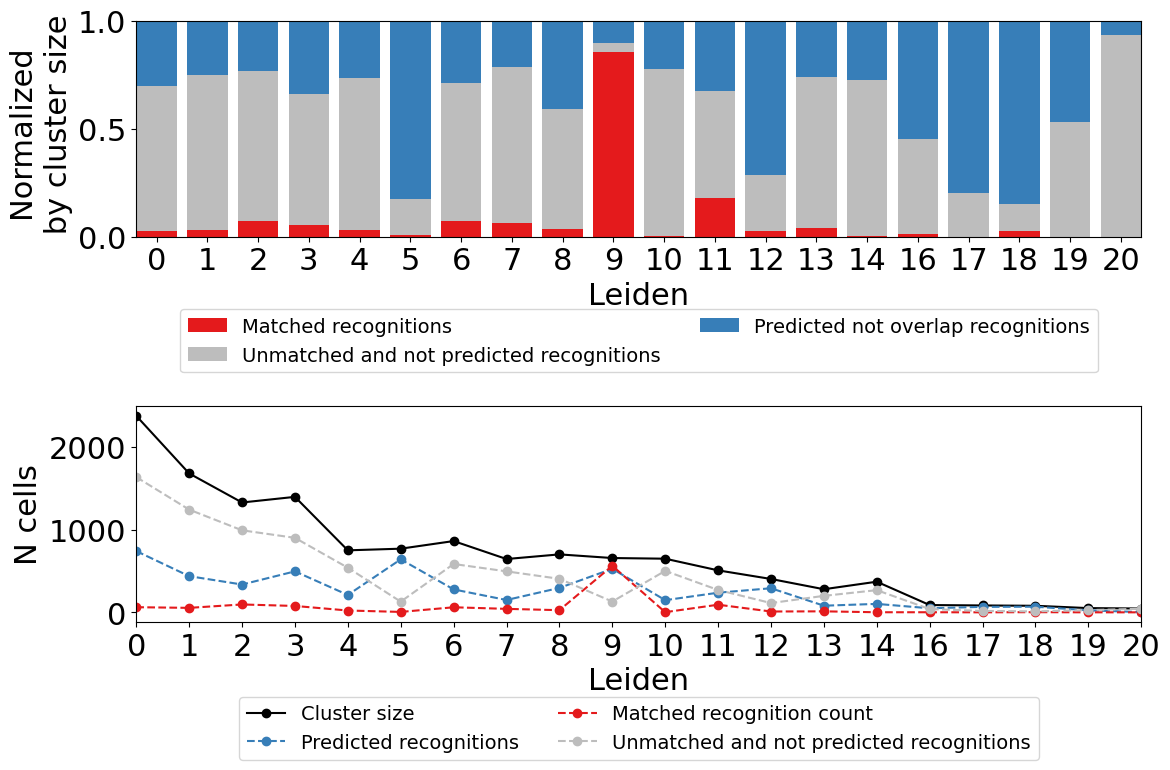

<Figure size 640x480 with 0 Axes>

In [398]:
import pandas as pd
import matplotlib.pyplot as plt

df_test = merge_cluster_size_pred__cluster_size.copy()
# df_test = df_test.reset_index(drop=False)
# --- Normalize ---
df_test['match_3_database_norm'] = df_test['match'] / df_test['cluster_size']
df_test['predict_norm'] = df_test['pred_count'] / df_test['cluster_size']
df_test['predict_not_oveplap_match_norm'] = df_test['predict_not_oveplap_match'] / df_test['cluster_size']
df_test['rest'] = 1  - df_test['predict_not_oveplap_match_norm'] - df_test['match_3_database_norm']
df_test['unmatched_not_predicted'] = df_test['cluster_size'] - df_test['pred_count'] 
# --- Plot ---
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(12, 8), sharex=False,
    gridspec_kw={'height_ratios': [1, 1]}  # top smaller than bottom
)

# Bottom: B (red)
ax_top.bar(df_test['leiden'], df_test['match_3_database_norm'], color="#E41A1C", label='Matched recognitions')

# Middle: rest (grey)
ax_top.bar(df_test['leiden'], df_test['rest'], bottom=df_test['match_3_database_norm'], color="#BDBDBD", label='Unmatched and not predicted recognitions')

# Top: C (blue)
ax_top.bar(df_test['leiden'], df_test['predict_norm'], 
       bottom=df_test['match_3_database_norm'] + df_test['rest'], 
       color="#377EB8", label='Predicted not overlap recognitions')



ax_bottom.plot(df_test['leiden'], df_test['cluster_size'], marker='o', color='black', label='Cluster size')
ax_bottom.plot(df_test['leiden'], df_test['pred_count'], marker='o', color="#377EB8", linestyle='--', label='Predicted recognitions')
ax_bottom.plot(df_test['leiden'], df_test['match'], marker='o', color="#E41A1C", linestyle='--', label='Matched recognition count')
ax_bottom.plot(df_test['leiden'], df_test['unmatched_not_predicted'], marker='o', color="#BDBDBD", linestyle='--', label='Unmatched and not predicted recognitions')
ax_bottom.set_ylabel('N cells', fontsize = 22)
ax_bottom.set_xlabel('Leiden', fontsize = 22)
ax_bottom.tick_params(axis='x', labelsize=22)
ax_bottom.tick_params(axis='y', labelsize=22)
# Labels and legend
ax_top.set_ylabel('Normalized \n by cluster size', fontsize = 22)
ax_top.set_xlabel('Leiden', fontsize = 22)
ax_top.tick_params(axis='x', labelsize=22)
ax_top.tick_params(axis='y', labelsize=22)
ax_top.margins(x=0)
ax_top.set_ylim(0, 1)
ax_top.legend(loc='upper center', bbox_to_anchor=(0.5, -0.29), ncol=2, fontsize=14)
ax_bottom.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2, fontsize=14)
ax_bottom.margins(x=0)
plt.tight_layout()
plt.show()


plt.tight_layout()

In [222]:
df_test

,leiden,cluster_size,match,pred_count,predict_not_oveplap_match,match_3_database_norm,predict_not_oveplap_match_norm,rest,unmatched_not_predicted
0,0,2374,62,918,856,0.026116,0.360573,0.613311,1456
1,1,1678,54,825,771,0.032181,0.459476,0.508343,853
3,2,1327,95,579,484,0.071590,0.364732,0.563677,748
2,3,1395,77,711,634,0.055197,0.454480,0.490323,684
6,4,749,22,406,384,0.029372,0.512684,0.457944,343
5,5,769,5,655,650,0.006502,0.845254,0.148244,114
4,6,861,61,371,310,0.070848,0.360046,0.569106,490
10,7,644,42,335,293,0.065217,0.454969,0.479814,309
7,8,700,26,414,388,0.037143,0.554286,0.408571,286
8,9,656,562,648,86,0.856707,0.131098,0.012195,8


# Run DGE

In [223]:
result

,Unnamed: 0,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,...,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair,barcode,leiden,Epitope_type,peptide_cat
11056015,11056015,0,5455.0,1945,PD,05,pathCR,05_pre,pre_CD40,8.604288,...,CD8_T,CSASGITASVNEKLFF,CATGRFTGGGNKLTF,KLGGALQAK,0.988152,CSASGITASVNEKLFF_KLGGALQAK,AAACCTGAGAGGTTAT-1_05_pre,5,regulatory protein IE1 [Human betaherpesvirus ...,Viral
19080,19080,35,1737.0,685,HD,HD_02,HD,HD_02,NaN,7.459915,...,CD4T_naive,CASSPRISGFPEAFF,CAYRGKNFGNEKLTF,KLGGALQAK,0.837059,CASSPRISGFPEAFF_KLGGALQAK,AAACCTGAGATAGGAG-1-35,0,regulatory protein IE1 [Human betaherpesvirus ...,Viral
16791792,16791792,11,9108.0,2610,CR,03,pathCR,03_pre,pre_CD40,9.116908,...,CD8_T,CASSRQTGVLGNEQFF,CAVGMAGGGADGLTF,TSTLAEQVAW,0.870680,CASSRQTGVLGNEQFF_TSTLAEQVAW,AAACCTGAGCACACAG-1-11,2,gag protein [Human immunodeficiency virus 1]_H...,Viral
16646012,16646012,22,2056.0,789,PD,05,pathCR,05_pre,pre_CD40,7.628518,...,CD4T_naive,CASSPRGLGEEKLFF,CAVNPTGFQKLVF,KLGGALQAK,0.845159,CASSPRGLGEEKLFF_KLGGALQAK,AAACCTGAGCCAGTTT-1-22,0,regulatory protein IE1 [Human betaherpesvirus ...,Viral
4389733,4389733,0,5267.0,2038,CR,03,pathCR,03_pre,pre_CD40,8.569216,...,Treg,CASSLAINQETQYF,CVVSEGYGNKLVF,KLGGALQAK,0.684036,CASSLAINQETQYF_KLGGALQAK,AAACCTGAGCCTATGT-1_03_pre,0,regulatory protein IE1 [Human betaherpesvirus ...,Viral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139086,139086,0,12700.0,3547,PD,01,nopathCR,01_pre,pre_CD40,9.449357,...,CD8_T,CASSVDSREEDTQYF,CALSEFSHGGSQGNLIF,TPRVTGGGAM,0.955753,CASSVDSREEDTQYF_TPRVTGGGAM,TTTGTCATCGAGAGCA-1_01_pre,11,pp65_Human herpesvirus 5 (Human cytomegalovirus),Viral
9747092,9747092,0,4114.0,1822,NaN,02,pathCR,02_post,post_CD40,8.322151,...,CD8_T,CASSRDRNYGYTF,CAVTGNQFYF,KLGGALQAK,0.913994,CASSRDRNYGYTF_KLGGALQAK,TTTGTCATCGCACTCT-1_02_post,10,regulatory protein IE1 [Human betaherpesvirus ...,Viral
21655751,21655751,0,2813.0,1228,CR,03,pathCR,03_pre,pre_CD40,7.942007,...,Treg,CASSLLAGRLTDTQYF,CAMSETGANNLFF,KLGGALQAK,0.718848,CASSLLAGRLTDTQYF_KLGGALQAK,TTTGTCATCGCTTAGA-1_03_pre,1,regulatory protein IE1 [Human betaherpesvirus ...,Viral
21076877,21076877,24,2643.0,968,HD,HD_01,HD,HD_03,NaN,7.879670,...,CD8_T,CSVRTISYEQYF,CAVLNYGQNFVF,TSTLAEQVAW,0.884801,CSVRTISYEQYF_TSTLAEQVAW,TTTGTCATCGTCTGAA-1-24,7,gag protein [Human immunodeficiency virus 1]_H...,Viral


In [31]:
adata_raw_noHC_no_NA_outcome = adata[result['barcode'].values]
adata_raw_noHC_no_NA_outcome

View of AnnData object with n_obs × n_vars = 16286 × 15827
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3'
    obsm: 'X_umap'
    layers: 'counts'

In [225]:
adata_raw_noHC_no_NA_outcome.obs['predicted_binding_probability'] = result['predicted_binding_probability'].values

/var/folders/xy/jbfzznj17w73w_rdfj3xs11h0000gn/T/ipykernel_81439/2181493126.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_raw_noHC_no_NA_outcome.obs['predicted_binding_probability'] = result['predicted_binding_probability'].values


In [226]:

adata_raw_noHC_no_NA_outcome.obs['peptide_cat'] = result['peptide_cat'].values

In [227]:
adata_raw_noHC_no_NA_outcome.obs

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,predicted_binding_probability,peptide_cat
AAACCTGAGAGGTTAT-1_05_pre,0,5455.0,1945,PD,05,pathCR,05_pre,pre_CD40,8.604288,0.000000,8,CD8_Tcell,CD8T_prolif,CD8T_prolif,CD8_T,CSASGITASVNEKLFF,CATGRFTGGGNKLTF,0.988152,Viral
AAACCTGAGATAGGAG-1-35,35,1737.0,685,HD,HD_02,HD,HD_02,nan,7.459915,0.040299,2,CD4T_naive,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSPRISGFPEAFF,CAYRGKNFGNEKLTF,0.837059,Viral
AAACCTGAGCACACAG-1-11,11,9108.0,2610,CR,03,pathCR,03_pre,pre_CD40,9.116908,0.043698,12,CD8T,CD8T_prolif,CD8T_prolif,CD8_T,CASSRQTGVLGNEQFF,CAVGMAGGGADGLTF,0.870680,Viral
AAACCTGAGCCAGTTT-1-22,22,2056.0,789,PD,05,pathCR,05_pre,pre_CD40,7.628518,0.054961,2,CD4T_naive,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSPRGLGEEKLFF,CAVNPTGFQKLVF,0.845159,Viral
AAACCTGAGCCTATGT-1_03_pre,0,5267.0,2038,CR,03,pathCR,03_pre,pre_CD40,8.569216,0.000000,2,Treg,Treg,Treg1,Treg,CASSLAINQETQYF,CVVSEGYGNKLVF,0.684036,Viral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCGAGAGCA-1_01_pre,0,12700.0,3547,PD,01,nopathCR,01_pre,pre_CD40,9.449357,0.000000,6,CD8_Tcell,CD8T_prolif,CD8T_GrK,CD8_T,CASSVDSREEDTQYF,CALSEFSHGGSQGNLIF,0.955753,Viral
TTTGTCATCGCACTCT-1_02_post,0,4114.0,1822,NA,02,pathCR,02_post,post_CD40,8.322151,0.000000,4,CD8_Tcell,CD8T_GrH,CD8T_GrB,CD8_T,CASSRDRNYGYTF,CAVTGNQFYF,0.913994,Viral
TTTGTCATCGCTTAGA-1_03_pre,0,2813.0,1228,CR,03,pathCR,03_pre,pre_CD40,7.942007,0.000000,2,Treg,Treg,Treg1,Treg,CASSLLAGRLTDTQYF,CAMSETGANNLFF,0.718848,Viral
TTTGTCATCGTCTGAA-1-24,24,2643.0,968,HD,HD_01,HD,HD_03,nan,7.879670,0.056375,15,CD4T_naive,CD4T_naive2,CD8T_GrK,CD8_T,CSVRTISYEQYF,CAVLNYGQNFVF,0.884801,Viral


In [228]:
adata_raw_noHC_no_NA_outcome.obs['peptide_cat'].value_counts()

peptide_cat
Viral    13158
Tumor     3128
Name: count, dtype: int64

In [229]:
import memento

In [ ]:
adata_raw_noHC_no_NA_outcome_high_conf = adata_raw_noHC_no_NA_outcome[adata_raw_noHC_no_NA_outcome.obs['predicted_binding_probability'] > 0.9]
adata_raw_noHC_no_NA_outcome_high_conf

In [231]:
adata_raw_noHC_no_NA_outcome_high_conf.obs['peptide_cat'].value_counts()

peptide_cat
Viral    7701
Tumor    1233
Name: count, dtype: int64

In [232]:
adata_raw_noHC_no_NA_outcome_high_conf.obs['tumor_pred_ref_non_tumor'] = (adata_raw_noHC_no_NA_outcome_high_conf.obs['peptide_cat'] == "Tumor") + 0

/var/folders/xy/jbfzznj17w73w_rdfj3xs11h0000gn/T/ipykernel_81439/2546556849.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_raw_noHC_no_NA_outcome_high_conf.obs['tumor_pred_ref_non_tumor'] = (adata_raw_noHC_no_NA_outcome_high_conf.obs['peptide_cat'] == "Tumor") + 0


In [486]:
adata_raw_noHC_no_NA_outcome_high_conf.write("adata_raw_noHC_no_NA_outcome_high_conf.h5ad")

In [487]:
test_check = sc.read_h5ad("adata_raw_noHC_no_NA_outcome_high_conf.h5ad")

In [488]:
test_check

AnnData object with n_obs × n_vars = 8934 × 15827
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'predicted_binding_probability', 'peptide_cat', 'tumor_pred_ref_non_tumor'
    obsm: 'X_umap'
    layers: 'counts'

In [ ]:
result_1d = memento.binary_test_1d(
    adata=adata_raw_noHC_no_NA_outcome_high_conf, 
    capture_rate=0.07, 
    treatment_col='tumor_pred_ref_non_tumor', 
    num_cpus=6,
    num_boot=5000)

In [37]:
import math
from statsmodels.stats.multitest import multipletests

In [400]:
result_1d["pval_adj"] = multipletests(result_1d["de_pval"], method="fdr_bh")[1]

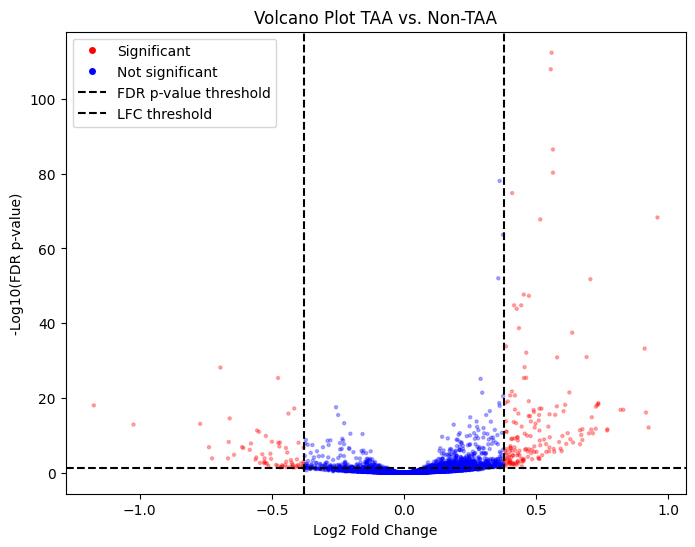

In [462]:
lfc_threshold = math.log2(1.3)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d['color'] = ['red' if abs(lfc) > lfc_threshold and pval_adj < pval_threshold else 'blue' 
                 for lfc, pval_adj in zip(result_1d['de_coef'], result_1d['pval_adj'])]

# Plot volcano plot
plt.figure(figsize=(8, 6))
plt.scatter(result_1d['de_coef'], -np.log10(result_1d['pval_adj']), c=result_1d['color'], alpha=0.3, s=5) # s is the size of the dots

# Highlight significant genes by annotating them
# for i, row in result_1d.iterrows():
#     if abs(row['de_coef']) > lfc_threshold and row['pval_adj'] < pval_threshold:
#         if row['gene'] in result_1d.sort_values('pval_adj', ascending=True).head(15)['gene'].values:
#             plt.text(row['de_coef'], -np.log10(row['pval_adj']), row['gene'], fontsize=8, ha='right', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black')

plt.xlabel('Log2 Fold Change')
plt.ylabel('-Log10(FDR p-value)')
plt.title('Volcano Plot TAA vs. Non-TAA')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, loc='upper left')
plt.show()

In [ ]:
result_1d.sort_values('de_pval', ascending=True).head(15)['gene'].values

array(['CD8A', 'GZMB', 'PRF1', 'LAG3', 'CCL5', 'NKG7', 'VCAM1', 'GZMH',
       'GZMA', 'HLA-DRB1', 'HAVCR2', 'APOBEC3G', 'CD8B', 'CCL4',
       'HLA-DQA1'], dtype=object)

In [413]:
result_1d.sort_values('pval_adj', ascending=True).head(15)['gene'].values

array(['CD8A', 'GZMB', 'PRF1', 'LAG3', 'CCL5', 'NKG7', 'VCAM1', 'GZMH',
       'GZMA', 'HLA-DRB1', 'HAVCR2', 'APOBEC3G', 'CD8B', 'CCL4',
       'HLA-DQA1'], dtype=object)

In [ ]:
result_1d.to_csv("adata_raw_noHC_no_NA_outcome_high_conf_tumor_vs_non_tumor_pred_ref_non_tumor.csv")

In [ ]:
result_1d[result_1d['color'] == "red"].sort_values('de_pval', ascending=True).head(15)['gene'].values

array(['CD8A', 'GZMB', 'PRF1', 'LAG3', 'NKG7', 'VCAM1', 'GZMH', 'HAVCR2',
       'APOBEC3G', 'CD8B', 'CCL4', 'HLA-DQA1', 'CTSW', 'HLA-DRA', 'KLRD1'],
      dtype=object)

In [ ]:
rank_gene = result_1d.sort_values('de_pval', ascending=True)
rank_gene['log_p_val'] = -np.log(rank_gene['de_pval'])
rank_gene

,gene,tx,de_coef,de_se,de_pval,dv_coef,dv_se,dv_pval,color,log_p_val
855,CD8A,tumor_pred_ref_non_tumor,0.558678,0.024280,7.139073e-117,-0.907104,0.740686,0.301723,red,267.436873
4448,GZMB,tumor_pred_ref_non_tumor,0.555507,0.024637,3.826909e-112,0.488202,0.177209,0.004582,red,256.547473
3777,PRF1,tumor_pred_ref_non_tumor,0.563769,0.027894,1.631813e-90,-0.086819,0.307474,0.881138,red,206.742967
3958,LAG3,tumor_pred_ref_non_tumor,0.563815,0.028978,3.399747e-84,0.520045,0.142769,0.000191,red,192.193447
5244,CCL5,tumor_pred_ref_non_tumor,0.361961,0.018851,7.029811e-82,-0.645904,0.839087,0.530364,blue,186.861818
...,...,...,...,...,...,...,...,...,...,...
1429,EIF5A2,tumor_pred_ref_non_tumor,-0.006490,0.129346,9.985906e-01,-0.076462,0.134109,0.595598,blue,0.001410
1405,SELENOT,tumor_pred_ref_non_tumor,0.000390,0.036327,9.988309e-01,0.064953,0.202465,0.665621,blue,0.001170
5620,PDRG1,tumor_pred_ref_non_tumor,-0.006846,0.109747,9.994893e-01,0.193104,0.123752,0.092382,blue,0.000511
5292,BECN1,tumor_pred_ref_non_tumor,-0.002675,0.059204,9.995347e-01,0.095812,0.126456,0.384235,blue,0.000465


In [ ]:
# pip install gseapy pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import gseapy as gp
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1) Load ranked gene list
# -----------------------------
# Input file should have at least:
# gene, score
# score can be logFC, t-statistic, Wald stat, etc.

# GSEA expects a two-column ranked table
rnk = rank_gene[["gene", "log_p_val"]]

# -----------------------------
# 2) Run preranked GSEA
# -----------------------------
# Choose any gene set collection you want:
# examples: 'KEGG_2021_Human', 'GO_Biological_Process_2023',
# 'Reactome_2022', 'Hallmark_2020'
pre_res = gp.prerank(
    rnk=rnk,
    gene_sets="Reactome_2022",
    permutation_num=1000,
    seed=42,
    min_size=10,
    max_size=500,
    outdir=None,
    verbose=True
)


# Results table
res = pre_res.res2d.copy()
res = res.reset_index().rename(columns={"index": "Term"})

# Save results
res.to_csv("gsea_results.csv", index=False)

# -----------------------------
# 3) Dotplot of pathways
# -----------------------------
# Pick top pathways by FDR
plot_df = res.copy()
plot_df["FDR q-val"] = pd.to_numeric(plot_df["FDR q-val"], errors="coerce")
plot_df["NES"] = pd.to_numeric(plot_df["NES"], errors="coerce")

# Keep significant pathways
plot_df = plot_df.sort_values("FDR q-val", ascending=True)



2026-04-29 16:09:02,256 [INFO] Parsing data files for GSEA.............................
2026-04-29 16:09:02,259 [INFO] Enrichr library gene sets already downloaded in: /Users/phle/.cache/gseapy, use local file
2026-04-29 16:09:02,281 [INFO] 0930 gene_sets have been filtered out when max_size=500 and min_size=10
2026-04-29 16:09:02,281 [INFO] 0888 gene_sets used for further statistical testing.....
2026-04-29 16:09:02,281 [INFO] Start to run GSEA...Might take a while..................
2026-04-29 16:09:05,630 [INFO] Congratulations. GSEApy runs successfully................



In [ ]:
plot_df

,Term,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
1,1,prerank,Class A/1 (Rhodopsin-like Receptors) R-HSA-373076,0.891867,1.671407,0.0,0.164979,0.197,15/30,5.83%,CCL5;CCL4;F2R;CD200R1;CCL3;GPR183;GPR65;CCR6;C...
5,5,prerank,GPCR Ligand Binding R-HSA-500792,0.872577,1.641008,0.0,0.167486,0.454,16/40,5.83%,CCL5;CCL4;F2R;CD200R1;CCL3;GPR183;GPR65;CCR6;C...
4,4,prerank,Immunoregulatory Interactions Between A Lympho...,0.898972,1.646299,0.0,0.172701,0.411,15/32,3.59%,CD8A;VCAM1;CD8B;KLRD1;CRTAM;CD200R1;KIR2DL4;SL...
3,3,prerank,Peptide Ligand-Binding Receptors R-HSA-375276,0.901251,1.650877,0.001002,0.183031,0.366,9/18,3.78%,CCL5;CCL4;F2R;CD200R1;CCL3;CCR6;CCR5;CXCR3;CXCR6
6,6,prerank,Chemokine Receptors Bind Chemokines R-HSA-380108,0.912645,1.632871,0.005123,0.186255,0.526,8/12,5.72%,CCL5;CCL4;CCL3;CCR6;CCR5;CXCR3;CXCR6;CCR7
...,...,...,...,...,...,...,...,...,...,...,...
354,354,prerank,Transcriptional Regulation By RUNX1 R-HSA-8878171,0.513771,0.967881,0.593,1.000000,1.0,30/106,24.42%,IFNG;CCND2;IL2RA;FOXP3;MNAT1;PSMB10;RUNX2;SOCS...
355,355,prerank,HSF1 Activation R-HSA-3371511,0.536875,0.967767,0.544355,1.000000,1.0,4/14,19.07%,DNAJB1;HSF1;POLR1A;HSPA1A
356,356,prerank,Membrane Trafficking R-HSA-199991,0.503171,0.967039,0.663,1.000000,1.0,118/350,30.35%,IL7R;RAB27A;GOLIM4;CD4;GALNT2;GGA2;RIN3;M6PR;S...
346,346,prerank,Regulation Of NF-kappa B Signaling R-HSA-9758274,0.550377,0.972304,0.530612,1.000000,1.0,11/11,45.06%,N4BP1;TANK;USP14;IKBIP;CASP8;NLRC5;TRAF6;IKBKB...


# Compare Pre vs. Post for predicted TAA for responders

In [ ]:
adata_raw_noHC_no_NA_outcome_high_conf_CR = adata_raw_noHC_no_NA_outcome_high_conf[adata_raw_noHC_no_NA_outcome_high_conf.obs['outcome'] == "CR"]
adata_raw_noHC_no_NA_outcome_high_conf_CR

View of AnnData object with n_obs × n_vars = 2767 × 15827
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'predicted_binding_probability', 'peptide_cat', 'tumor_pred_ref_non_tumor'
    obsm: 'X_umap'
    layers: 'counts'

In [ ]:
adata_raw_noHC_no_NA_outcome_high_conf_CR.obs['timepoint'].value_counts()

timepoint
pre_CD40     1957
post_CD40     720
follow_up      62
surgery        28
Name: count, dtype: int64

In [ ]:
adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post = adata_raw_noHC_no_NA_outcome_high_conf_CR[adata_raw_noHC_no_NA_outcome_high_conf_CR.obs['timepoint'].str.contains("pre|post")]
adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post

View of AnnData object with n_obs × n_vars = 2677 × 15827
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'predicted_binding_probability', 'peptide_cat', 'tumor_pred_ref_non_tumor'
    obsm: 'X_umap'
    layers: 'counts'

In [ ]:
adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post.obs['timepoint_ref_pre'] = (adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post.obs['timepoint'] != "pre_CD40") + 0

/var/folders/xy/jbfzznj17w73w_rdfj3xs11h0000gn/T/ipykernel_81439/1478889375.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post.obs['timepoint_ref_pre'] = (adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post.obs['timepoint'] != "pre_CD40") + 0


In [ ]:
# adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post.write("adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post.h5ad")

In [33]:
adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post = sc.read_h5ad("adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post.h5ad")

In [ ]:
result_1d_pre_post_TAA = memento.binary_test_1d(
    adata=adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post, 
    capture_rate=0.03, 
    treatment_col='timepoint_ref_pre', 
    num_cpus=6,
    num_boot=5000)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    5.3s
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=6)]: Done 212 tasks      | elapsed:   14.9s
[Parallel(n_jobs=6)]: Done 462 tasks      | elapsed:   31.0s
[Parallel(n_jobs=6)]: Done 812 tasks      | elapsed:   52.1s
[Parallel(n_jobs=6)]: Done 1262 tasks      | elapsed:  1.3min
[Parallel(n_jobs=6)]: Done 1812 tasks      | elapsed:  1.9min
[Parallel(n_jobs=6)]: Done 2462 tasks      | elapsed:  2.5min
[Parallel(n_jobs=6)]: Done 3212 tasks      | elapsed:  3.3min
[Parallel(n_jobs=6)]: Done 4062 tasks      | elapsed:  4.2min
[Parallel(n_jobs=6)]: Done 5012 tasks      | elapsed:  5.2min
[Parallel(n_job

In [403]:
result_1d_pre_post_TAA["pval_adj"] = multipletests(result_1d_pre_post_TAA["de_pval"], method="fdr_bh")[1]

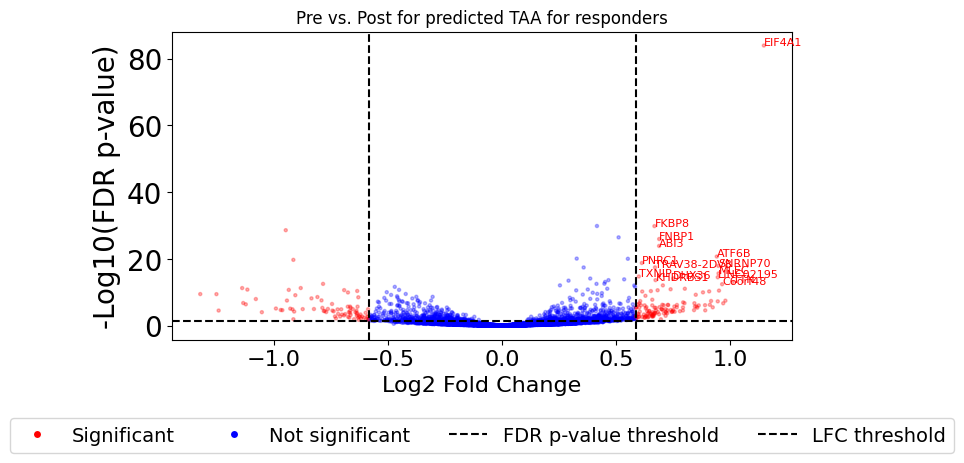

In [579]:
lfc_threshold = math.log2(1.5)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d_pre_post_TAA['color'] = ['red' if abs(lfc) > lfc_threshold and pval < pval_threshold else 'blue' 
                 for lfc, pval in zip(result_1d_pre_post_TAA['de_coef'], result_1d_pre_post_TAA['pval_adj'])]

# Plot volcano plot
plt.figure(figsize=(8, 4))
plt.scatter(result_1d_pre_post_TAA['de_coef'], -np.log10(result_1d_pre_post_TAA['pval_adj']), c=result_1d_pre_post_TAA['color'], alpha=0.3, s=5) # s is the size of the dots

# Highlight significant genes by annotating them
for i, row in result_1d_pre_post_TAA.iterrows():
    if abs(row['de_coef']) > lfc_threshold and row['pval_adj'] < pval_threshold:
        if row['gene'] in result_1d_pre_post_TAA[(result_1d_pre_post_TAA['color'] == "red") & (result_1d_pre_post_TAA['de_coef'] > 0)].sort_values('pval_adj', ascending=True).head(15)['gene'].values:
            plt.text(row['de_coef'], -np.log10(row['pval_adj']), row['gene'], fontsize=8, ha='left', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black')

plt.xlabel('Log2 Fold Change', fontsize = 16)
plt.ylabel('-Log10(FDR p-value)', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 20)
plt.title('Pre vs. Post for predicted TAA for responders')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, bbox_to_anchor = (0.5,-0.4) ,loc='lower center',ncol=4, fontsize=14)
plt.show()

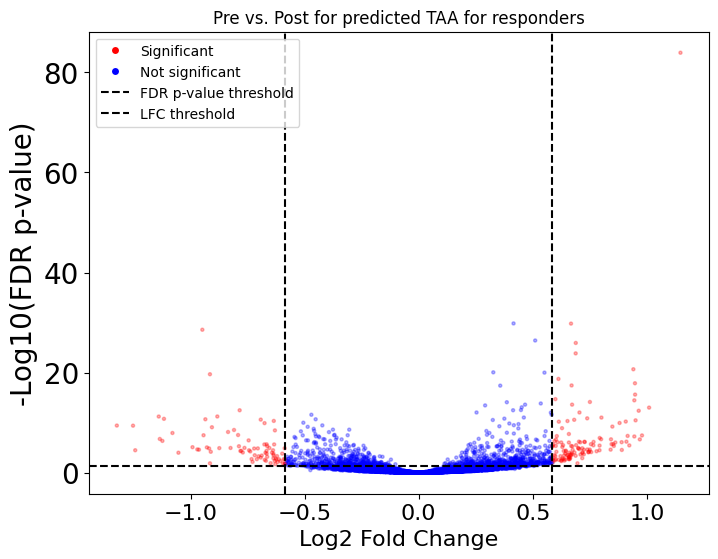

In [484]:
lfc_threshold = math.log2(1.5)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d_pre_post_TAA['color'] = ['red' if abs(lfc) > lfc_threshold and pval < pval_threshold else 'blue' 
                 for lfc, pval in zip(result_1d_pre_post_TAA['de_coef'], result_1d_pre_post_TAA['pval_adj'])]

# Plot volcano plot
plt.figure(figsize=(8, 6))
plt.scatter(result_1d_pre_post_TAA['de_coef'], -np.log10(result_1d_pre_post_TAA['pval_adj']), c=result_1d_pre_post_TAA['color'], alpha=0.3, s=5) # s is the size of the dots

# Highlight significant genes by annotating them
# for i, row in result_1d_pre_post_TAA.iterrows():
#     if abs(row['de_coef']) > lfc_threshold and row['pval_adj'] < pval_threshold:
#         if row['gene'] in result_1d_pre_post_TAA[(result_1d_pre_post_TAA['color'] == "red") & (result_1d_pre_post_TAA['de_coef'] > 0)].sort_values('pval_adj', ascending=True).head(15)['gene'].values:
#             plt.text(row['de_coef'], -np.log10(row['pval_adj']), row['gene'], fontsize=8, ha='right', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black')

plt.xlabel('Log2 Fold Change', fontsize = 16)
plt.ylabel('-Log10(FDR p-value)', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 20)
plt.title('Pre vs. Post for predicted TAA for responders')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, loc='upper left')
plt.show()

In [ ]:
result_1d_pre_post_TAA.to_csv("adata_raw_noHC_no_NA_outcome_high_conf_result_1d_pre_post_ref_TAA_CR.csv")

In [ ]:
result_1d_pre_post_TAA[result_1d_pre_post_TAA['color'] == "red"].sort_values('de_pval', ascending=True).head(20)['gene'].values

array(['EIF4A1', 'AL157402.2', 'FKBP8', 'RAC1', 'TRIR', 'FNBP1', 'ABI3',
       'ATF6B', 'APOBEC3C', 'ZYX', 'PNRC1', 'SNRNP70', 'TRAV38-2DV8',
       'MLEC', 'TXNIP', 'LINC02195', 'DHX36', 'SRSF5', 'CCNL1', 'STK17A'],
      dtype=object)

In [411]:
result_1d_pre_post_TAA[result_1d_pre_post_TAA['color'] == "red"].sort_values('pval_adj', ascending=True).head(20)['gene'].values

array(['EIF4A1', 'FKBP8', 'RAC1', 'FNBP1', 'ABI3', 'ATF6B', 'ZYX',
       'PNRC1', 'SNRNP70', 'TRAV38-2DV8', 'MLEC', 'TXNIP', 'LINC02195',
       'DHX36', 'KHDRBS1', 'TTN', 'NMT1', 'C6orf48', 'TMC8', 'C19orf24'],
      dtype=object)

In [ ]:
rank_gene = result_1d_pre_post_TAA.sort_values('de_pval', ascending=True)
rank_gene['log_p_val'] = -np.log(rank_gene['de_pval'])
# pip install gseapy pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import gseapy as gp
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1) Load ranked gene list
# -----------------------------
# Input file should have at least:
# gene, score
# score can be logFC, t-statistic, Wald stat, etc.

# GSEA expects a two-column ranked table
rnk = rank_gene[["gene", "log_p_val"]]

# -----------------------------
# 2) Run preranked GSEA
# -----------------------------
# Choose any gene set collection you want:
# examples: 'KEGG_2021_Human', 'GO_Biological_Process_2023',
# 'Reactome_2022', 'Hallmark_2020'
pre_res = gp.prerank(
    rnk=rnk,
    gene_sets="Reactome_2022",
    permutation_num=1000,
    seed=42,
    min_size=10,
    max_size=500,
    outdir=None,
    verbose=True
)


# Results table
res = pre_res.res2d.copy()
res = res.reset_index().rename(columns={"index": "Term"})

# Save results
res.to_csv("gsea_results.csv", index=False)

# -----------------------------
# 3) Dotplot of pathways
# -----------------------------
# Pick top pathways by FDR
plot_df = res.copy()
plot_df["FDR q-val"] = pd.to_numeric(plot_df["FDR q-val"], errors="coerce")
plot_df["NES"] = pd.to_numeric(plot_df["NES"], errors="coerce")

# Keep significant pathways
plot_df = plot_df.sort_values("FDR q-val", ascending=True)

plot_df

2026-04-29 17:23:16,381 [INFO] Parsing data files for GSEA.............................
2026-04-29 17:23:16,386 [INFO] Enrichr library gene sets already downloaded in: /Users/phle/.cache/gseapy, use local file


2026-04-29 17:23:16,414 [INFO] 0960 gene_sets have been filtered out when max_size=500 and min_size=10
2026-04-29 17:23:16,414 [INFO] 0858 gene_sets used for further statistical testing.....
2026-04-29 17:23:16,414 [INFO] Start to run GSEA...Might take a while..................
2026-04-29 17:23:19,582 [INFO] Congratulations. GSEApy runs successfully................



,Term,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
3,3,prerank,GTP Hydrolysis And Joining Of 60S Ribosomal Su...,0.823787,1.583346,0.001,0.264764,0.46,7/25,4.70%,EIF4A1;EIF3D;EIF3J;EIF4A2;EIF3A;EIF3L;EIF4G1
4,4,prerank,mRNA Activation Upon Binding Of Cap-Binding Co...,0.819321,1.565488,0.002008,0.282481,0.55,7/22,4.70%,EIF4A1;EIF3D;EIF3J;EIF4A2;EIF3A;EIF3L;EIF4G1
2,2,prerank,Translation Initiation Complex Formation R-HSA...,0.836695,1.594713,0.001003,0.287139,0.402,7/21,4.70%,EIF4A1;EIF3D;EIF3J;EIF4A2;EIF3A;EIF3L;EIF4G1
5,5,prerank,Cap-dependent Translation Initiation R-HSA-72737,0.796576,1.550380,0.0,0.301446,0.629,8/31,5.24%,EIF4A1;EIF3D;EIF3J;EIF4A2;EIF3A;EIF3L;EIF4G1;E...
7,7,prerank,Interferon Alpha/Beta Signaling R-HSA-909733,0.77713,1.528669,0.0,0.310929,0.725,20/40,11.61%,IFI6;IRF7;JAK1;MX1;OASL;SOCS3;IRF9;KPNB1;SOCS1...
...,...,...,...,...,...,...,...,...,...,...,...
596,596,prerank,Telomere Extension By Telomerase R-HSA-171319,0.492689,0.914028,0.645519,1.000000,1.0,3/16,20.33%,TERF2IP;PPP6C;GAR1
595,595,prerank,Switching Of Origins To A Post-Replicative Sta...,0.458111,0.914091,0.755,1.000000,1.0,14/62,17.75%,PSMB7;MCM7;PSMB6;ANAPC5;PSMB2;PSMD8;UBE2D1;PSM...
594,594,prerank,Intraflagellar Transport R-HSA-5620924,0.498545,0.915057,0.647844,1.000000,1.0,7/11,38.82%,DYNLRB1;HSPB11;TRIP11;KIFAP3;IFT43;IFT27;IFT52
472,472,prerank,G Alpha (12/13) Signaling Events R-HSA-416482,0.506639,0.968558,0.57014,1.000000,1.0,11/22,34.56%,GNB2;RHOB;GNG2;TIAM1;ARHGEF1;GNG10;ARHGEF3;ARH...


In [35]:
cytotoxic_genes = [
    "PRF1",   # perforin
    "GZMB", "GZMA", "GZMH",  # granzymes
    "GNLY",   # granulysin
    "NKG7"
]
exhaustion_genes = [
    "PDCD1",  # PD-1
    "CTLA4",
    "LAG3",
    "TIGIT",
    "HAVCR2",  # TIM-3
    "TOX"
]
tumor_reactive = [
    "CXCL13", "PDCD1", "TOX", "ICOS", "LAG3"
]
sc.tl.score_genes(adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post, cytotoxic_genes, score_name="cytotoxic")
sc.tl.score_genes(adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post, exhaustion_genes, score_name="exhaustion")
sc.tl.score_genes(adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post, tumor_reactive, score_name="tumor_reactive")
cell_map = {'CD4T_naive2':'CD4T_naive',
 'CD4T_naive1':'CD4T_naive',
 'CD8_GrH':'CD8T_GrH',
 'CD4T_naive3':'CD4T_naive',
 'Treg':'Treg',
 'CD8T_prolif':'CD8T_prolif',
 'CD8T_GrK':'CD8T_GrK',
 'Treg1':'Treg',
 'CD8T_GrB':'CD8T_GrB',
 'CD4_Tnaive1':'CD4T_naive',
 'CD8T_GrH':'CD8T_GrH',
 'CD4_Tfh-like':'CD4_Tfh-like',
 'Treg2':'Treg',
 'gd_Tcell': 'gd_Tcell',
 'MAIT':'MAIT'}

adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post.obs['final_cell_type'] = adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post.obs['cell_type_scvi'].map(cell_map)

In [544]:
dt_TAA_pre_vs_post_CR

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,...,TRB_cdr3,TRA_cdr3,predicted_binding_probability,peptide_cat,tumor_pred_ref_non_tumor,timepoint_ref_pre,cytotoxic,exhaustion,tumor_reactive,final_cell_type
AAACCTGGTCTAGTGT-1_03_post,0,2184.0,1077,CR,03,pathCR,03_post,post_CD40,7.688913,0.000000,...,CASSLGSYEQYF,CAPHGDDKIIF,0.942014,Viral,0,1,2.955347,0.170538,-0.753533,CD8T_GrH
AAACGGGAGGGAAACA-1_03_pre,0,2962.0,1245,CR,03,pathCR,03_pre,pre_CD40,7.993620,0.000000,...,CSARDRTSGLAKNIQYF,CAPPSGSNYQLIW,0.988889,Viral,0,0,1.324785,0.029455,-0.164910,CD8T_GrK
AAACGGGCATGTTCCC-1_03_pre,0,3098.0,1403,CR,03,pathCR,03_pre,pre_CD40,8.038512,0.000000,...,CASSLGSYEQYF,CAPHGDDKIIF,0.952067,Viral,0,0,0.786480,0.411188,0.073009,CD8T_GrB
AAACGGGGTACCGAGA-1-2,2,2106.0,905,CR,03,pathCR,03_pre,pre_CD40,7.652546,0.073599,...,CASSPPGSFGYGYTF,CAVTWGSSNTGKLIF,0.901661,Viral,0,0,-0.502534,-0.554215,-0.554215,CD4T_naive
AAACGGGTCAAACCGT-1_03_pre,0,2727.0,1321,CR,03,pathCR,03_pre,pre_CD40,7.910957,0.000000,...,CASSLGSYEQYF,CAPHGDDKIIF,0.917718,Viral,0,0,2.717321,0.781738,0.371842,CD8T_GrH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTGTTAAGATG-1_03_pre,0,2511.0,1219,CR,03,pathCR,03_pre,pre_CD40,7.828436,0.000000,...,CSVGLFGNTIYF,CAANANAGGTSYGKLTF,0.971876,Viral,0,0,0.590724,-0.855482,-0.855482,CD8T_GrH
TTTGTCAAGCGTTCCG-1_03_pre,0,6792.0,2296,CR,03,pathCR,03_pre,pre_CD40,8.823501,0.000000,...,CASSVEAGTSGYEQYF,CAVASGGYQKVTF,0.940872,Viral,0,0,-1.713231,0.014857,0.014673,Treg
TTTGTCACACGGTAAG-1-2,2,1440.0,771,CR,03,pathCR,03_pre,pre_CD40,7.272398,0.073611,...,CASRGDSTALEQYF,CAFTSPAGGTSYGKLTF,0.990512,Viral,0,0,-0.621017,-0.514356,-0.514356,CD4T_naive
TTTGTCACACTGTCGG-1_03_pre,0,2952.0,1406,CR,03,pathCR,03_pre,pre_CD40,7.990238,0.000000,...,CASSLGPSTDTQYF,CALSEGIGSGNTGKLIF,0.924772,Viral,0,0,-1.231336,0.752151,0.380339,Treg


In [547]:
dt_TAA_pre_vs_post_CR['timepoint'].value_counts()

timepoint
pre_CD40     1957
post_CD40     720
Name: count, dtype: int64

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

pre_CD40 vs. post_CD40: t-test independent samples, P_val:9.954e-03 t=-2.579e+00


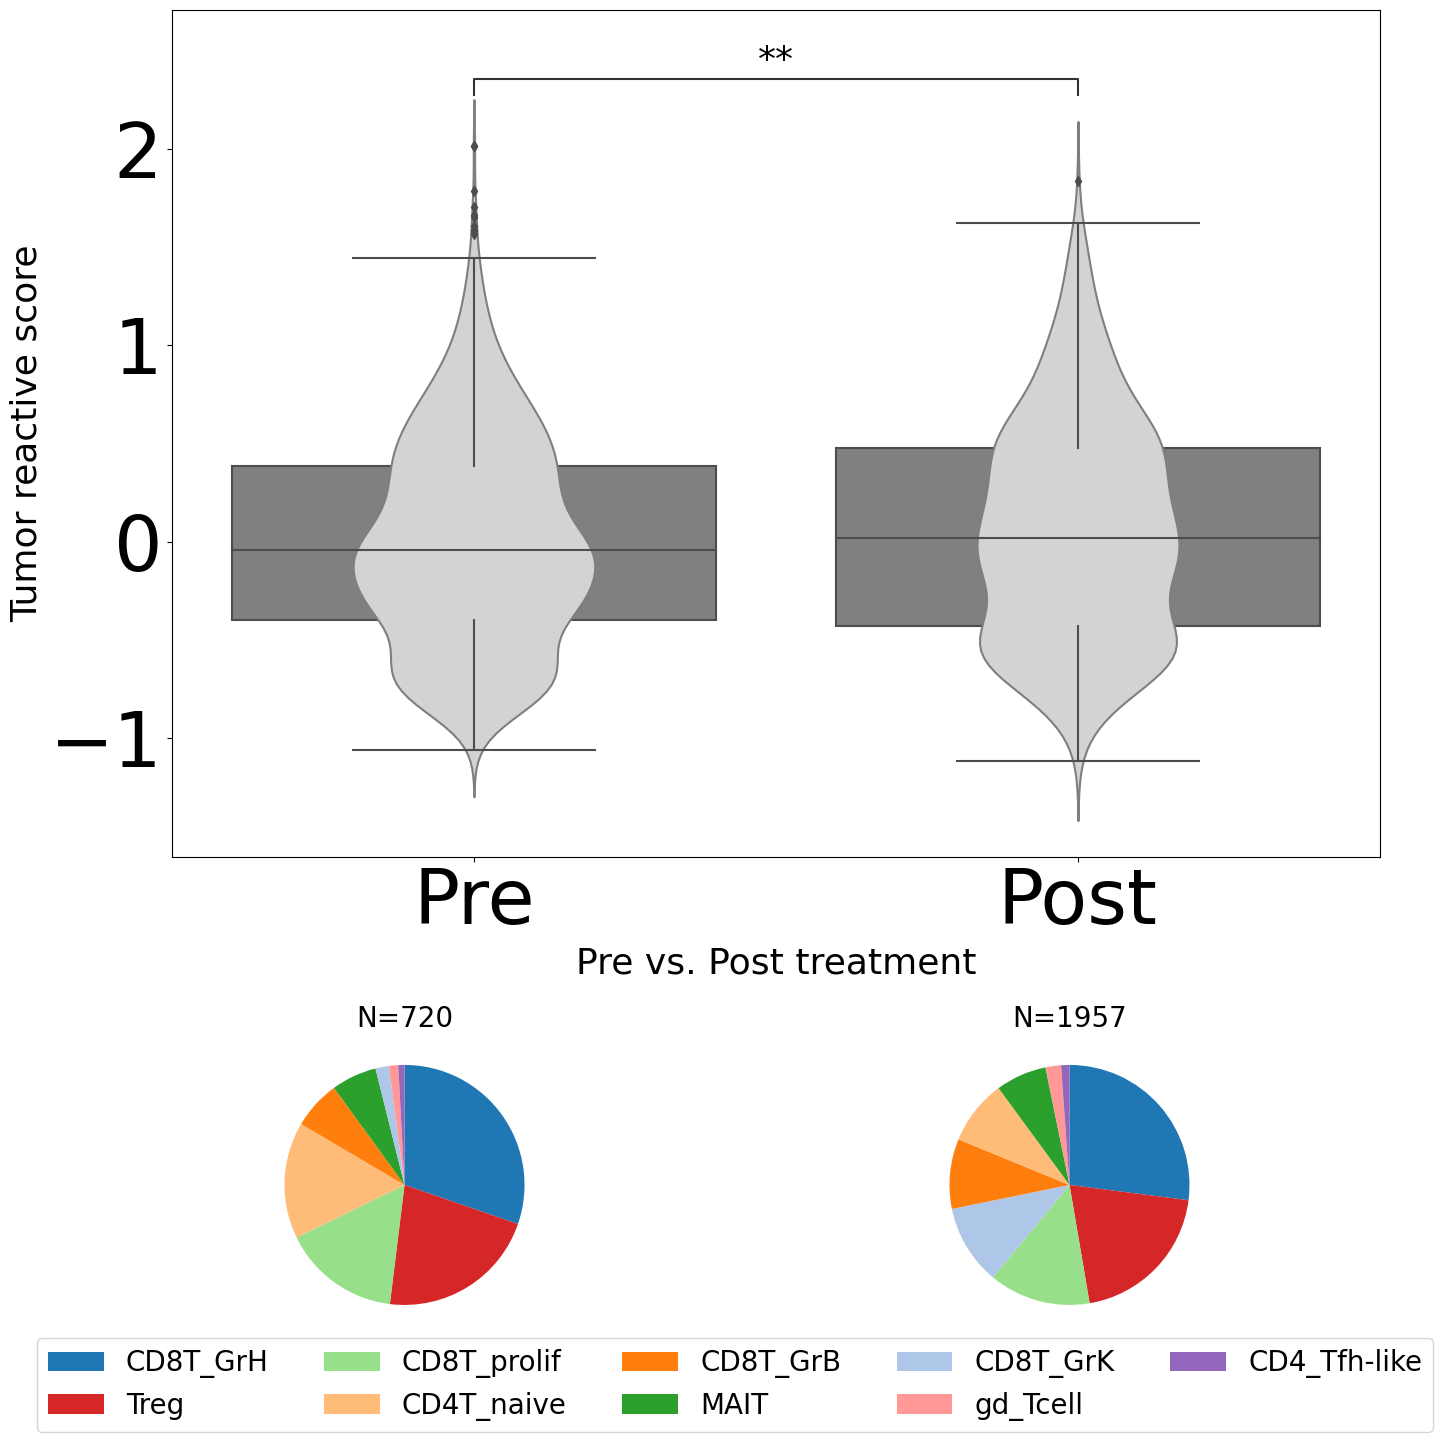

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

ordered_groups = [ "pre_CD40","post_CD40" ]
adata_raw_noHC_no_NA_outcome_predicted_TAA_pre_vs_post_CR = adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post
dt_TAA_pre_vs_post_CR = adata_raw_noHC_no_NA_outcome_predicted_TAA_pre_vs_post_CR.obs.copy()

present_groups = [
    g for g in ordered_groups
    if g in dt_TAA_pre_vs_post_CR["timepoint"].unique()
]

# build pairs automatically from the present leiden groups
leiden_groups = sorted(dt_TAA_pre_vs_post_CR["timepoint"].astype(str).unique(), reverse=True)
pair_compaire = [
    ("pre_CD40","post_CD40")
]
# pair_compaire = leiden_groups

palette = {g: "red" if "pos" in g else "grey" for g in present_groups}


fig, ax_box = plt.subplots(figsize=(14, 10))

sns.boxplot(
    data=dt_TAA_pre_vs_post_CR,
    x="timepoint",
    y="tumor_reactive",
    order=present_groups,
    # palette=palette,
    color = "grey",
    ax=ax_box
)

sns.violinplot(
    data=dt_TAA_pre_vs_post_CR,
    x="timepoint",
    y="tumor_reactive",
    width=0.4,
    inner=None,
    order=present_groups,
    color="lightgray",
    alpha=0.8,
    ax=ax_box
)

annotator = Annotator(
    ax_box,
    data=dt_TAA_pre_vs_post_CR,
    x="timepoint",
    y="tumor_reactive",
    order=present_groups,
    pairs=pair_compaire
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", fontsize=26, hide_non_significant=True)
annotator.apply_and_annotate()

# ax_box.set_title("Score Comparison Pre vs. Post treatment", fontsize=26)
ax_box.tick_params(axis="x",  labelsize=55)
ax_box.tick_params(axis="y",  labelsize=55)
ax_box.set_xlabel("Pre vs. Post treatment", fontsize=26)
ax_box.set_ylabel("Tumor reactive score", fontsize=26)
label_map = {
    "pre_CD40": "Pre",
    "post_CD40": "Post"
}

ax_box.set_xticklabels([label_map[g] for g in present_groups])
# Get axis position in figure coordinates
ax_pos = ax_box.get_position()

# Get x positions of categories
all_cell_types = dt_TAA_pre_vs_post_CR["final_cell_type"].unique()
palette = sns.color_palette("tab20", len(all_cell_types))
color_map = dict(zip(all_cell_types, palette))
xticks = ax_box.get_xticks()

all_labels = None
all_handles = None
groups = dt_TAA_pre_vs_post_CR["timepoint"].unique()
for i, (x, grp) in enumerate(zip(xticks, groups)):
    sub = dt_TAA_pre_vs_post_CR[dt_TAA_pre_vs_post_CR["timepoint"] == grp]
    counts = sub["final_cell_type"].value_counts()
    colors = [color_map[c] for c in counts.index]
    x_fig = ax_pos.x0 -0.22 + (x - ax_box.get_xlim()[0]) / (ax_box.get_xlim()[1] - ax_box.get_xlim()[0]) * 0.95
    y_fig = ax_pos.y0 - 0.45

    ax_pie = fig.add_axes([x_fig, y_fig, 0.3, 0.3])

    wedges, texts= ax_pie.pie(
        counts.values,
        labels=None,          # no labels on the pies
        autopct=None,
        startangle=90,
        colors=colors,
        counterclock=False,
    )

    ax_pie.set_aspect("equal")
    total = counts.sum()
    ax_pie.set_title(f"N={total}", fontsize=20)
    # save legend items only once
    if all_labels is None:
        all_labels = counts.index.tolist()
        all_handles = wedges
fig.legend(
    all_handles,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.02, y_fig - 0.05),
    # title="Cell type",
    fontsize=20,
    ncol=5
)


plt.tight_layout()
plt.show()


df = dt_TAA_pre_vs_post_CR

groups = df["timepoint"].dropna().unique()
pairs = list(itertools.combinations(groups, 2))

results = []

for g1, g2 in pairs:
    x1 = df.loc[df["timepoint"] == g1, "tumor_reactive"].dropna()
    x2 = df.loc[df["timepoint"] == g2, "tumor_reactive"].dropna()

    stat, pval = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test

    results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x1),
        "n2": len(x2),
        "mean1": x1.mean(),
        "mean2": x2.mean(),
        "statistic": stat,
        "pvalue": pval,
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
results_df["p_adj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

# results_df.to_csv("tumor_reactive pre vs post CR within predicted TAA.csv")

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

pre_CD40 vs. post_CD40: t-test independent samples, P_val:1.484e-02 t=-2.438e+00


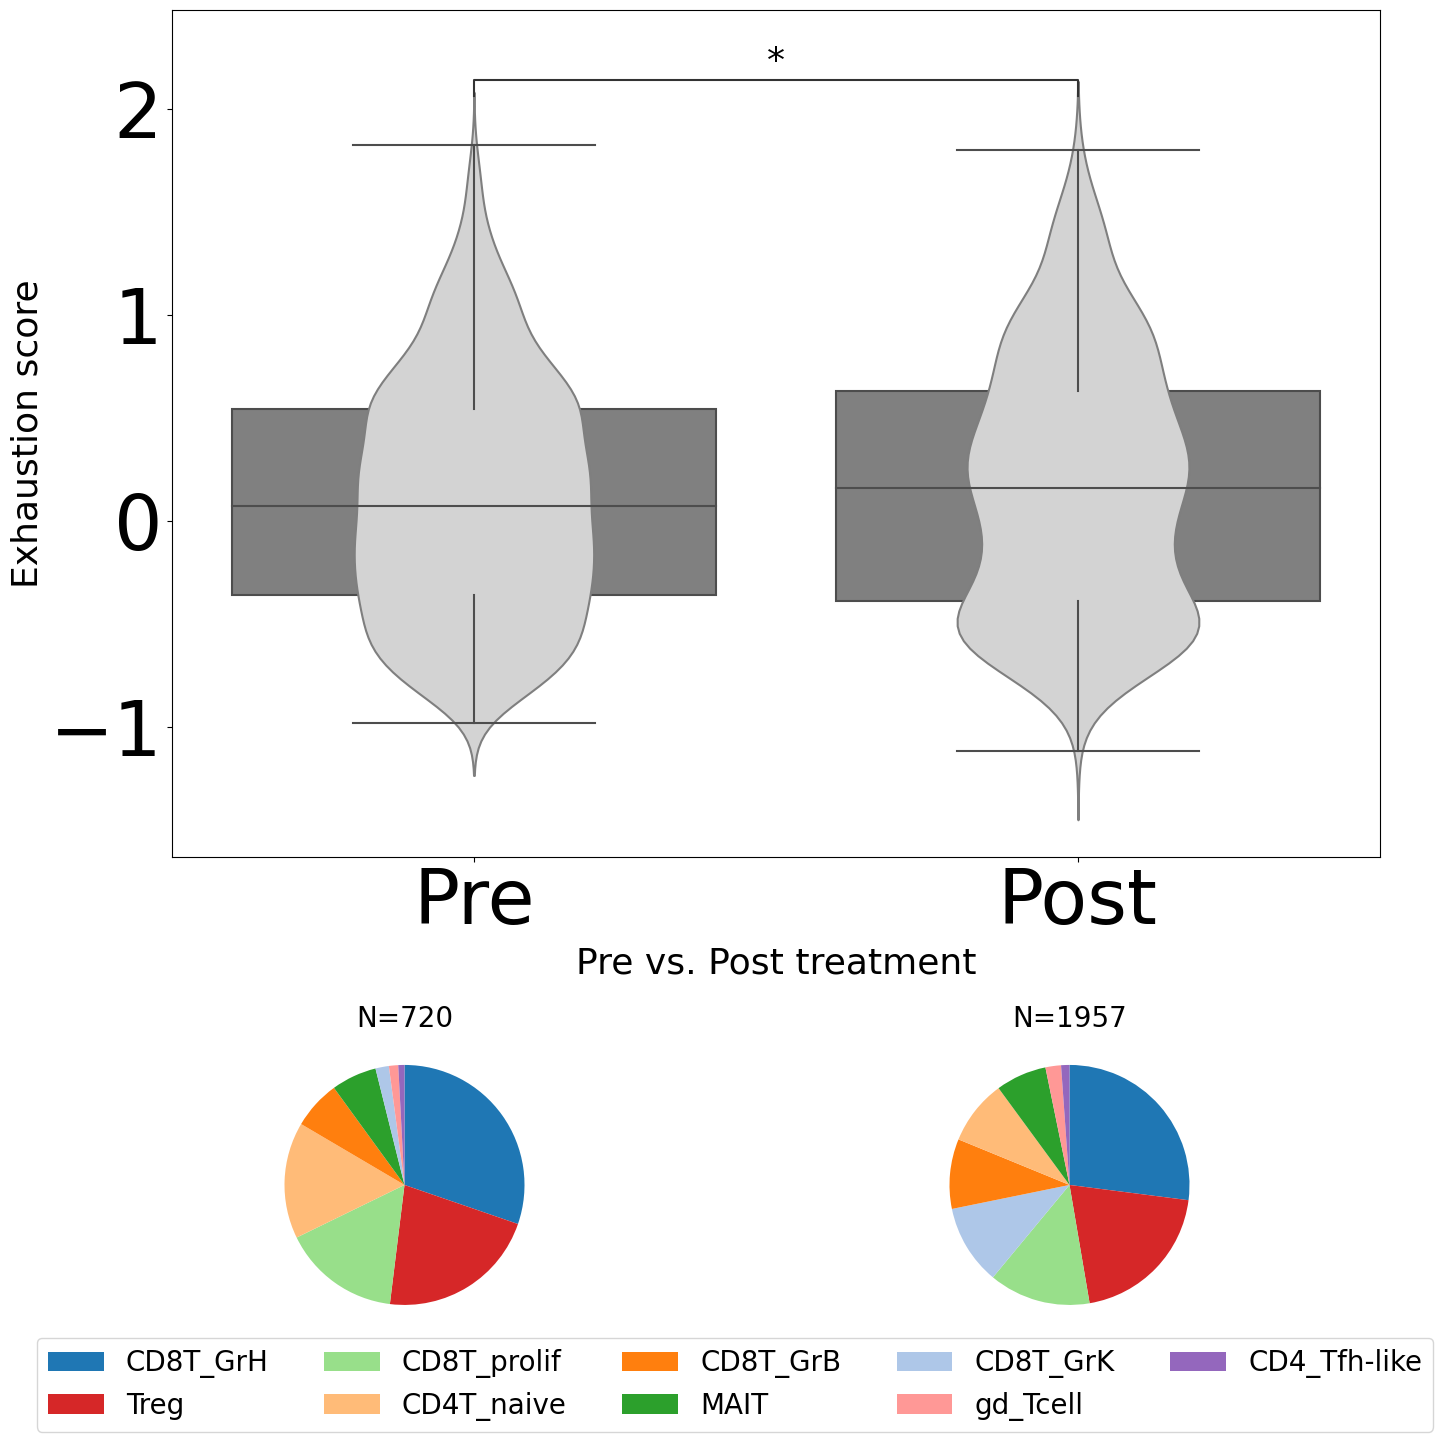

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

ordered_groups = [ "pre_CD40","post_CD40" ]
adata_raw_noHC_no_NA_outcome_predicted_TAA_pre_vs_post_CR = adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post
dt_TAA_pre_vs_post_CR = adata_raw_noHC_no_NA_outcome_predicted_TAA_pre_vs_post_CR.obs.copy()

present_groups = [
    g for g in ordered_groups
    if g in dt_TAA_pre_vs_post_CR["timepoint"].unique()
]

# build pairs automatically from the present leiden groups
leiden_groups = sorted(dt_TAA_pre_vs_post_CR["timepoint"].astype(str).unique(), reverse=True)
pair_compaire = [
    ("pre_CD40","post_CD40")
]
# pair_compaire = leiden_groups

palette = {g: "red" if "pos" in g else "grey" for g in present_groups}


fig, ax_box = plt.subplots(figsize=(14, 10))

sns.boxplot(
    data=dt_TAA_pre_vs_post_CR,
    x="timepoint",
    y="exhaustion",
    order=present_groups,
    # palette=palette,
    color="grey",
    ax=ax_box
)

sns.violinplot(
    data=dt_TAA_pre_vs_post_CR,
    x="timepoint",
    y="exhaustion",
    width=0.4,
    inner=None,
    order=present_groups,
    color="lightgray",
    alpha=0.8,
    ax=ax_box
)

annotator = Annotator(
    ax_box,
    data=dt_TAA_pre_vs_post_CR,
    x="timepoint",
    y="exhaustion",
    order=present_groups,
    pairs=pair_compaire
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", fontsize=26, hide_non_significant=True)
annotator.apply_and_annotate()

# ax_box.set_title("Score Comparison Pre vs. Post treatment", fontsize=26)
ax_box.tick_params(axis="x",  labelsize=55)
ax_box.tick_params(axis="y",  labelsize=55)
ax_box.set_xlabel("Pre vs. Post treatment", fontsize=26)
ax_box.set_ylabel("Exhaustion score", fontsize=26)
label_map = {
    "pre_CD40": "Pre",
    "post_CD40": "Post"
}

ax_box.set_xticklabels([label_map[g] for g in present_groups])
# Get axis position in figure coordinates
ax_pos = ax_box.get_position()

# Get x positions of categories
all_cell_types = dt_TAA_pre_vs_post_CR["final_cell_type"].unique()
palette = sns.color_palette("tab20", len(all_cell_types))
color_map = dict(zip(all_cell_types, palette))
xticks = ax_box.get_xticks()

all_labels = None
all_handles = None
groups = dt_TAA_pre_vs_post_CR["timepoint"].unique()
for i, (x, grp) in enumerate(zip(xticks, groups)):
    sub = dt_TAA_pre_vs_post_CR[dt_TAA_pre_vs_post_CR["timepoint"] == grp]
    counts = sub["final_cell_type"].value_counts()
    colors = [color_map[c] for c in counts.index]
    x_fig = ax_pos.x0 -0.22 + (x - ax_box.get_xlim()[0]) / (ax_box.get_xlim()[1] - ax_box.get_xlim()[0]) * 0.95
    y_fig = ax_pos.y0 - 0.45

    ax_pie = fig.add_axes([x_fig, y_fig, 0.3, 0.3])

    wedges, texts= ax_pie.pie(
        counts.values,
        labels=None,          # no labels on the pies
        autopct=None,
        startangle=90,
        colors=colors,
        counterclock=False,
    )

    ax_pie.set_aspect("equal")
    total = counts.sum()
    ax_pie.set_title(f"N={total}", fontsize=20)
    # save legend items only once
    if all_labels is None:
        all_labels = counts.index.tolist()
        all_handles = wedges
fig.legend(
    all_handles,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.02, y_fig - 0.05),
    # title="Cell type",
    fontsize=20,
    ncol=5
)


plt.tight_layout()
plt.show()


df = dt_TAA_pre_vs_post_CR

groups = df["timepoint"].dropna().unique()
pairs = list(itertools.combinations(groups, 2))

results = []

for g1, g2 in pairs:
    x1 = df.loc[df["timepoint"] == g1, "exhaustion"].dropna()
    x2 = df.loc[df["timepoint"] == g2, "exhaustion"].dropna()

    stat, pval = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test

    results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x1),
        "n2": len(x2),
        "mean1": x1.mean(),
        "mean2": x2.mean(),
        "statistic": stat,
        "pvalue": pval,
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
results_df["p_adj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

# results_df.to_csv("exhaustion pre vs post CR within predicted TAA.csv")

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



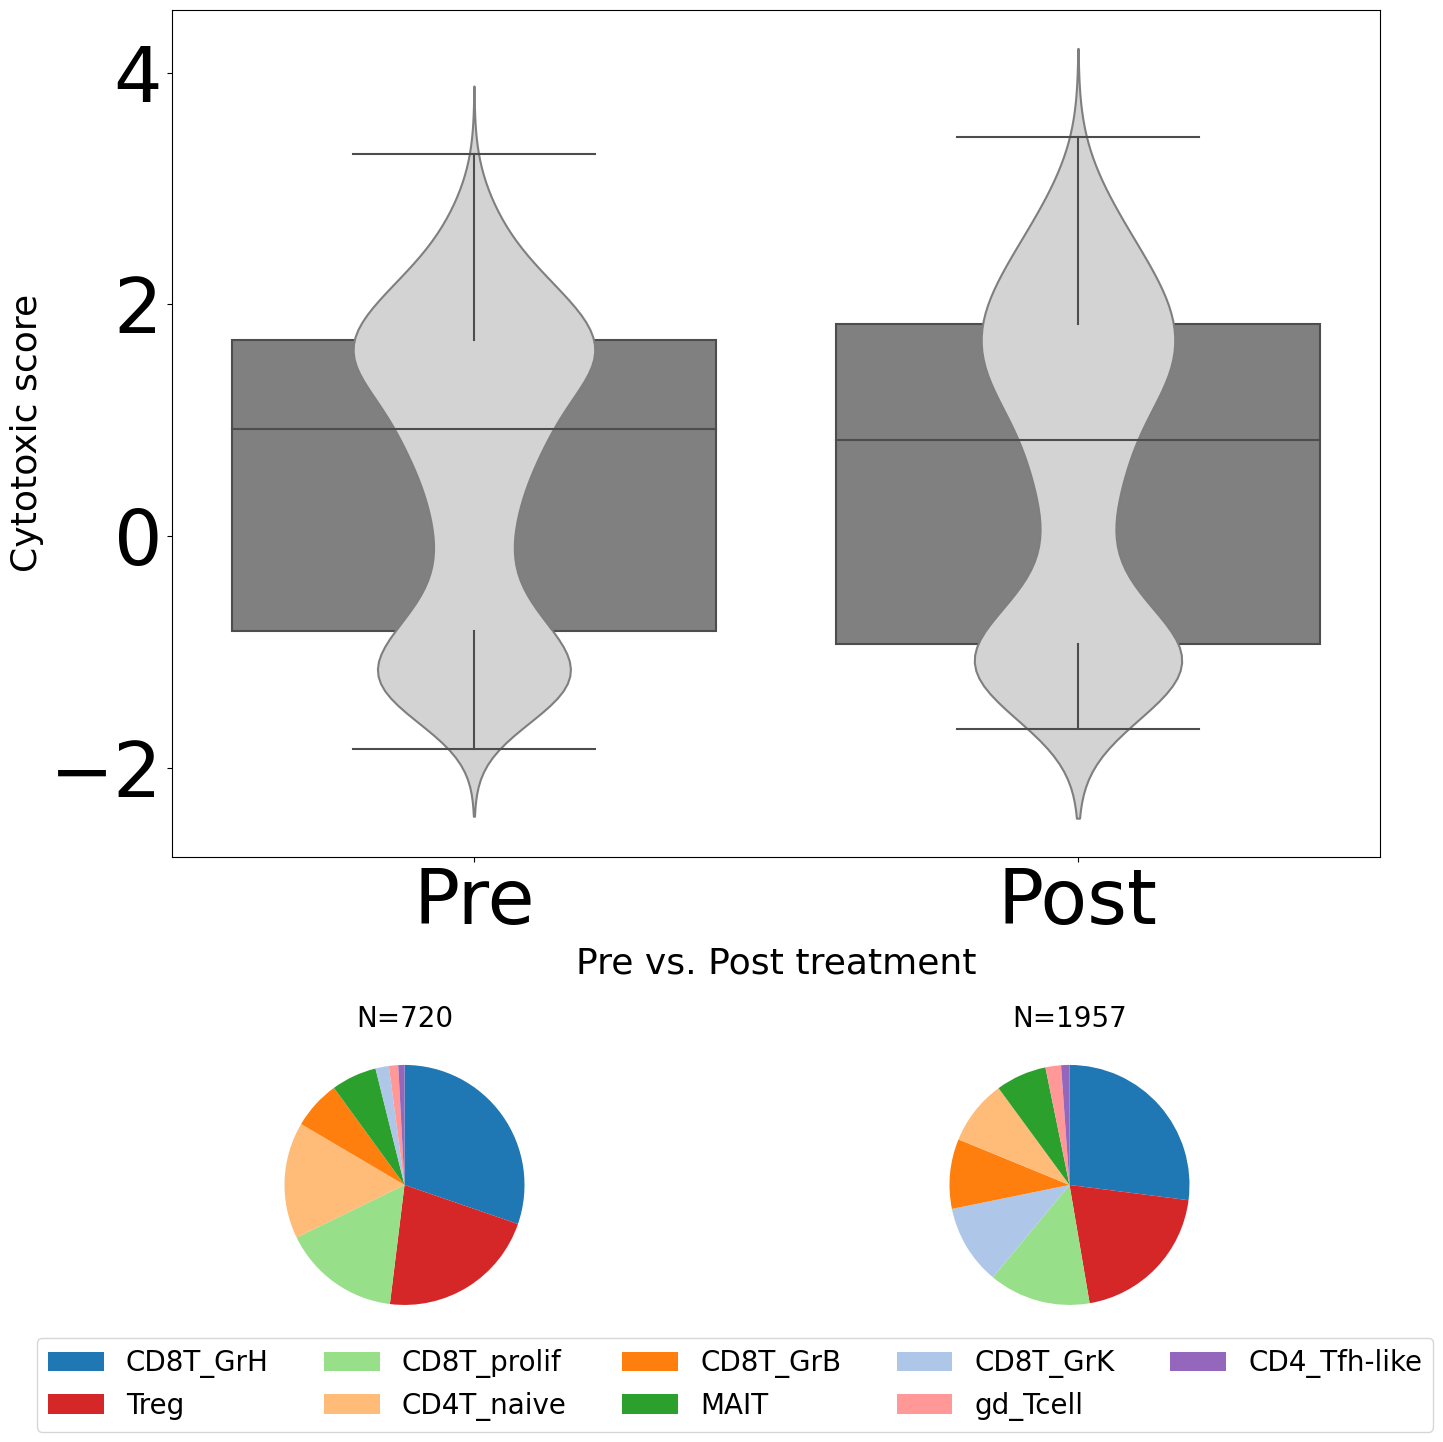

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

ordered_groups = [ "pre_CD40","post_CD40" ]
adata_raw_noHC_no_NA_outcome_predicted_TAA_pre_vs_post_CR = adata_raw_noHC_no_NA_outcome_high_conf_CR_pre_post
dt_TAA_pre_vs_post_CR = adata_raw_noHC_no_NA_outcome_predicted_TAA_pre_vs_post_CR.obs.copy()

present_groups = [
    g for g in ordered_groups
    if g in dt_TAA_pre_vs_post_CR["timepoint"].unique()
]

# build pairs automatically from the present leiden groups
leiden_groups = sorted(dt_TAA_pre_vs_post_CR["timepoint"].astype(str).unique(), reverse=True)
pair_compaire = [
    ("pre_CD40","post_CD40")
]
# pair_compaire = leiden_groups

palette = {g: "red" if "pos" in g else "grey" for g in present_groups}


fig, ax_box = plt.subplots(figsize=(14, 10))

sns.boxplot(
    data=dt_TAA_pre_vs_post_CR,
    x="timepoint",
    y="cytotoxic",
    order=present_groups,
    # palette=palette,
    color = "grey",
    ax=ax_box
)

sns.violinplot(
    data=dt_TAA_pre_vs_post_CR,
    x="timepoint",
    y="cytotoxic",
    width=0.4,
    inner=None,
    order=present_groups,
    color="lightgray",
    alpha=0.8,
    ax=ax_box
)

annotator = Annotator(
    ax_box,
    data=dt_TAA_pre_vs_post_CR,
    x="timepoint",
    y="cytotoxic",
    order=present_groups,
    pairs=pair_compaire
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", fontsize=26, hide_non_significant=True)
annotator.apply_and_annotate()

# ax_box.set_title("Score Comparison Pre vs. Post treatment", fontsize=26)
ax_box.tick_params(axis="x",  labelsize=55)
ax_box.tick_params(axis="y",  labelsize=55)
ax_box.set_xlabel("Pre vs. Post treatment", fontsize=26)
ax_box.set_ylabel("Cytotoxic score", fontsize=26)
label_map = {
    "pre_CD40": "Pre",
    "post_CD40": "Post"
}

ax_box.set_xticklabels([label_map[g] for g in present_groups])
# Get axis position in figure coordinates
ax_pos = ax_box.get_position()

# Get x positions of categories
all_cell_types = dt_TAA_pre_vs_post_CR["final_cell_type"].unique()
palette = sns.color_palette("tab20", len(all_cell_types))
color_map = dict(zip(all_cell_types, palette))
xticks = ax_box.get_xticks()

all_labels = None
all_handles = None
groups = dt_TAA_pre_vs_post_CR["timepoint"].unique()
for i, (x, grp) in enumerate(zip(xticks, groups)):
    sub = dt_TAA_pre_vs_post_CR[dt_TAA_pre_vs_post_CR["timepoint"] == grp]
    counts = sub["final_cell_type"].value_counts()
    colors = [color_map[c] for c in counts.index]
    x_fig = ax_pos.x0 -0.22 + (x - ax_box.get_xlim()[0]) / (ax_box.get_xlim()[1] - ax_box.get_xlim()[0]) * 0.95
    y_fig = ax_pos.y0 - 0.45

    ax_pie = fig.add_axes([x_fig, y_fig, 0.3, 0.3])

    wedges, texts= ax_pie.pie(
        counts.values,
        labels=None,          # no labels on the pies
        autopct=None,
        startangle=90,
        colors=colors,
        counterclock=False,
    )

    ax_pie.set_aspect("equal")
    total = counts.sum()
    ax_pie.set_title(f"N={total}", fontsize=20)
    # save legend items only once
    if all_labels is None:
        all_labels = counts.index.tolist()
        all_handles = wedges
fig.legend(
    all_handles,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.02, y_fig - 0.05),
    # title="Cell type",
    fontsize=20,
    ncol=5
)


plt.tight_layout()
plt.show()


df = dt_TAA_pre_vs_post_CR

groups = df["timepoint"].dropna().unique()
pairs = list(itertools.combinations(groups, 2))

results = []

for g1, g2 in pairs:
    x1 = df.loc[df["timepoint"] == g1, "cytotoxic"].dropna()
    x2 = df.loc[df["timepoint"] == g2, "cytotoxic"].dropna()

    stat, pval = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test

    results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x1),
        "n2": len(x2),
        "mean1": x1.mean(),
        "mean2": x2.mean(),
        "statistic": stat,
        "pvalue": pval,
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
results_df["p_adj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

# results_df.to_csv("cytotoxic pre vs post CR within predicted TAA.csv")

# CR vs PD for predicted TAA

In [ ]:
adata_raw_noHC_no_NA_outcome_high_conf_CR_PD = adata_raw_noHC_no_NA_outcome_high_conf[adata_raw_noHC_no_NA_outcome_high_conf.obs['outcome'].str.contains("CR|PD")]
adata_raw_noHC_no_NA_outcome_high_conf_CR_PD

View of AnnData object with n_obs × n_vars = 6318 × 15827
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'predicted_binding_probability', 'peptide_cat', 'tumor_pred_ref_non_tumor'
    obsm: 'X_umap'
    layers: 'counts'

In [ ]:
adata_raw_noHC_no_NA_outcome_high_conf_CR_PD.obs['outcome_ref_PD'] = (adata_raw_noHC_no_NA_outcome_high_conf_CR_PD.obs['outcome'] != "PD") + 0

In [ ]:
# adata_raw_noHC_no_NA_outcome_high_conf_CR_PD.write("adata_raw_noHC_no_NA_outcome_high_conf_CR_PD.h5ad")

In [41]:
adata_raw_noHC_no_NA_outcome_high_conf_CR_PD = sc.read_h5ad("adata_raw_noHC_no_NA_outcome_high_conf_CR_PD.h5ad")

In [ ]:
result_1d_CR_PD_TAA = memento.binary_test_1d(
    adata=adata_raw_noHC_no_NA_outcome_high_conf_CR_PD, 
    capture_rate=0.07, 
    treatment_col='outcome_ref_PD', 
    num_cpus=6,
    num_boot=5000)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    5.3s
[Parallel(n_jobs=6)]: Done 188 tasks      | elapsed:   22.3s
[Parallel(n_jobs=6)]: Done 438 tasks      | elapsed:   51.3s
[Parallel(n_jobs=6)]: Done 788 tasks      | elapsed:  1.5min
[Parallel(n_jobs=6)]: Done 1238 tasks      | elapsed:  2.3min
[Parallel(n_jobs=6)]: Done 1788 tasks      | elapsed:  3.2min
[Parallel(n_jobs=6)]: Done 2438 tasks      | elapsed:  4.4min
[Parallel(n_jobs=6)]: Done 3188 tasks      | elapsed:  5.8min
[Parallel(n_jobs=6)]: Done 4038 tasks      | elapsed:  7.4min
[Parallel(n_jobs=6)]: Done 4988 tasks      | elapsed:  9.1min
[Parallel(n_job

In [ ]:
result_1d_CR_PD_TAA.to_csv("adata_raw_noHC_no_NA_outcome_high_conf_result_1d_CR_vs_PD_TAA.csv")

In [429]:
result_1d_CR_PD_TAA  = pd.read_csv("adata_raw_noHC_no_NA_outcome_high_conf_result_1d_CR_vs_PD_TAA.csv")

In [433]:
result_1d_CR_PD_TAA[result_1d_CR_PD_TAA['color'] == "red"].sort_values('de_pval', ascending=True).head(15)['gene'].values

array(['GZMA', 'LINC01871', 'DUSP1', 'GZMB', 'DNAJB1', 'HSPA1A', 'FOS',
       'MX1', 'TRBV7-9', 'PRF1', 'STK17A', 'DYNLT1', 'ID2', 'SFPQ',
       'KHDRBS1'], dtype=object)

In [431]:
result_1d_CR_PD_TAA["pval_adj"] = multipletests(result_1d_CR_PD_TAA["de_pval"], method="fdr_bh")[1]

In [432]:
result_1d_CR_PD_TAA[result_1d_CR_PD_TAA['color'] == "red"].sort_values('pval_adj', ascending=True).head(15)['gene'].values

array(['GZMA', 'LINC01871', 'DUSP1', 'GZMB', 'DNAJB1', 'HSPA1A', 'FOS',
       'MX1', 'TRBV7-9', 'PRF1', 'STK17A', 'DYNLT1', 'ID2', 'SFPQ',
       'KHDRBS1'], dtype=object)

In [ ]:
from statsmodels.stats.multitest import multipletests

In [ ]:
result_1d_CR_PD_TAA["pval_adj"] = multipletests(result_1d_CR_PD_TAA["de_pval"], method="fdr_bh")[1]

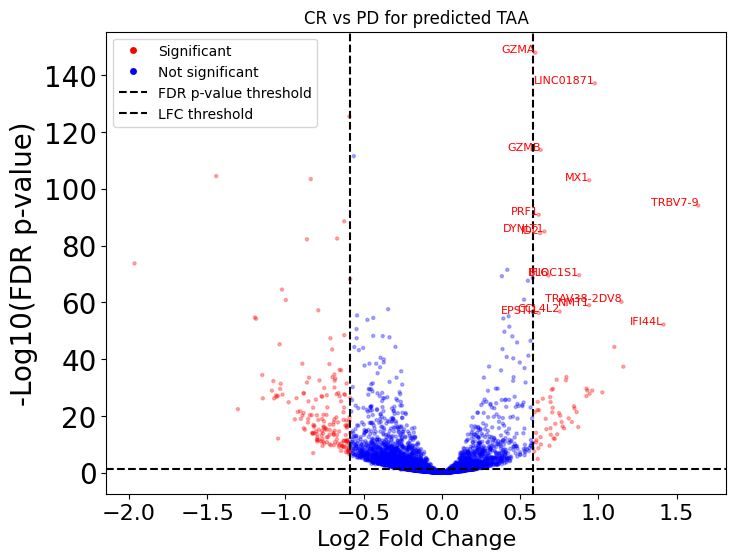

In [483]:
lfc_threshold = math.log2(1.5)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d_CR_PD_TAA['color'] = ['red' if abs(lfc) > lfc_threshold and pval < pval_threshold else 'blue' 
                 for lfc, pval in zip(result_1d_CR_PD_TAA['de_coef'], result_1d_CR_PD_TAA['de_pval'])]

# Plot volcano plot
plt.figure(figsize=(8, 6))
plt.scatter(result_1d_CR_PD_TAA['de_coef'], -np.log10(result_1d_CR_PD_TAA['de_pval']), c=result_1d_CR_PD_TAA['color'], alpha=0.3, s=5) # s is the size of the dots

# Highlight significant genes by annotating them
for i, row in result_1d_CR_PD_TAA.iterrows():
    if abs(row['de_coef']) > lfc_threshold and row['de_pval'] < pval_threshold:
        if row['gene'] in result_1d_CR_PD_TAA[(result_1d_CR_PD_TAA['color'] == "red") & (result_1d_CR_PD_TAA['de_coef'] > 0)].sort_values('de_pval', ascending=True).head(15)['gene'].values:
            plt.text(row['de_coef'], -np.log10(row['de_pval']), row['gene'], fontsize=8, ha='right', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black')

plt.xlabel('Log2 Fold Change', fontsize = 16)
plt.ylabel('-Log10(FDR p-value)', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 20)
plt.title('CR vs PD for predicted TAA')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, loc='upper left')
plt.show()

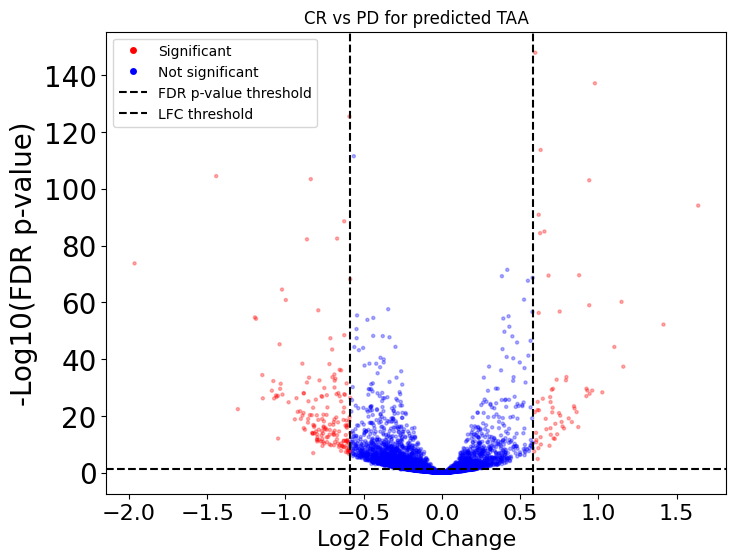

In [482]:
lfc_threshold = math.log2(1.5)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d_CR_PD_TAA['color'] = ['red' if abs(lfc) > lfc_threshold and pval < pval_threshold else 'blue' 
                 for lfc, pval in zip(result_1d_CR_PD_TAA['de_coef'], result_1d_CR_PD_TAA['de_pval'])]

# Plot volcano plot
plt.figure(figsize=(8, 6))
plt.scatter(result_1d_CR_PD_TAA['de_coef'], -np.log10(result_1d_CR_PD_TAA['de_pval']), c=result_1d_CR_PD_TAA['color'], alpha=0.3, s=5) # s is the size of the dots

# # Highlight significant genes by annotating them
# for i, row in result_1d_CR_PD_TAA.iterrows():
#     if abs(row['de_coef']) > lfc_threshold and row['de_pval'] < pval_threshold:
#         if row['gene'] in result_1d_CR_PD_TAA[(result_1d_CR_PD_TAA['color'] == "red") & (result_1d_CR_PD_TAA['de_coef'] > 0)].sort_values('de_pval', ascending=True).head(15)['gene'].values:
#             plt.text(row['de_coef'], -np.log10(row['de_pval']), row['gene'], fontsize=8, ha='right', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black')

plt.xlabel('Log2 Fold Change', fontsize = 16)
plt.ylabel('-Log10(FDR p-value)', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 20)
plt.title('CR vs PD for predicted TAA')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, loc='upper left')
plt.show()

In [ ]:
rank_gene = result_1d_CR_PD_TAA.sort_values('de_pval', ascending=True)
rank_gene['log_p_val'] = -np.log(rank_gene['de_pval'])
# pip install gseapy pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import gseapy as gp
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1) Load ranked gene list
# -----------------------------
# Input file should have at least:
# gene, score
# score can be logFC, t-statistic, Wald stat, etc.

# GSEA expects a two-column ranked table
rnk = rank_gene[["gene", "log_p_val"]]

# -----------------------------
# 2) Run preranked GSEA
# -----------------------------
# Choose any gene set collection you want:
# examples: 'KEGG_2021_Human', 'GO_Biological_Process_2023',
# 'Reactome_2022', 'Hallmark_2020'
pre_res = gp.prerank(
    rnk=rnk,
    gene_sets="Reactome_2022",
    permutation_num=1000,
    seed=42,
    min_size=10,
    max_size=500,
    outdir=None,
    verbose=True
)


# Results table
res = pre_res.res2d.copy()
res = res.reset_index().rename(columns={"index": "Term"})

# Save results
res.to_csv("gsea_results.csv", index=False)

# -----------------------------
# 3) Dotplot of pathways
# -----------------------------
# Pick top pathways by FDR
plot_df = res.copy()
plot_df["FDR q-val"] = pd.to_numeric(plot_df["FDR q-val"], errors="coerce")
plot_df["NES"] = pd.to_numeric(plot_df["NES"], errors="coerce")

# Keep significant pathways
plot_df = plot_df.sort_values("FDR q-val", ascending=True)

plot_df

2026-04-29 17:23:40,229 [INFO] Parsing data files for GSEA.............................
2026-04-29 17:23:40,234 [INFO] Enrichr library gene sets already downloaded in: /Users/phle/.cache/gseapy, use local file
2026-04-29 17:23:40,261 [INFO] 0956 gene_sets have been filtered out when max_size=500 and min_size=10
2026-04-29 17:23:40,262 [INFO] 0862 gene_sets used for further statistical testing.....
2026-04-29 17:23:40,262 [INFO] Start to run GSEA...Might take a while..................
2026-04-29 17:23:43,389 [INFO] Congratulations. GSEApy runs successfully................



,Term,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,0,prerank,tRNA Modification In Nucleus And Cytosol R-HSA...,-0.369375,-1.704105,0.0,0.011342,0.005252,18/18,63.19%,THADA;TRDMT1;LAGE3;TRMT6;TRMT112;CDKAL1;ADAT2;...
22,22,prerank,"Gamma Carboxylation, Hypusine Formation And Ar...",-0.446551,-1.387093,0.0,0.105860,0.092437,15/15,55.47%,TPST2;ARSA;FURIN;TTF2;GGCX;DOHH;EIF5A2;DPH1;DH...
212,212,prerank,KSRP (KHSRP) Binds And Destabilizes mRNA R-HSA...,-0.406171,-1.188061,0.115385,0.341525,0.384454,11/11,59.47%,DIS3;EXOSC3;EXOSC5;EXOSC7;EXOSC4;KHSRP;DCP2;PA...
297,297,prerank,Class I Peroxisomal Membrane Protein Import R-...,-0.40996,-1.125961,0.173913,0.402174,0.528361,10/10,59.09%,PEX19;ACBD5;PEX16;ALDH3A2;PEX3;ATAD1;PEX2;SLC2...
9,9,prerank,PD-1 Signaling R-HSA-389948,0.852952,1.445095,0.021407,0.519596,0.938,5/11,5.31%,HLA-DRB1;HLA-DQA1;HLA-DRA;PTPN6;HLA-DPA1
...,...,...,...,...,...,...,...,...,...,...,...
801,801,prerank,Diseases Of DNA Repair R-HSA-9675135,0.418362,0.726188,0.922,1.000000,1.0,1/22,4.64%,ATM
800,800,prerank,Cytoprotection By HMOX1 R-HSA-9707564,0.408272,0.726945,0.95,1.000000,1.0,12/31,42.57%,TXNIP;STAT3;COX16;COX7B;COX14;ABCC1;SIN3A;NCOA...
799,799,prerank,Nonhomologous End-Joining (NHEJ) R-HSA-5693571,0.409692,0.727213,0.926707,1.000000,1.0,2/24,13.59%,ATM;PRKDC
807,807,prerank,TNF Signaling R-HSA-75893,0.396999,0.701558,0.950951,1.000000,1.0,6/28,25.51%,CYLD;CASP8;BIRC2;TNF;TRADD;BIRC3


# Compare CR vs. PD for pre-treatment

In [415]:
adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre = adata_raw_noHC_no_NA_outcome_high_conf_CR_PD[adata_raw_noHC_no_NA_outcome_high_conf_CR_PD.obs['timepoint'].str.contains("pre")].copy()
adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre

AnnData object with n_obs × n_vars = 3787 × 15827
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'predicted_binding_probability', 'peptide_cat', 'tumor_pred_ref_non_tumor', 'outcome_ref_PD'
    obsm: 'X_umap'
    layers: 'counts'

In [491]:
adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre.write("adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre.h5ad")

In [416]:
result_1d_CR_PD_TAA_pre_treatment = memento.binary_test_1d(
    adata=adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre, 
    capture_rate=0.07, 
    treatment_col='outcome_ref_PD', 
    num_cpus=6,
    num_boot=5000)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    6.6s
[Parallel(n_jobs=6)]: Done 188 tasks      | elapsed:   17.0s
[Parallel(n_jobs=6)]: Done 438 tasks      | elapsed:   42.0s
[Parallel(n_jobs=6)]: Done 788 tasks      | elapsed:  1.3min
[Parallel(n_jobs=6)]: Done 1238 tasks      | elapsed:  1.9min
[Parallel(n_jobs=6)]: Done 1788 tasks      | elapsed:  2.6min
[Parallel(n_jobs=6)]: Done 2438 tasks      | elapsed:  3.6min
[Parallel(n_jobs=6)]: Done 3188 tasks      | elapsed:  4.6min
[Parallel(n_jobs=6)]: Done 4038 tasks      | elapsed:  5.8min
[Parallel(n_jobs=6)]: Done 4988 tasks      | elapsed:  7.1min
[Parallel(n_job

In [417]:
result_1d_CR_PD_TAA_pre_treatment.to_csv("adata_raw_noHC_no_NA_outcome_high_conf_result_1d_CR_PD_TAA_pre_treatment.csv")

In [419]:
result_1d_CR_PD_TAA_pre_treatment["pval_adj"] = multipletests(result_1d_CR_PD_TAA_pre_treatment["de_pval"], method="fdr_bh")[1]

In [447]:
result_1d_CR_PD_TAA_pre_treatment[result_1d_CR_PD_TAA_pre_treatment['color'] == "red"].sort_values('pval_adj', ascending=True).head(15)['gene'].values

array(['FOS', 'GZMA', 'LINC01871', 'HLA-DQA1', 'ODC1', 'STK17A', 'DNAJB1',
       'CMTM3', 'GZMB', 'IFI6', 'KHDRBS1', 'LTB', 'SOCS1', 'LGALS1',
       'HLA-DRA'], dtype=object)

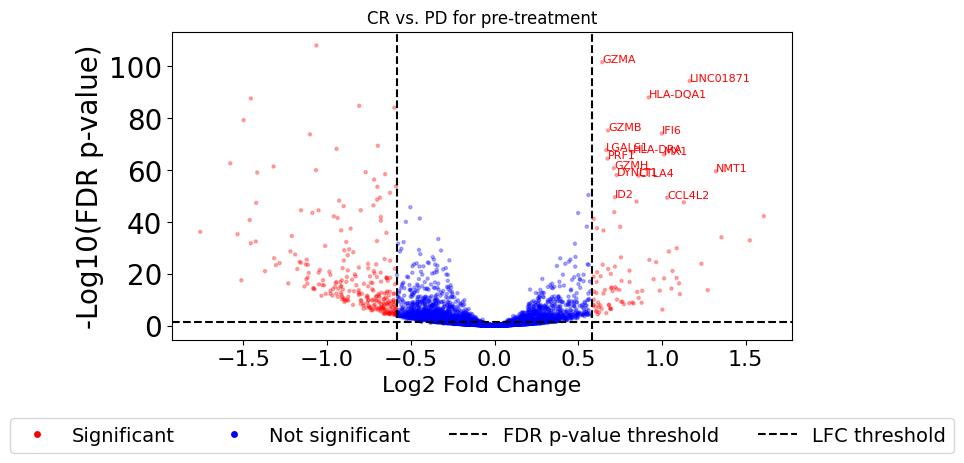

In [580]:
lfc_threshold = math.log2(1.5)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d_CR_PD_TAA_pre_treatment['color'] = ['red' if abs(lfc) > lfc_threshold and pval < pval_threshold else 'blue' 
                 for lfc, pval in zip(result_1d_CR_PD_TAA_pre_treatment['de_coef'], result_1d_CR_PD_TAA_pre_treatment['pval_adj'])]

# Plot volcano plot
plt.figure(figsize=(8, 4))
plt.scatter(result_1d_CR_PD_TAA_pre_treatment['de_coef'], -np.log10(result_1d_CR_PD_TAA_pre_treatment['pval_adj']), c=result_1d_CR_PD_TAA_pre_treatment['color'], alpha=0.3, s=5) # s is the size of the dots

# Highlight significant genes by annotating them
for i, row in result_1d_CR_PD_TAA_pre_treatment.iterrows():
    if abs(row['de_coef']) > lfc_threshold and row['pval_adj'] < pval_threshold:
        if row['gene'] in result_1d_CR_PD_TAA_pre_treatment[(result_1d_CR_PD_TAA_pre_treatment['color'] == "red") & (result_1d_CR_PD_TAA_pre_treatment['de_coef'] > 0)].sort_values('pval_adj', ascending=True).head(15)['gene'].values:
            plt.text(row['de_coef'], -np.log10(row['pval_adj']), row['gene'], fontsize=8, ha='left', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black')

plt.xlabel('Log2 Fold Change', fontsize = 16)
plt.ylabel('-Log10(FDR p-value)', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 20)
plt.title('CR vs. PD for pre-treatment')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, bbox_to_anchor = (0.5,-0.4) ,loc='lower center',ncol=4, fontsize=14)
plt.show()

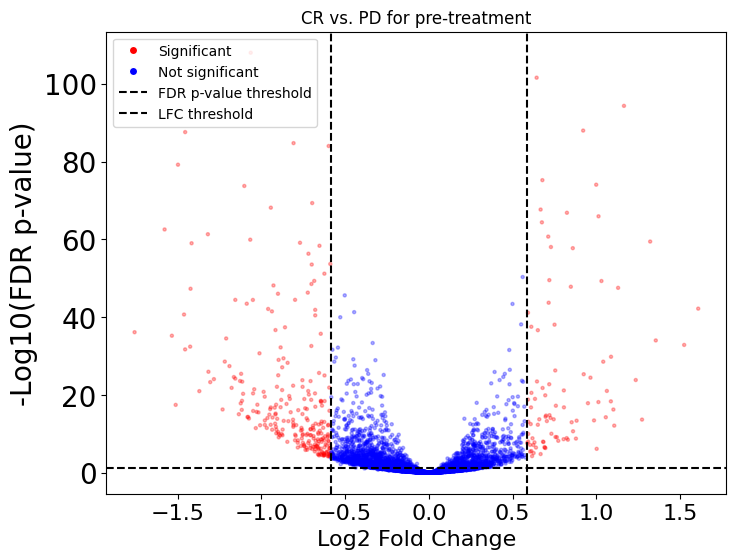

In [480]:
lfc_threshold = math.log2(1.5)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d_CR_PD_TAA_pre_treatment['color'] = ['red' if abs(lfc) > lfc_threshold and pval < pval_threshold else 'blue' 
                 for lfc, pval in zip(result_1d_CR_PD_TAA_pre_treatment['de_coef'], result_1d_CR_PD_TAA_pre_treatment['pval_adj'])]

# Plot volcano plot
plt.figure(figsize=(8, 6))
plt.scatter(result_1d_CR_PD_TAA_pre_treatment['de_coef'], -np.log10(result_1d_CR_PD_TAA_pre_treatment['pval_adj']), c=result_1d_CR_PD_TAA_pre_treatment['color'], alpha=0.3, s=5) # s is the size of the dots

# Highlight significant genes by annotating them
# for i, row in result_1d_CR_PD_TAA_pre_treatment.iterrows():
#     if abs(row['de_coef']) > lfc_threshold and row['pval_adj'] < pval_threshold:
#         if row['gene'] in result_1d_CR_PD_TAA_pre_treatment[(result_1d_CR_PD_TAA_pre_treatment['color'] == "red") & (result_1d_CR_PD_TAA_pre_treatment['de_coef'] > 0)].sort_values('pval_adj', ascending=True).head(15)['gene'].values:
#             plt.text(row['de_coef'], -np.log10(row['pval_adj']), row['gene'], fontsize=8, ha='right', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black')

plt.xlabel('Log2 Fold Change', fontsize = 16)
plt.ylabel('-Log10(FDR p-value)', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 20)
plt.title('CR vs. PD for pre-treatment')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, loc='upper left')
plt.show()

In [427]:
result_1d_CR_PD_TAA_pre_treatment[result_1d_CR_PD_TAA_pre_treatment['color'] == "red"].sort_values('pval_adj', ascending=True).head(15)['gene'].values

array(['FOS', 'GZMA', 'LINC01871', 'HLA-DQA1', 'ODC1', 'STK17A', 'DNAJB1',
       'CMTM3', 'GZMB', 'IFI6', 'KHDRBS1', 'LTB', 'SOCS1', 'LGALS1',
       'HLA-DRA'], dtype=object)

In [495]:
adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD = sc.read_h5ad("adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD.h5ad")

In [496]:
adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD

AnnData object with n_obs × n_vars = 845 × 64
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'tissue', 'final_cell_type', 'leiden', 'outcome_order', 'IFN_score', 'cytotoxic', 'exhaustion', 'tumor_reactive', 'nk_killing', 'match', 'category', 'tumor_pred', 'tumor_pred_cat'
    uns: 'final_cell_type_colors', 'leiden', 'leiden_colors', 'match_colors', 'neighbors', 'outcome_colors', 'outcome_order_colors', 'patient_colors', 'pca', 'response_colors', 'timepoint_colors', 'tumor_pred_cat_colors', 'tumor_pred_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [44]:
cytotoxic_genes = [
    "PRF1",   # perforin
    "GZMB", "GZMA", "GZMH",  # granzymes
    "GNLY",   # granulysin
    "NKG7"
]
exhaustion_genes = [
    "PDCD1",  # PD-1
    "CTLA4",
    "LAG3",
    "TIGIT",
    "HAVCR2",  # TIM-3
    "TOX"
]
tumor_reactive = [
    "CXCL13", "PDCD1", "TOX", "ICOS", "LAG3"
]
sc.tl.score_genes(adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre, cytotoxic_genes, score_name="cytotoxic")
sc.tl.score_genes(adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre, exhaustion_genes, score_name="exhaustion")
sc.tl.score_genes(adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre, tumor_reactive, score_name="tumor_reactive")
cell_map = {'CD4T_naive2':'CD4T_naive',
 'CD4T_naive1':'CD4T_naive',
 'CD8_GrH':'CD8T_GrH',
 'CD4T_naive3':'CD4T_naive',
 'Treg':'Treg',
 'CD8T_prolif':'CD8T_prolif',
 'CD8T_GrK':'CD8T_GrK',
 'Treg1':'Treg',
 'CD8T_GrB':'CD8T_GrB',
 'CD4_Tnaive1':'CD4T_naive',
 'CD8T_GrH':'CD8T_GrH',
 'CD4_Tfh-like':'CD4_Tfh-like',
 'Treg2':'Treg',
 'gd_Tcell': 'gd_Tcell',
 'MAIT':'MAIT'}

adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre.obs['final_cell_type'] = adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre.obs['cell_type_scvi'].map(cell_map)

In [499]:
adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre

AnnData object with n_obs × n_vars = 3787 × 15827
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'predicted_binding_probability', 'peptide_cat', 'tumor_pred_ref_non_tumor', 'outcome_ref_PD', 'cytotoxic', 'exhaustion', 'tumor_reactive'
    obsm: 'X_umap'
    layers: 'counts'

In [ ]:
# adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre.write_h5ad("adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre_with_scores.h5ad")

In [43]:
adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre = sc.read_h5ad("adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre_with_scores.h5ad")

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CR vs. PD: t-test independent samples, P_val:5.741e-19 t=8.944e+00


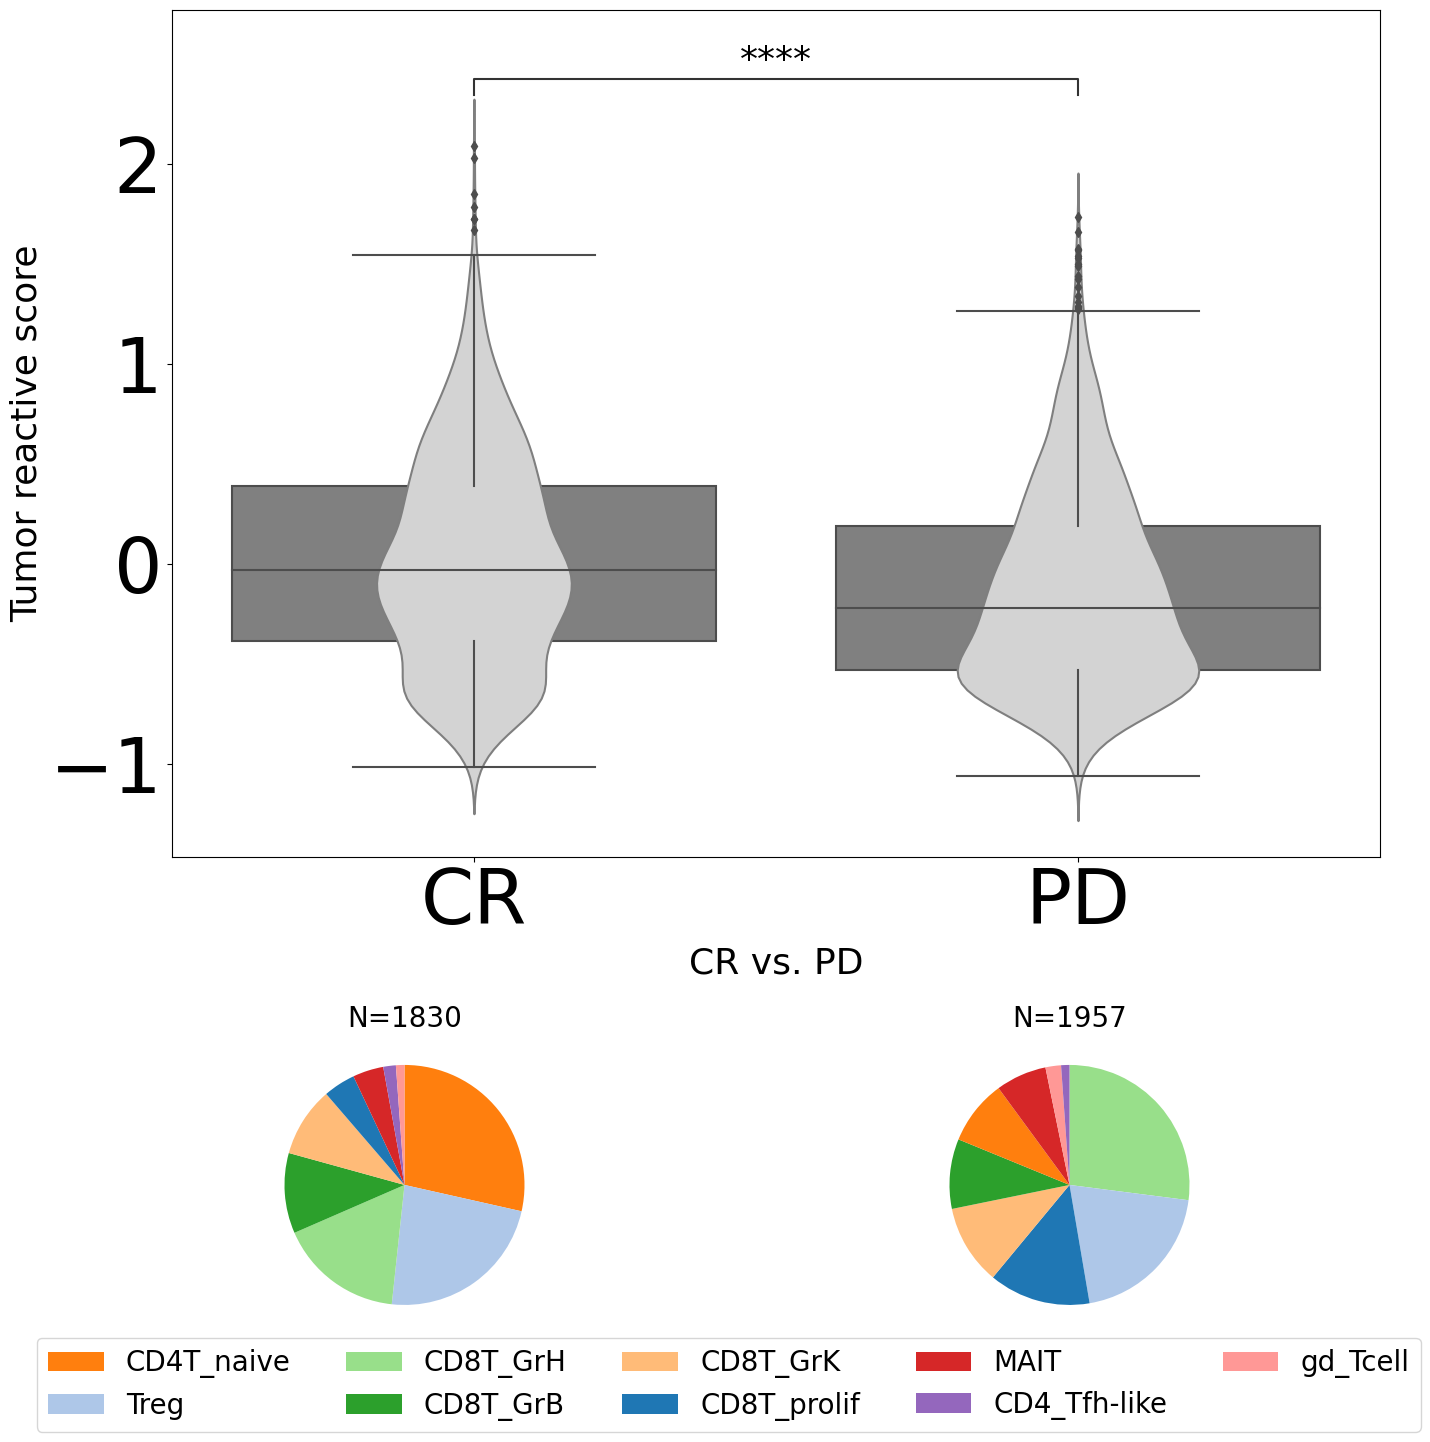

,group1,group2,n1,n2,mean1,mean2,statistic,pvalue,p_adj
0,PD,CR,1830,1957,-0.125071,0.025278,-8.964474,4.797698e-19,4.797698e-19


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

ordered_groups = [ "CR","PD" ]
adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_pre = adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre[adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre.obs['timepoint'].str.contains("pre")]
dt_TAA_CR_PD_pretreatment = adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_pre.obs.copy()

present_groups = [
    g for g in ordered_groups
    if g in dt_TAA_CR_PD_pretreatment["outcome"].unique()
]

# build pairs automatically from the present leiden groups
leiden_groups = sorted(dt_TAA_CR_PD_pretreatment["outcome"].astype(str).unique(), reverse=True)
pair_compaire = [
    ("CR","PD")
]
# pair_compaire = leiden_groups

palette = {g: "red" if "CR" in g else "grey" for g in present_groups}


fig, ax_box = plt.subplots(figsize=(14, 10))

sns.boxplot(
    data=dt_TAA_CR_PD_pretreatment,
    x="outcome",
    y="tumor_reactive",
    order=present_groups,
    # palette=palette,
    color="grey",
    ax=ax_box
)

sns.violinplot(
    data=dt_TAA_CR_PD_pretreatment,
    x="outcome",
    y="tumor_reactive",
    width=0.4,
    inner=None,
    order=present_groups,
    color="lightgray",
    alpha=0.8,
    ax=ax_box
)

annotator = Annotator(
    ax_box,
    data=dt_TAA_CR_PD_pretreatment,
    x="outcome",
    y="tumor_reactive",
    order=present_groups,
    pairs=pair_compaire
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", fontsize=26, hide_non_significant=True)
annotator.apply_and_annotate()

# ax_box.set_title("Score Comparison CR vs. PD for pre treatment within predicted TAA cells", fontsize=26)
ax_box.tick_params(axis="x",  labelsize=55)
ax_box.tick_params(axis="y",  labelsize=55)
ax_box.set_xlabel("CR vs. PD", fontsize=26)
ax_box.set_ylabel("Tumor reactive score", fontsize=26)

# Get axis position in figure coordinates
ax_pos = ax_box.get_position()

# Get x positions of categories
all_cell_types = dt_TAA_CR_PD_pretreatment["final_cell_type"].unique()
palette = sns.color_palette("tab20", len(all_cell_types))
color_map = dict(zip(all_cell_types, palette))
xticks = ax_box.get_xticks()

all_labels = None
all_handles = None
groups = dt_TAA_CR_PD_pretreatment["outcome"].unique()
for i, (x, grp) in enumerate(zip(xticks, groups)):
    sub = dt_TAA_CR_PD_pretreatment[dt_TAA_CR_PD_pretreatment["outcome"] == grp]
    counts = sub["final_cell_type"].value_counts()
    colors = [color_map[c] for c in counts.index]
    x_fig = ax_pos.x0 -0.22 + (x - ax_box.get_xlim()[0]) / (ax_box.get_xlim()[1] - ax_box.get_xlim()[0]) * 0.95
    y_fig = ax_pos.y0 - 0.45

    ax_pie = fig.add_axes([x_fig, y_fig, 0.3, 0.3])

    wedges, texts= ax_pie.pie(
        counts.values,
        labels=None,          # no labels on the pies
        autopct=None,
        startangle=90,
        colors=colors,
        counterclock=False,
    )

    ax_pie.set_aspect("equal")
    total = counts.sum()
    ax_pie.set_title(f"N={total}", fontsize=20)
    # save legend items only once
    if all_labels is None:
        all_labels = counts.index.tolist()
        all_handles = wedges
fig.legend(
    all_handles,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.02, y_fig - 0.05),
    # title="Cell type",
    fontsize=20,
    ncol=5
)


plt.tight_layout()
plt.show()


df = dt_TAA_CR_PD_pretreatment

groups = df["outcome"].dropna().unique()
pairs = list(itertools.combinations(groups, 2))

results = []

for g1, g2 in pairs:
    x1 = df.loc[df["outcome"] == g1, "tumor_reactive"].dropna()
    x2 = df.loc[df["outcome"] == g2, "tumor_reactive"].dropna()

    stat, pval = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test

    results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x1),
        "n2": len(x2),
        "mean1": x1.mean(),
        "mean2": x2.mean(),
        "statistic": stat,
        "pvalue": pval,
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
results_df["p_adj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

# results_df.to_csv("tumor_reactive CR vs PD pre treatment within predicted TAA.csv")
results_df

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CR vs. PD: t-test independent samples, P_val:3.859e-69 t=1.794e+01


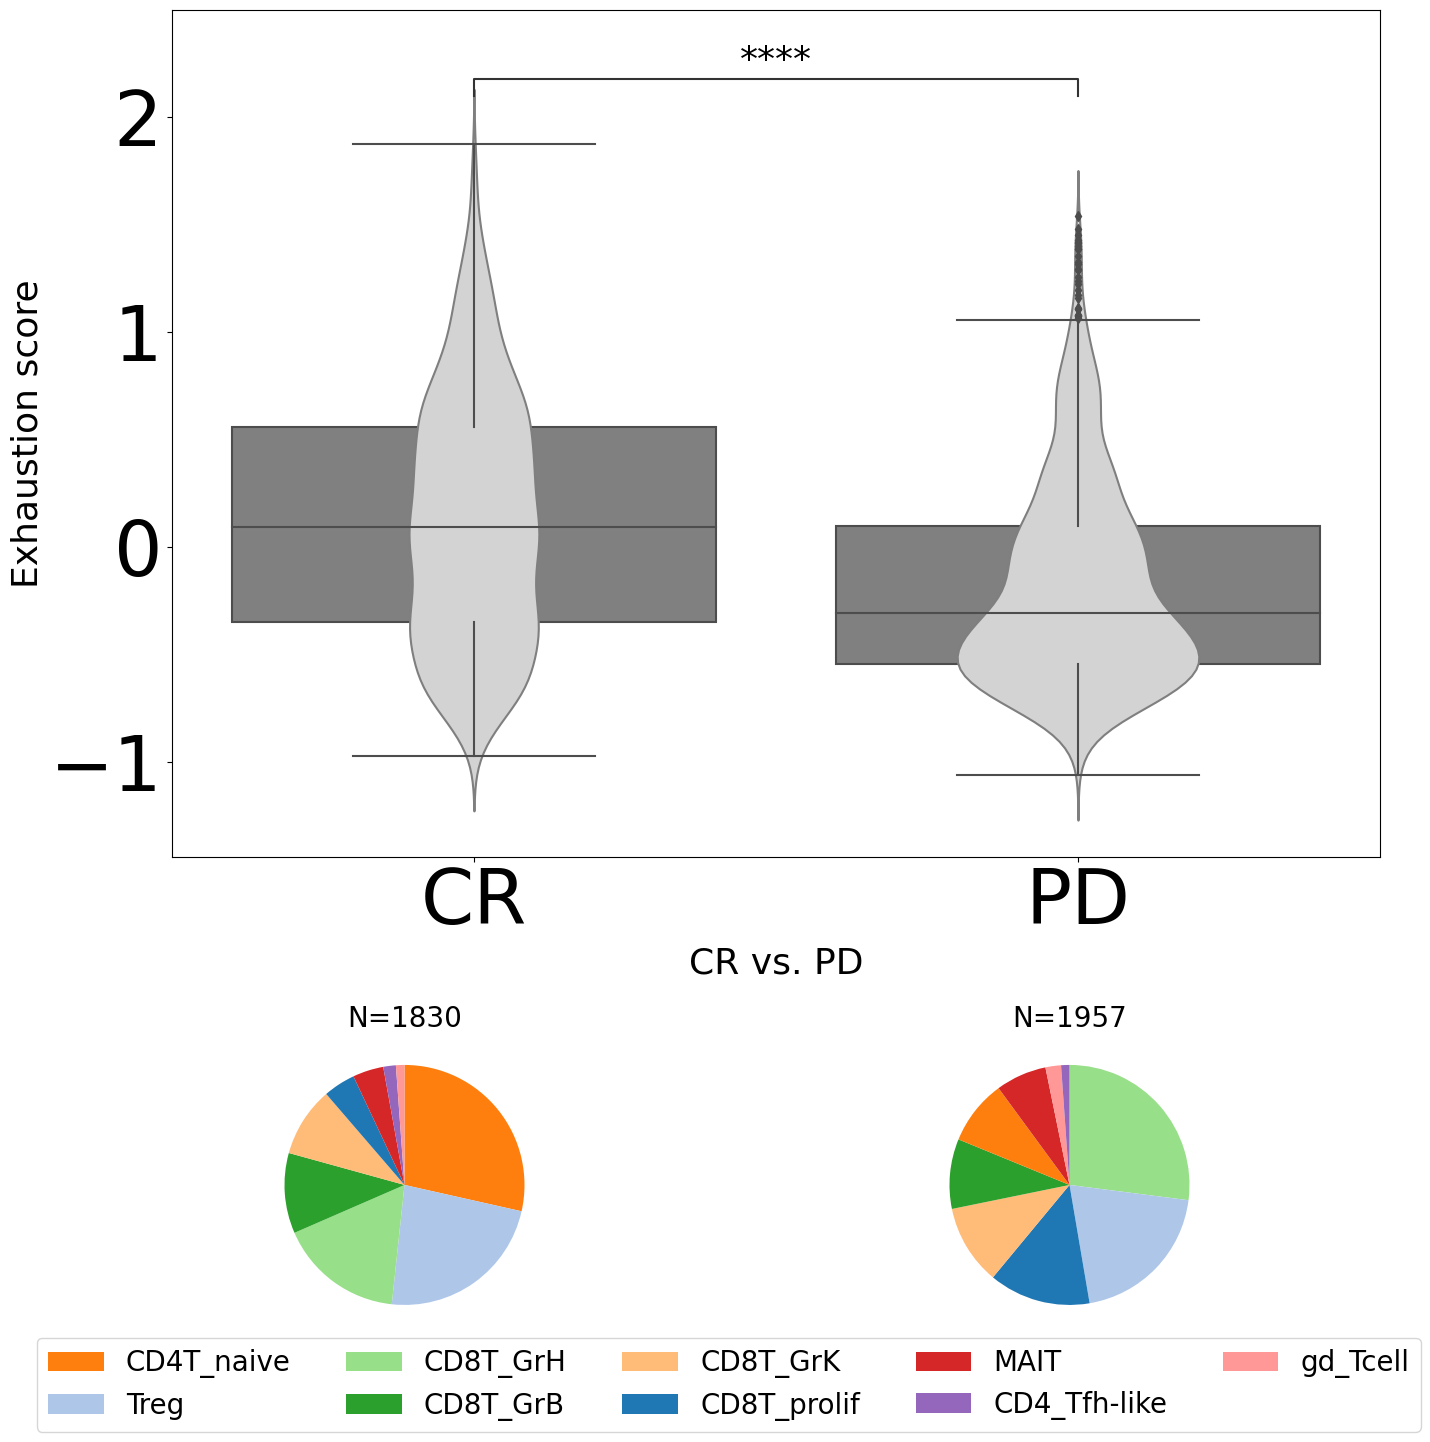

,group1,group2,n1,n2,mean1,mean2,statistic,pvalue,p_adj
0,PD,CR,1830,1957,-0.177793,0.131838,-18.058634,6.016067e-70,6.016067e-70


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

ordered_groups = [ "CR","PD" ]
adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_pre = adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre[adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre.obs['timepoint'].str.contains("pre")]
dt_TAA_CR_PD_pretreatment = adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_pre.obs.copy()

present_groups = [
    g for g in ordered_groups
    if g in dt_TAA_CR_PD_pretreatment["outcome"].unique()
]

# build pairs automatically from the present leiden groups
leiden_groups = sorted(dt_TAA_CR_PD_pretreatment["outcome"].astype(str).unique(), reverse=True)
pair_compaire = [
    ("CR","PD")
]
# pair_compaire = leiden_groups

palette = {g: "red" if "CR" in g else "grey" for g in present_groups}


fig, ax_box = plt.subplots(figsize=(14, 10))

sns.boxplot(
    data=dt_TAA_CR_PD_pretreatment,
    x="outcome",
    y="exhaustion",
    order=present_groups,
    # palette=palette,
    color="grey",
    ax=ax_box
)

sns.violinplot(
    data=dt_TAA_CR_PD_pretreatment,
    x="outcome",
    y="exhaustion",
    width=0.4,
    inner=None,
    order=present_groups,
    color="lightgray",
    alpha=0.8,
    ax=ax_box
)

annotator = Annotator(
    ax_box,
    data=dt_TAA_CR_PD_pretreatment,
    x="outcome",
    y="exhaustion",
    order=present_groups,
    pairs=pair_compaire
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", fontsize=26, hide_non_significant=True)
annotator.apply_and_annotate()

# ax_box.set_title("Score Comparison CR vs. PD for pretreatment within predicted TAA cells", fontsize=26)
ax_box.tick_params(axis="x",  labelsize=55)
ax_box.tick_params(axis="y",  labelsize=55)
ax_box.set_xlabel("CR vs. PD", fontsize=26)
ax_box.set_ylabel("Exhaustion score", fontsize=26)

# Get axis position in figure coordinates
ax_pos = ax_box.get_position()

# Get x positions of categories
all_cell_types = dt_TAA_CR_PD_pretreatment["final_cell_type"].unique()
palette = sns.color_palette("tab20", len(all_cell_types))
color_map = dict(zip(all_cell_types, palette))
xticks = ax_box.get_xticks()

all_labels = None
all_handles = None
groups = dt_TAA_CR_PD_pretreatment["outcome"].unique()
for i, (x, grp) in enumerate(zip(xticks, groups)):
    sub = dt_TAA_CR_PD_pretreatment[dt_TAA_CR_PD_pretreatment["outcome"] == grp]
    counts = sub["final_cell_type"].value_counts()
    colors = [color_map[c] for c in counts.index]
    x_fig = ax_pos.x0 -0.22 + (x - ax_box.get_xlim()[0]) / (ax_box.get_xlim()[1] - ax_box.get_xlim()[0]) * 0.95
    y_fig = ax_pos.y0 - 0.45

    ax_pie = fig.add_axes([x_fig, y_fig, 0.3, 0.3])

    wedges, texts= ax_pie.pie(
        counts.values,
        labels=None,          # no labels on the pies
        autopct=None,
        startangle=90,
        colors=colors,
        counterclock=False,
    )

    ax_pie.set_aspect("equal")
    total = counts.sum()
    ax_pie.set_title(f"N={total}", fontsize=20)
    # save legend items only once
    if all_labels is None:
        all_labels = counts.index.tolist()
        all_handles = wedges
fig.legend(
    all_handles,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.02, y_fig - 0.05),
    # title="Cell type",
    fontsize=20,
    ncol=5
)


plt.tight_layout()
plt.show()


df = dt_TAA_CR_PD_pretreatment

groups = df["outcome"].dropna().unique()
pairs = list(itertools.combinations(groups, 2))

results = []

for g1, g2 in pairs:
    x1 = df.loc[df["outcome"] == g1, "exhaustion"].dropna()
    x2 = df.loc[df["outcome"] == g2, "exhaustion"].dropna()

    stat, pval = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test

    results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x1),
        "n2": len(x2),
        "mean1": x1.mean(),
        "mean2": x2.mean(),
        "statistic": stat,
        "pvalue": pval,
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
results_df["p_adj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

# results_df.to_csv("exhaustion CR vs PD pre treatment within predicted TAA.csv")
results_df

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CR vs. PD: t-test independent samples, P_val:3.503e-88 t=2.044e+01


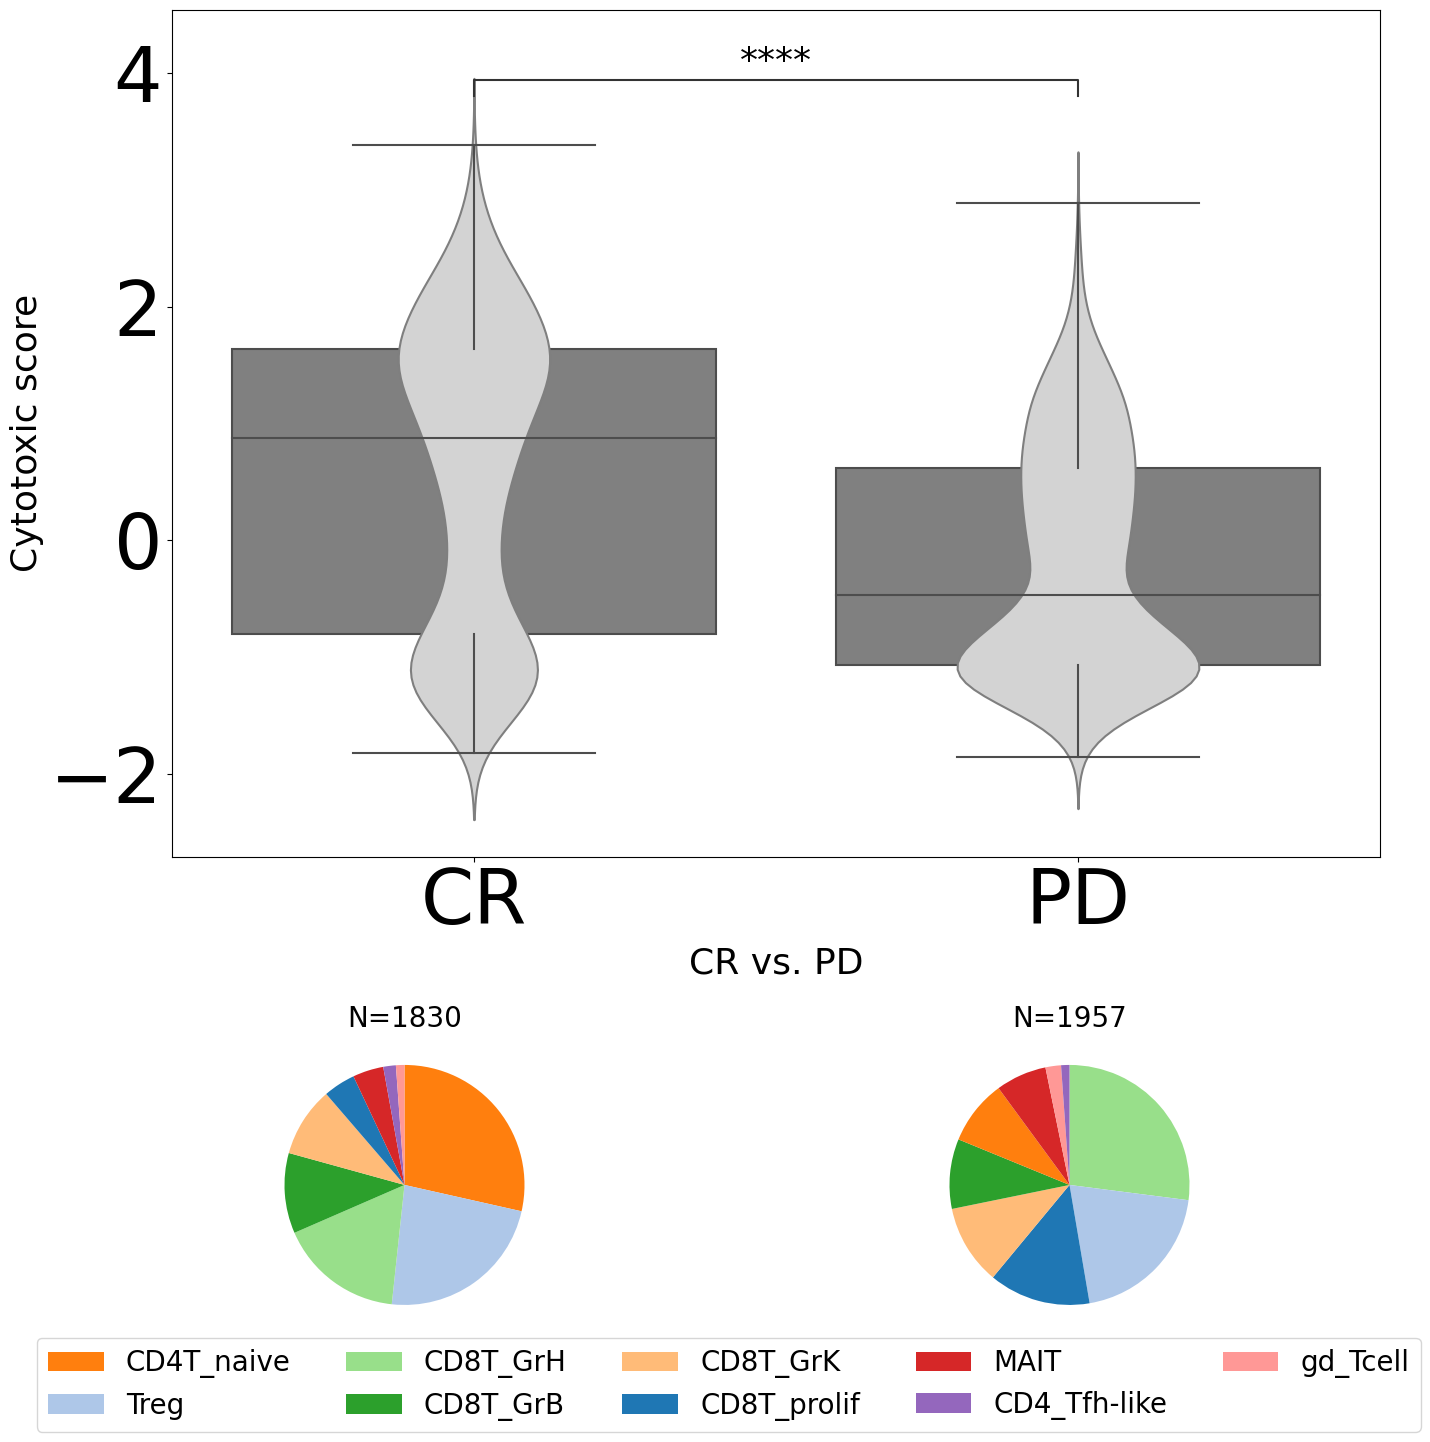

,group1,group2,n1,n2,mean1,mean2,statistic,pvalue,p_adj
0,PD,CR,1830,1957,-0.19874,0.572066,-20.628685,1.708167e-89,1.708167e-89


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

ordered_groups = [ "CR","PD" ]
adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_pre = adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre[adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_pre.obs['timepoint'].str.contains("pre")]
dt_TAA_CR_PD_pretreatment = adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_pre.obs.copy()

present_groups = [
    g for g in ordered_groups
    if g in dt_TAA_CR_PD_pretreatment["outcome"].unique()
]

# build pairs automatically from the present leiden groups
leiden_groups = sorted(dt_TAA_CR_PD_pretreatment["outcome"].astype(str).unique(), reverse=True)
pair_compaire = [
    ("CR","PD")
]
# pair_compaire = leiden_groups

palette = {g: "red" if "CR" in g else "grey" for g in present_groups}


fig, ax_box = plt.subplots(figsize=(14, 10))

sns.boxplot(
    data=dt_TAA_CR_PD_pretreatment,
    x="outcome",
    y="cytotoxic",
    order=present_groups,
    # palette=palette,
    color="grey",
    ax=ax_box
)

sns.violinplot(
    data=dt_TAA_CR_PD_pretreatment,
    x="outcome",
    y="cytotoxic",
    width=0.4,
    inner=None,
    order=present_groups,
    color="lightgray",
    alpha=0.8,
    ax=ax_box
)

annotator = Annotator(
    ax_box,
    data=dt_TAA_CR_PD_pretreatment,
    x="outcome",
    y="cytotoxic",
    order=present_groups,
    pairs=pair_compaire
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", fontsize=26, hide_non_significant=True)
annotator.apply_and_annotate()

# ax_box.set_title("Score Comparison CR vs. PD for pretreatment within predicted TAA cells", fontsize=26)
ax_box.tick_params(axis="x",  labelsize=55)
ax_box.tick_params(axis="y",  labelsize=55)
ax_box.set_xlabel("CR vs. PD", fontsize=26)
ax_box.set_ylabel("Cytotoxic score", fontsize=26)

# Get axis position in figure coordinates
ax_pos = ax_box.get_position()

# Get x positions of categories
all_cell_types = dt_TAA_CR_PD_pretreatment["final_cell_type"].unique()
palette = sns.color_palette("tab20", len(all_cell_types))
color_map = dict(zip(all_cell_types, palette))
xticks = ax_box.get_xticks()

all_labels = None
all_handles = None
groups = dt_TAA_CR_PD_pretreatment["outcome"].unique()
for i, (x, grp) in enumerate(zip(xticks, groups)):
    sub = dt_TAA_CR_PD_pretreatment[dt_TAA_CR_PD_pretreatment["outcome"] == grp]
    counts = sub["final_cell_type"].value_counts()
    colors = [color_map[c] for c in counts.index]
    x_fig = ax_pos.x0 -0.22 + (x - ax_box.get_xlim()[0]) / (ax_box.get_xlim()[1] - ax_box.get_xlim()[0]) * 0.95
    y_fig = ax_pos.y0 - 0.45

    ax_pie = fig.add_axes([x_fig, y_fig, 0.3, 0.3])

    wedges, texts= ax_pie.pie(
        counts.values,
        labels=None,          # no labels on the pies
        autopct=None,
        startangle=90,
        colors=colors,
        counterclock=False,
    )

    ax_pie.set_aspect("equal")
    total = counts.sum()
    ax_pie.set_title(f"N={total}", fontsize=20)
    # save legend items only once
    if all_labels is None:
        all_labels = counts.index.tolist()
        all_handles = wedges
fig.legend(
    all_handles,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.02, y_fig - 0.05),
    # title="Cell type",
    fontsize=20,
    ncol=5
)


plt.tight_layout()
plt.show()


df = dt_TAA_CR_PD_pretreatment

groups = df["outcome"].dropna().unique()
pairs = list(itertools.combinations(groups, 2))

results = []

for g1, g2 in pairs:
    x1 = df.loc[df["outcome"] == g1, "cytotoxic"].dropna()
    x2 = df.loc[df["outcome"] == g2, "cytotoxic"].dropna()

    stat, pval = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test

    results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x1),
        "n2": len(x2),
        "mean1": x1.mean(),
        "mean2": x2.mean(),
        "statistic": stat,
        "pvalue": pval,
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
results_df["p_adj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

# results_df.to_csv("cytotoxic CR vs PD pre treatment within predicted TAA.csv")
results_df

# Compare CR vs. PD for post treatment

In [434]:
adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_post = adata_raw_noHC_no_NA_outcome_high_conf_CR_PD[adata_raw_noHC_no_NA_outcome_high_conf_CR_PD.obs['timepoint'].str.contains("post")].copy()
adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_post

AnnData object with n_obs × n_vars = 2025 × 15827
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'predicted_binding_probability', 'peptide_cat', 'tumor_pred_ref_non_tumor', 'outcome_ref_PD'
    obsm: 'X_umap'
    layers: 'counts'

In [ ]:
# adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_post.write("adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_post.h5ad")

In [48]:
adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_post = sc.read_h5ad("adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_post.h5ad")

In [435]:
result_1d_CR_PD_TAA_post_treatment = memento.binary_test_1d(
    adata=adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_post, 
    capture_rate=0.07, 
    treatment_col='outcome_ref_PD', 
    num_cpus=6,
    num_boot=5000)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    5.6s
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=6)]: Done 224 tasks      | elapsed:   16.2s
[Parallel(n_jobs=6)]: Done 474 tasks      | elapsed:   32.0s
[Parallel(n_jobs=6)]: Done 824 tasks      | elapsed:   52.9s
[Parallel(n_jobs=6)]: Done 1274 tasks      | elapsed:  1.3min
[Parallel(n_jobs=6)]: Done 1992 tasks      | elapsed:  1.9min
[Parallel(n_jobs=6)]: Done 2806 tasks      | elapsed:  2.6min
[Parallel(n_jobs=6)]: Done 4172 tasks      | elapsed:  3.6min
[Parallel(n_jobs=6)]: Done 5022 tasks      | elapsed:  4.4min
[Parallel(n_jobs=6)]: Done 5972 tasks      | elapsed:  5.3min
[Parallel(n_job

In [436]:
result_1d_CR_PD_TAA_post_treatment.to_csv("adata_raw_noHC_no_NA_outcome_high_conf_result_1d_CR_PD_TAA_post_treatment.csv")

In [437]:
result_1d_CR_PD_TAA_post_treatment["pval_adj"] = multipletests(result_1d_CR_PD_TAA_post_treatment["de_pval"], method="fdr_bh")[1]

In [448]:
result_1d_CR_PD_TAA_post_treatment[result_1d_CR_PD_TAA_post_treatment['color'] == "red"].sort_values('pval_adj', ascending=True).head(15)['gene'].values

array(['ID2', 'TRAV38-2DV8', 'TRBV7-9', 'EIF4A1', 'HSPA1A', 'HSPA1B',
       'LINC01871', 'BLOC1S1', 'APOBEC3C', 'HSPH1', 'SQSTM1', 'GSTP1',
       'ISG15', 'ABI3', 'RANBP1'], dtype=object)

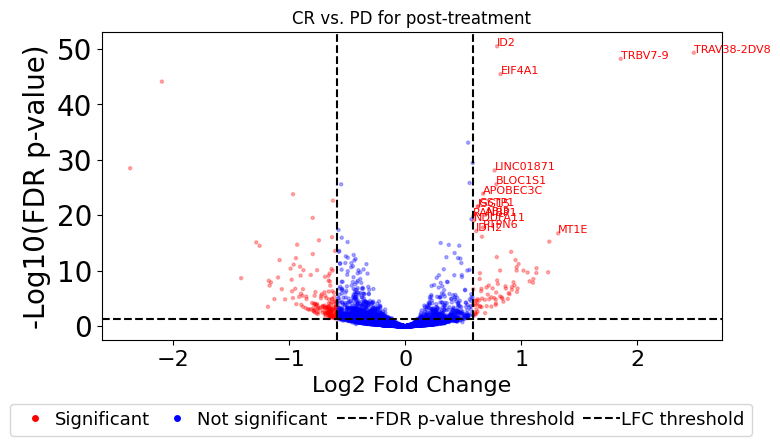

In [611]:
lfc_threshold = math.log2(1.5)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d_CR_PD_TAA_post_treatment['color'] = ['red' if abs(lfc) > lfc_threshold and pval < pval_threshold else 'blue' 
                 for lfc, pval in zip(result_1d_CR_PD_TAA_post_treatment['de_coef'], result_1d_CR_PD_TAA_post_treatment['pval_adj'])]

# Plot volcano plot
plt.figure(figsize=(8, 4))
plt.scatter(result_1d_CR_PD_TAA_post_treatment['de_coef'], -np.log10(result_1d_CR_PD_TAA_post_treatment['pval_adj']), c=result_1d_CR_PD_TAA_post_treatment['color'], alpha=0.3, s=5) # s is the size of the dots

# Highlight significant genes by annotating them
for i, row in result_1d_CR_PD_TAA_post_treatment.iterrows():
    if abs(row['de_coef']) > lfc_threshold and row['pval_adj'] < pval_threshold:
        if row['gene'] in result_1d_CR_PD_TAA_post_treatment[(result_1d_CR_PD_TAA_post_treatment['color'] == "red") & (result_1d_CR_PD_TAA_post_treatment['de_coef'] > 0)].sort_values('pval_adj', ascending=True).head(15)['gene'].values:
            plt.text(row['de_coef'], -np.log10(row['pval_adj']), row['gene'], fontsize=8, ha='left', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black')

plt.xlabel('Log2 Fold Change', fontsize = 16)
plt.ylabel('-Log10(FDR p-value)', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 20)
plt.title('CR vs. PD for post-treatment')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, bbox_to_anchor = (0.45,-0.34) ,loc='lower center',ncol=4, fontsize=13,columnspacing=0.5,handletextpad=0.1)
plt.show()

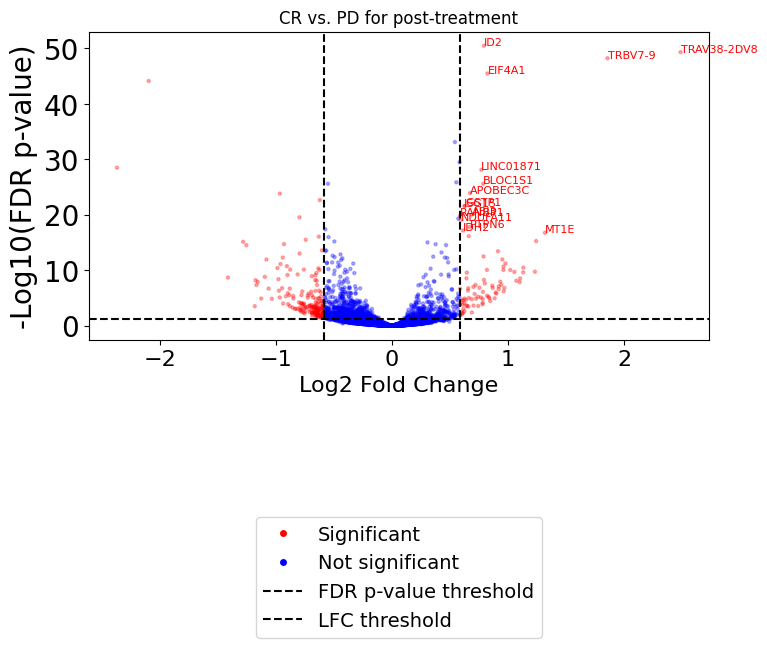

In [583]:
lfc_threshold = math.log2(1.5)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d_CR_PD_TAA_post_treatment['color'] = ['red' if abs(lfc) > lfc_threshold and pval < pval_threshold else 'blue' 
                 for lfc, pval in zip(result_1d_CR_PD_TAA_post_treatment['de_coef'], result_1d_CR_PD_TAA_post_treatment['pval_adj'])]

# Plot volcano plot
plt.figure(figsize=(8, 4))
plt.scatter(result_1d_CR_PD_TAA_post_treatment['de_coef'], -np.log10(result_1d_CR_PD_TAA_post_treatment['pval_adj']), c=result_1d_CR_PD_TAA_post_treatment['color'], alpha=0.3, s=5) # s is the size of the dots

# Highlight significant genes by annotating them
for i, row in result_1d_CR_PD_TAA_post_treatment.iterrows():
    if abs(row['de_coef']) > lfc_threshold and row['pval_adj'] < pval_threshold:
        if row['gene'] in result_1d_CR_PD_TAA_post_treatment[(result_1d_CR_PD_TAA_post_treatment['color'] == "red") & (result_1d_CR_PD_TAA_post_treatment['de_coef'] > 0)].sort_values('pval_adj', ascending=True).head(15)['gene'].values:
            plt.text(row['de_coef'], -np.log10(row['pval_adj']), row['gene'], fontsize=8, ha='left', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black')

plt.xlabel('Log2 Fold Change', fontsize = 16)
plt.ylabel('-Log10(FDR p-value)', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 20)
plt.title('CR vs. PD for post-treatment')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, bbox_to_anchor = (0.5,-1) ,loc='lower center',ncol=1, fontsize=14)
plt.show()

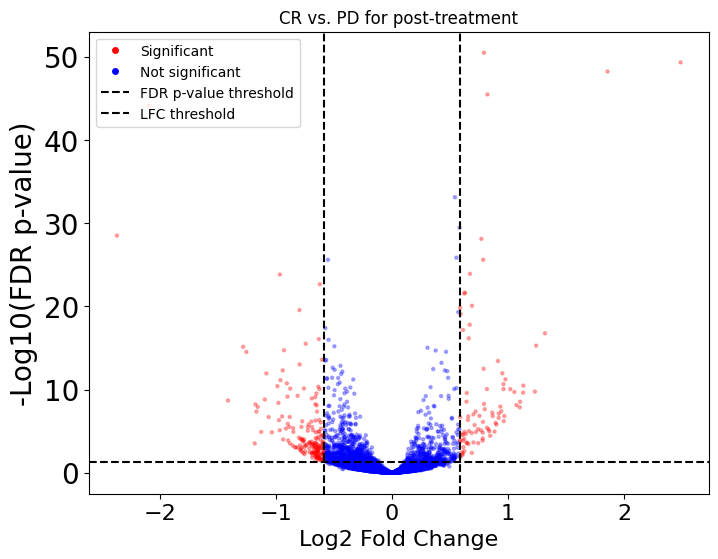

In [478]:
lfc_threshold = math.log2(1.5)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d_CR_PD_TAA_post_treatment['color'] = ['red' if abs(lfc) > lfc_threshold and pval < pval_threshold else 'blue' 
                 for lfc, pval in zip(result_1d_CR_PD_TAA_post_treatment['de_coef'], result_1d_CR_PD_TAA_post_treatment['pval_adj'])]

# Plot volcano plot
plt.figure(figsize=(8, 6))
plt.scatter(result_1d_CR_PD_TAA_post_treatment['de_coef'], -np.log10(result_1d_CR_PD_TAA_post_treatment['pval_adj']), c=result_1d_CR_PD_TAA_post_treatment['color'], alpha=0.3, s=5) # s is the size of the dots

# Highlight significant genes by annotating them
# for i, row in result_1d_CR_PD_TAA_post_treatment.iterrows():
#     if abs(row['de_coef']) > lfc_threshold and row['pval_adj'] < pval_threshold:
#         if row['gene'] in result_1d_CR_PD_TAA_post_treatment[(result_1d_CR_PD_TAA_post_treatment['color'] == "red") & (result_1d_CR_PD_TAA_post_treatment['de_coef'] > 0)].sort_values('pval_adj', ascending=True).head(15)['gene'].values:
#             plt.text(row['de_coef'], -np.log10(row['pval_adj']), row['gene'], fontsize=8, ha='right', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black', label='_nolegend_')

plt.xlabel('Log2 Fold Change', fontsize = 16)
plt.ylabel('-Log10(FDR p-value)', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 20)
plt.title('CR vs. PD for post-treatment')
# plt.legend()
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, loc='upper left')
plt.show()

In [521]:
adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_post

AnnData object with n_obs × n_vars = 2025 × 15827
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'predicted_binding_probability', 'peptide_cat', 'tumor_pred_ref_non_tumor', 'outcome_ref_PD'
    obsm: 'X_umap'
    layers: 'counts'

In [50]:
sc.tl.score_genes(adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_post, cytotoxic_genes, score_name="cytotoxic")
sc.tl.score_genes(adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_post, exhaustion_genes, score_name="exhaustion")
sc.tl.score_genes(adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_post, tumor_reactive, score_name="tumor_reactive")

In [51]:
adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_post.obs['final_cell_type'] = adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_post.obs['cell_type_scvi'].map(cell_map)

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CR vs. PD: t-test independent samples, P_val:2.095e-02 t=2.311e+00


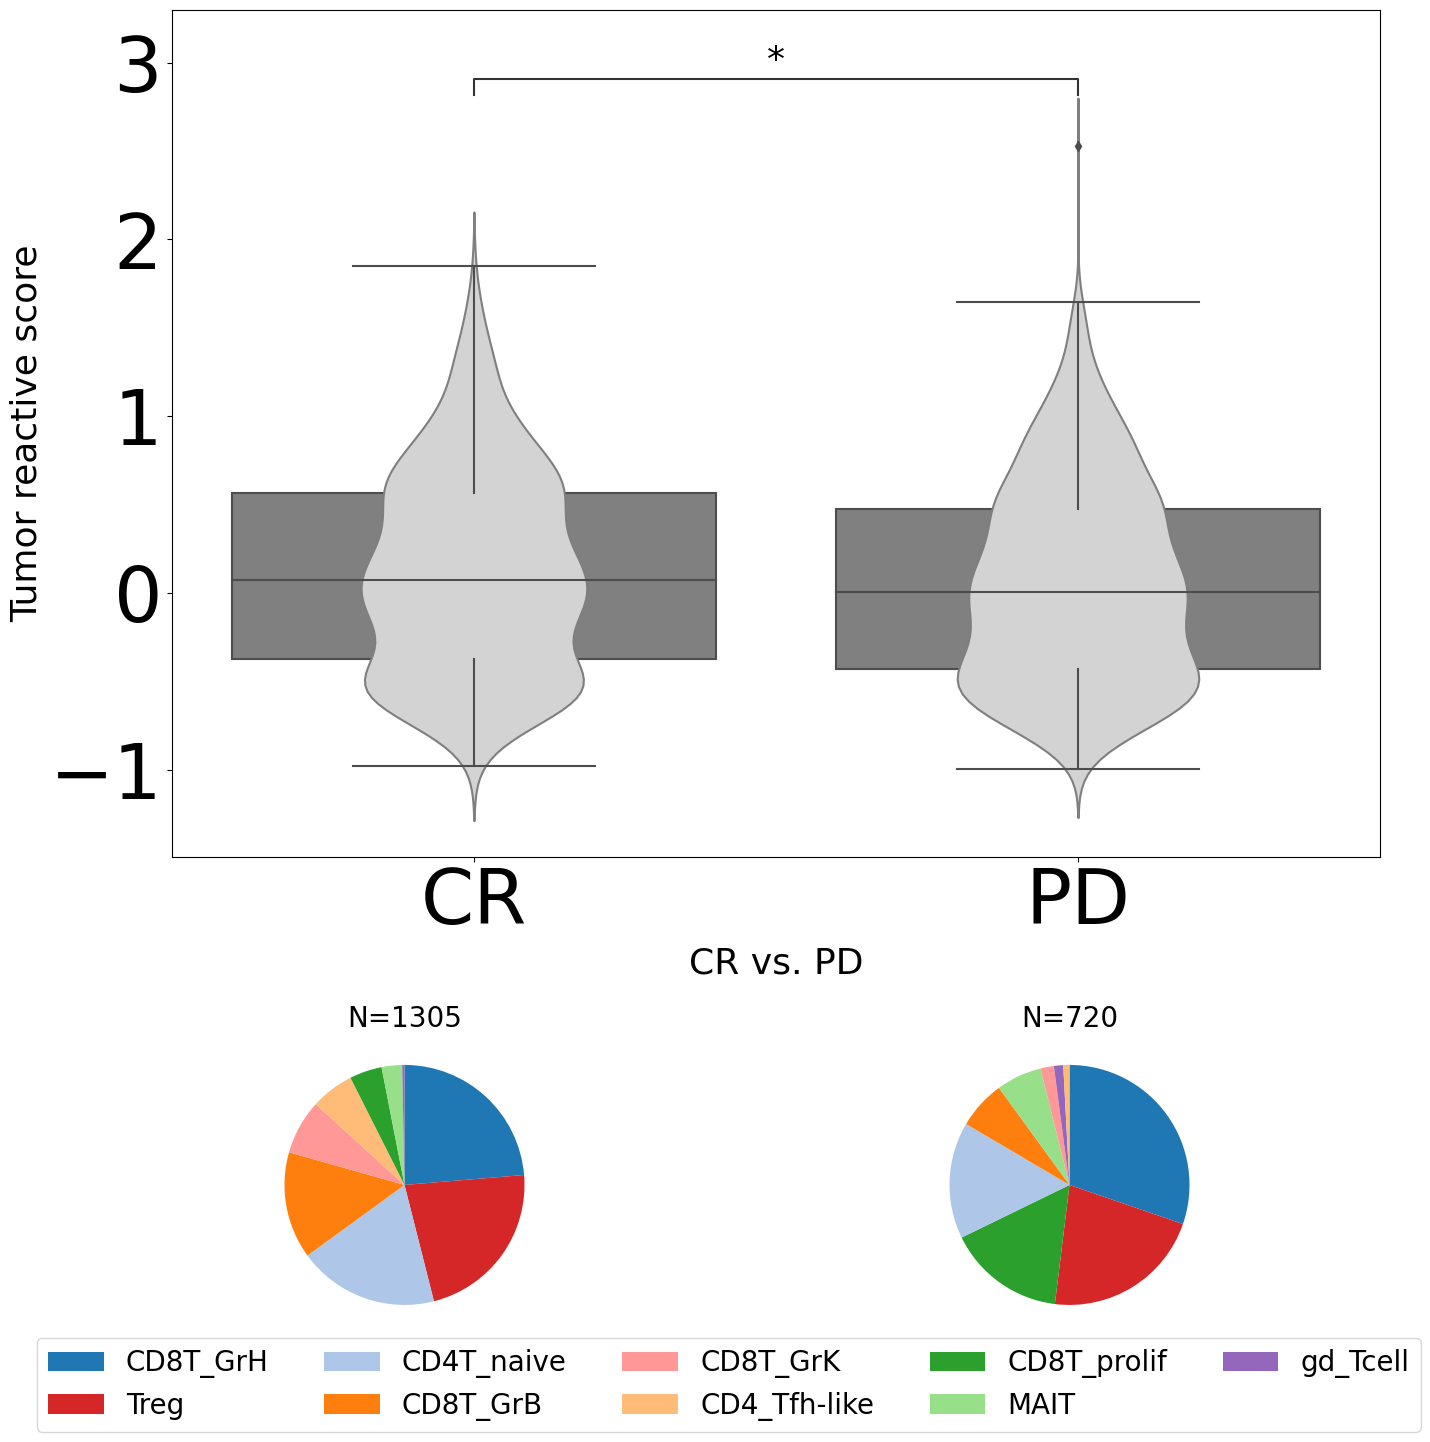

,group1,group2,n1,n2,mean1,mean2,statistic,pvalue,p_adj
0,PD,CR,1830,1957,-0.125071,0.025278,-8.964474,4.797698e-19,4.797698e-19


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

ordered_groups = [ "CR","PD" ]
adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_post = adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_post
dt_TAA_CR_PD_posttreatment = adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_post.obs.copy()

present_groups = [
    g for g in ordered_groups
    if g in dt_TAA_CR_PD_posttreatment["outcome"].unique()
]

# build pairs automatically from the present leiden groups
leiden_groups = sorted(dt_TAA_CR_PD_posttreatment["outcome"].astype(str).unique(), reverse=True)
pair_compaire = [
    ("CR","PD")
]
# pair_compaire = leiden_groups

palette = {g: "red" if "CR" in g else "grey" for g in present_groups}


fig, ax_box = plt.subplots(figsize=(14, 10))

sns.boxplot(
    data=dt_TAA_CR_PD_posttreatment,
    x="outcome",
    y="tumor_reactive",
    order=present_groups,
    # palette=palette,
    color= "grey",
    ax=ax_box
)

sns.violinplot(
    data=dt_TAA_CR_PD_posttreatment,
    x="outcome",
    y="tumor_reactive",
    width=0.4,
    inner=None,
    order=present_groups,
    color="lightgray",
    alpha=0.8,
    ax=ax_box
)

annotator = Annotator(
    ax_box,
    data=dt_TAA_CR_PD_posttreatment,
    x="outcome",
    y="tumor_reactive",
    order=present_groups,
    pairs=pair_compaire
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", fontsize=26, hide_non_significant=True)
annotator.apply_and_annotate()

# ax_box.set_title("Score Comparison CR vs. PD for post-treatment", fontsize=26)
ax_box.tick_params(axis="x",  labelsize=55)
ax_box.tick_params(axis="y",  labelsize=55)
ax_box.set_xlabel("CR vs. PD", fontsize=26)
ax_box.set_ylabel("Tumor reactive score", fontsize=26)

# Get axis position in figure coordinates
ax_pos = ax_box.get_position()

# Get x positions of categories
all_cell_types = dt_TAA_CR_PD_posttreatment["final_cell_type"].unique()
palette = sns.color_palette("tab20", len(all_cell_types))
color_map = dict(zip(all_cell_types, palette))
xticks = ax_box.get_xticks()

all_labels = None
all_handles = None
groups = dt_TAA_CR_PD_posttreatment["outcome"].unique()
for i, (x, grp) in enumerate(zip(xticks, groups)):
    sub = dt_TAA_CR_PD_posttreatment[dt_TAA_CR_PD_posttreatment["outcome"] == grp]
    counts = sub["final_cell_type"].value_counts()
    colors = [color_map[c] for c in counts.index]
    x_fig = ax_pos.x0 -0.22 + (x - ax_box.get_xlim()[0]) / (ax_box.get_xlim()[1] - ax_box.get_xlim()[0]) * 0.95
    y_fig = ax_pos.y0 - 0.45

    ax_pie = fig.add_axes([x_fig, y_fig, 0.3, 0.3])

    wedges, texts= ax_pie.pie(
        counts.values,
        labels=None,          # no labels on the pies
        autopct=None,
        startangle=90,
        colors=colors,
        counterclock=False,
    )

    ax_pie.set_aspect("equal")
    total = counts.sum()
    ax_pie.set_title(f"N={total}", fontsize=20)
    # save legend items only once
    if all_labels is None:
        all_labels = counts.index.tolist()
        all_handles = wedges
fig.legend(
    all_handles,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.02, y_fig - 0.05),
    # title="Cell type",
    fontsize=20,
    ncol=5
)


plt.tight_layout()
plt.show()


df = dt_TAA_CR_PD_pretreatment

groups = df["outcome"].dropna().unique()
pairs = list(itertools.combinations(groups, 2))

results = []

for g1, g2 in pairs:
    x1 = df.loc[df["outcome"] == g1, "tumor_reactive"].dropna()
    x2 = df.loc[df["outcome"] == g2, "tumor_reactive"].dropna()

    stat, pval = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test

    results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x1),
        "n2": len(x2),
        "mean1": x1.mean(),
        "mean2": x2.mean(),
        "statistic": stat,
        "pvalue": pval,
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
results_df["p_adj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

# results_df.to_csv("tumor_reactive CR vs PD post treatment within predicted TAA.csv")
results_df

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CR vs. PD: t-test independent samples, P_val:2.829e-07 t=5.152e+00


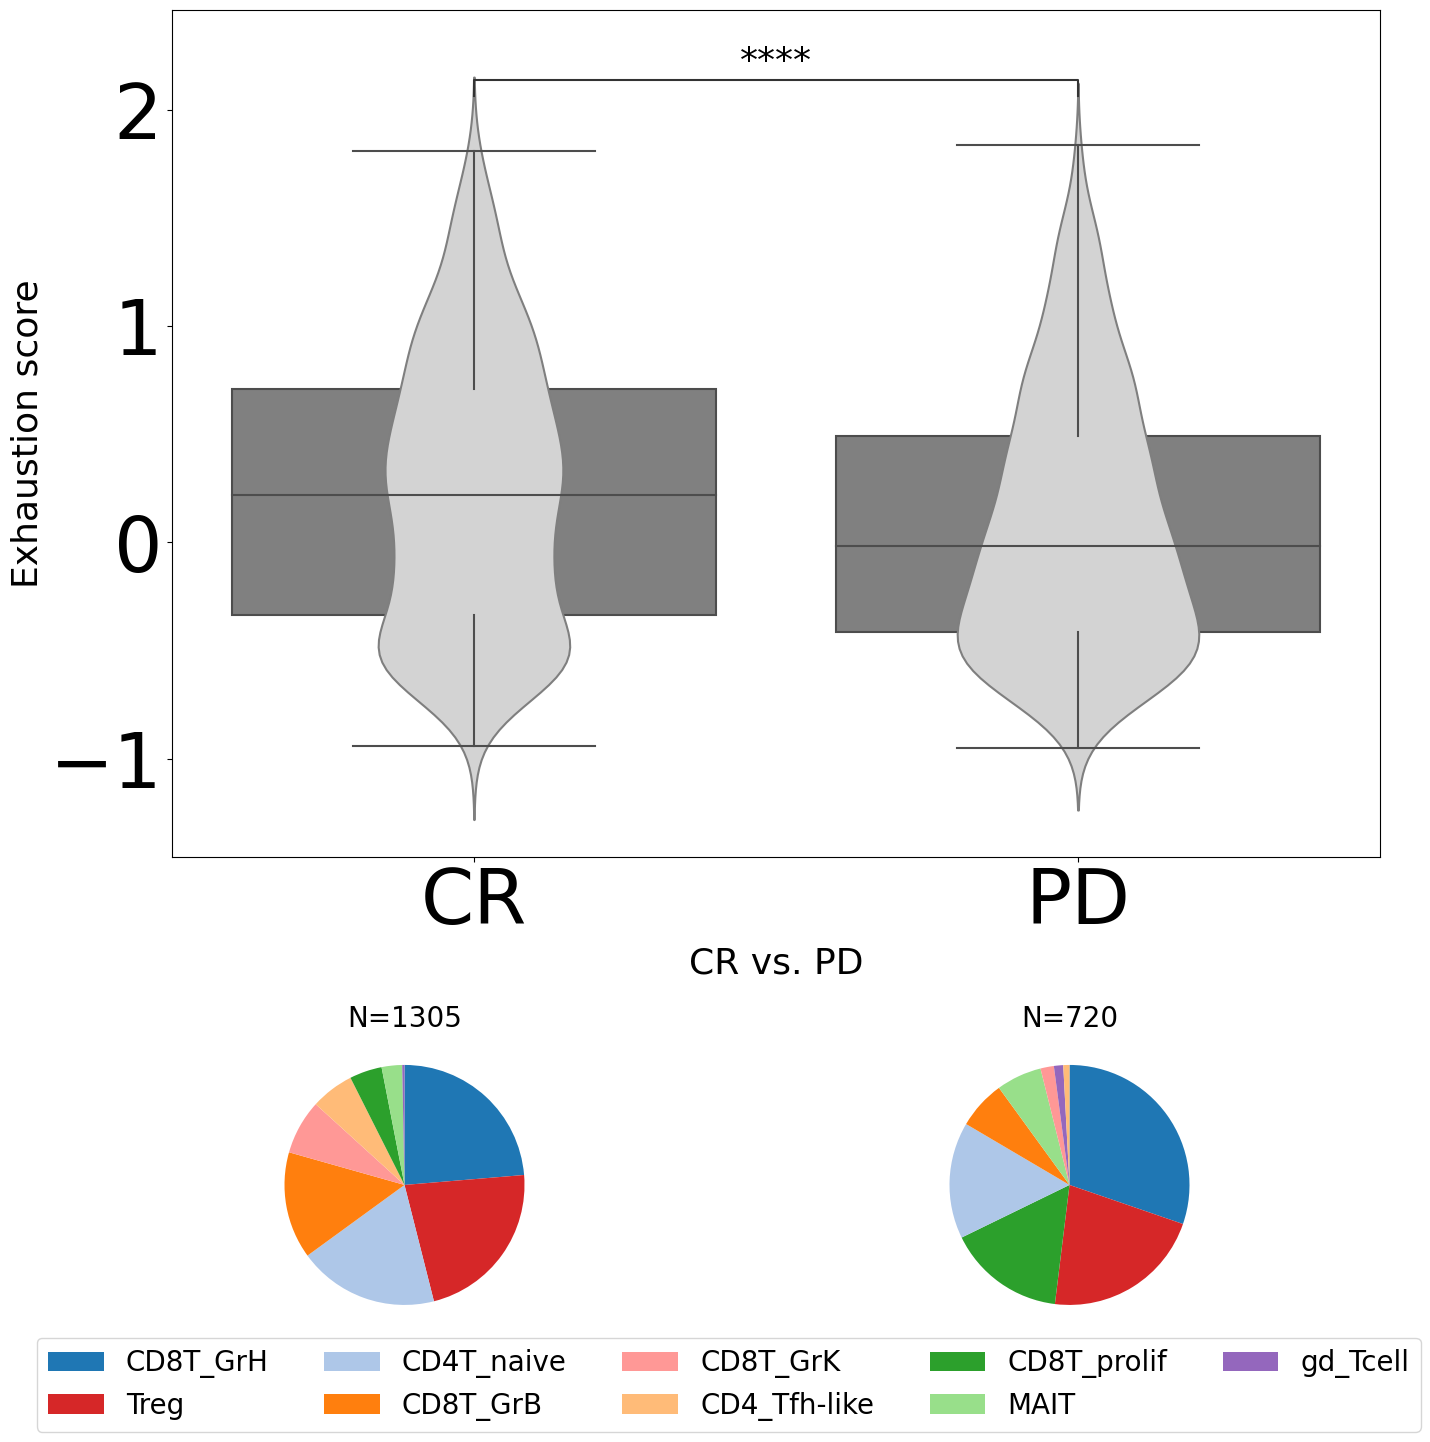

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

ordered_groups = [ "CR","PD" ]
adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_post = adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_post[adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_post.obs['timepoint'].str.contains("post")]
dt_TAA_CR_PD_posttreatment = adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_post.obs.copy()

present_groups = [
    g for g in ordered_groups
    if g in dt_TAA_CR_PD_posttreatment["outcome"].unique()
]

# build pairs automatically from the present leiden groups
leiden_groups = sorted(dt_TAA_CR_PD_posttreatment["outcome"].astype(str).unique(), reverse=True)
pair_compaire = [
    ("CR","PD")
]
# pair_compaire = leiden_groups

palette = {g: "red" if "CR" in g else "grey" for g in present_groups}


fig, ax_box = plt.subplots(figsize=(14, 10))

sns.boxplot(
    data=dt_TAA_CR_PD_posttreatment,
    x="outcome",
    y="exhaustion",
    order=present_groups,
    # palette=palette,
    color="grey",
    ax=ax_box
)

sns.violinplot(
    data=dt_TAA_CR_PD_posttreatment,
    x="outcome",
    y="exhaustion",
    width=0.4,
    inner=None,
    order=present_groups,
    color="lightgray",
    alpha=0.8,
    ax=ax_box
)

annotator = Annotator(
    ax_box,
    data=dt_TAA_CR_PD_posttreatment,
    x="outcome",
    y="exhaustion",
    order=present_groups,
    pairs=pair_compaire
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", fontsize=26, hide_non_significant=True)
annotator.apply_and_annotate()

# ax_box.set_title("Score Comparison CR vs. PD for posttreatment", fontsize=26)
ax_box.tick_params(axis="x",  labelsize=55)
ax_box.tick_params(axis="y",  labelsize=55)
ax_box.set_xlabel("CR vs. PD", fontsize=26)
ax_box.set_ylabel("Exhaustion score", fontsize=26)

# Get axis position in figure coordinates
ax_pos = ax_box.get_position()

# Get x positions of categories
all_cell_types = dt_TAA_CR_PD_posttreatment["final_cell_type"].unique()
palette = sns.color_palette("tab20", len(all_cell_types))
color_map = dict(zip(all_cell_types, palette))
xticks = ax_box.get_xticks()

all_labels = None
all_handles = None
groups = dt_TAA_CR_PD_posttreatment["outcome"].unique()
for i, (x, grp) in enumerate(zip(xticks, groups)):
    sub = dt_TAA_CR_PD_posttreatment[dt_TAA_CR_PD_posttreatment["outcome"] == grp]
    counts = sub["final_cell_type"].value_counts()
    colors = [color_map[c] for c in counts.index]
    x_fig = ax_pos.x0 -0.22 + (x - ax_box.get_xlim()[0]) / (ax_box.get_xlim()[1] - ax_box.get_xlim()[0]) * 0.95
    y_fig = ax_pos.y0 - 0.45

    ax_pie = fig.add_axes([x_fig, y_fig, 0.3, 0.3])

    wedges, texts= ax_pie.pie(
        counts.values,
        labels=None,          # no labels on the pies
        autopct=None,
        startangle=90,
        colors=colors,
        counterclock=False,
    )

    ax_pie.set_aspect("equal")
    total = counts.sum()
    ax_pie.set_title(f"N={total}", fontsize=20)
    # save legend items only once
    if all_labels is None:
        all_labels = counts.index.tolist()
        all_handles = wedges
fig.legend(
    all_handles,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.02, y_fig - 0.05),
    # title="Cell type",
    fontsize=20,
    ncol=5
)


plt.tight_layout()
plt.show()


df = dt_TAA_CR_PD_pretreatment

groups = df["outcome"].dropna().unique()
pairs = list(itertools.combinations(groups, 2))

results = []

for g1, g2 in pairs:
    x1 = df.loc[df["outcome"] == g1, "exhaustion"].dropna()
    x2 = df.loc[df["outcome"] == g2, "exhaustion"].dropna()

    stat, pval = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test

    results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x1),
        "n2": len(x2),
        "mean1": x1.mean(),
        "mean2": x2.mean(),
        "statistic": stat,
        "pvalue": pval,
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
results_df["p_adj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

# results_df.to_csv("exhaustion CR vs PD post treatment wihin predicted TAA.csv")

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CR vs. PD: t-test independent samples, P_val:1.665e-31 t=1.188e+01


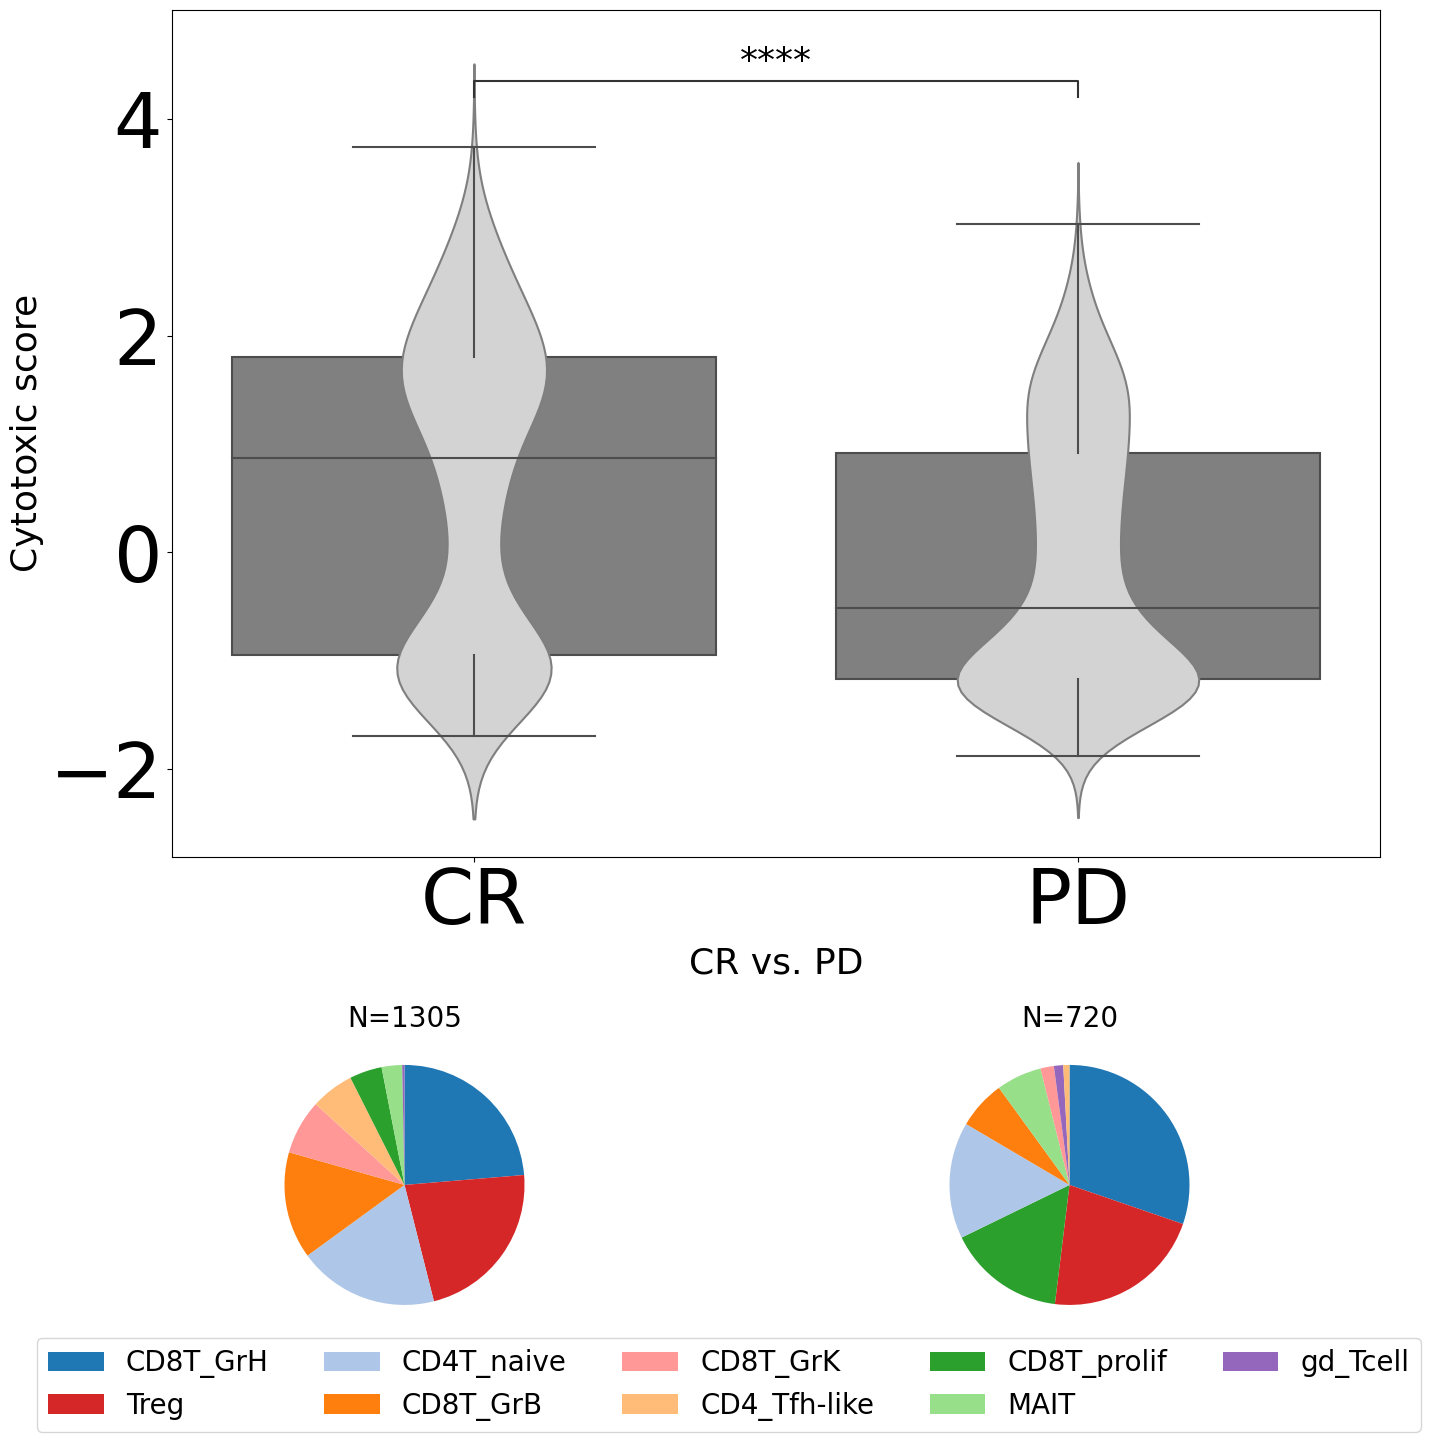

,group1,group2,n1,n2,mean1,mean2,statistic,pvalue,p_adj
0,PD,CR,1830,1957,-0.19874,0.572066,-20.628685,1.708167e-89,1.708167e-89


In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

ordered_groups = [ "CR","PD" ]
adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_post = adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_post[adata_raw_noHC_no_NA_outcome_high_conf_CR_PD_post.obs['timepoint'].str.contains("post")]
dt_TAA_CR_PD_posttreatment = adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_post.obs.copy()

present_groups = [
    g for g in ordered_groups
    if g in dt_TAA_CR_PD_posttreatment["outcome"].unique()
]

# build pairs automatically from the present leiden groups
leiden_groups = sorted(dt_TAA_CR_PD_posttreatment["outcome"].astype(str).unique(), reverse=True)
pair_compaire = [
    ("CR","PD")
]
# pair_compaire = leiden_groups

palette = {g: "red" if "CR" in g else "grey" for g in present_groups}


fig, ax_box = plt.subplots(figsize=(14, 10))

sns.boxplot(
    data=dt_TAA_CR_PD_posttreatment,
    x="outcome",
    y="cytotoxic",
    order=present_groups,
    # palette=palette,
    color="grey",
    ax=ax_box
)

sns.violinplot(
    data=dt_TAA_CR_PD_posttreatment,
    x="outcome",
    y="cytotoxic",
    width=0.4,
    inner=None,
    order=present_groups,
    color="lightgray",
    alpha=0.8,
    ax=ax_box
)

annotator = Annotator(
    ax_box,
    data=dt_TAA_CR_PD_posttreatment,
    x="outcome",
    y="cytotoxic",
    order=present_groups,
    pairs=pair_compaire
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", fontsize=26, hide_non_significant=True)
annotator.apply_and_annotate()

# ax_box.set_title("Score Comparison CR vs. PD for posttreatment", fontsize=26)
ax_box.tick_params(axis="x",  labelsize=55)
ax_box.tick_params(axis="y",  labelsize=55)
ax_box.set_xlabel("CR vs. PD", fontsize=26)
ax_box.set_ylabel("Cytotoxic score", fontsize=26)

# Get axis position in figure coordinates
ax_pos = ax_box.get_position()

# Get x positions of categories
all_cell_types = dt_TAA_CR_PD_posttreatment["final_cell_type"].unique()
palette = sns.color_palette("tab20", len(all_cell_types))
color_map = dict(zip(all_cell_types, palette))
xticks = ax_box.get_xticks()

all_labels = None
all_handles = None
groups = dt_TAA_CR_PD_posttreatment["outcome"].unique()
for i, (x, grp) in enumerate(zip(xticks, groups)):
    sub = dt_TAA_CR_PD_posttreatment[dt_TAA_CR_PD_posttreatment["outcome"] == grp]
    counts = sub["final_cell_type"].value_counts()
    colors = [color_map[c] for c in counts.index]
    x_fig = ax_pos.x0 -0.22 + (x - ax_box.get_xlim()[0]) / (ax_box.get_xlim()[1] - ax_box.get_xlim()[0]) * 0.95
    y_fig = ax_pos.y0 - 0.45

    ax_pie = fig.add_axes([x_fig, y_fig, 0.3, 0.3])

    wedges, texts= ax_pie.pie(
        counts.values,
        labels=None,          # no labels on the pies
        autopct=None,
        startangle=90,
        colors=colors,
        counterclock=False,
    )

    ax_pie.set_aspect("equal")
    total = counts.sum()
    ax_pie.set_title(f"N={total}", fontsize=20)
    # save legend items only once
    if all_labels is None:
        all_labels = counts.index.tolist()
        all_handles = wedges
fig.legend(
    all_handles,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.02, y_fig - 0.05),
    # title="Cell type",
    fontsize=20,
    ncol=5
)


plt.tight_layout()
plt.show()


df = dt_TAA_CR_PD_pretreatment

groups = df["outcome"].dropna().unique()
pairs = list(itertools.combinations(groups, 2))

results = []

for g1, g2 in pairs:
    x1 = df.loc[df["outcome"] == g1, "cytotoxic"].dropna()
    x2 = df.loc[df["outcome"] == g2, "cytotoxic"].dropna()

    stat, pval = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test

    results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x1),
        "n2": len(x2),
        "mean1": x1.mean(),
        "mean2": x2.mean(),
        "statistic": stat,
        "pvalue": pval,
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
results_df["p_adj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

# results_df.to_csv("cytotoxic CR vs PD post treatment wihin predicted TAA.csv")
results_df

In [613]:
adata_HVG_no_HC_CR_PD = sc.read_h5ad("adata_HVG_no_HC_CR_PD.h5ad")

In [ ]:
adata_HVG_no_HC_CR_PD.obs['leiden'].value_counts()